In [ ]:
"""
created by Alessandro Ianiro 01.09.2022
modified by Aleksander A. Rebane 12.05.2026
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import root, brentq
# from sympy import *   

# import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

from datetime import datetime
from tqdm import tqdm
# from Bio import Entrez, SeqIO
import pickle

from gfvt import PD
# import csv

# Get the current date
today = datetime.now()

# Format the date as "YYMMDD"
date_string = today.strftime("%y%m%d")

%matplotlib inline

mbsa = 66.4
mpeg100 = 100
mpeg20 = 20
mpeg35 = 35
mpeg8 = 8
mpeg6 = 6
mpeg4 = 4
mpeg48_wt = 5.3

mpegQ8 = (8/(14.8/3))**(1/0.6379)*mpeg100
mpegQ10 = (10/(14.8/3))**(1/0.6379)*mpeg100
mpegQ16 = (16/(14.8/3))**(1/0.6379)*mpeg100

rbsa = 3.0e-9

rpeg4K = 1.9e-9
rpeg6K = 2.45e-9
rpeg8K = 3.1e-9
rpeg20K = 5.4e-9
rpeg35K = 7.8e-9
rpeg100K = 14.8e-9
rpegQ8 = 24e-9
rpegQ10 = 32e-9
rpegQ16 = 48e-9

Nav = 6.022e23 # avogadro

# Load data

In [3]:
data_4K_pH7_200mM_MA3 = np.loadtxt('../data/PEG_4K_BSA_Data.csv', delimiter=',')
data_6K_pH7_200mM_SD = np.loadtxt('../data/PEG_6K_BSA_Data.csv', delimiter=',')
data_8K_pH7_200mM_SD = np.loadtxt('../data/PEG_8K_BSA_Data.csv', delimiter=',')
data_20K_pH7_200mM = np.loadtxt('../data/PEG_20K_BSA_Data.csv', delimiter=',')
data_35K_pH7_200mM = np.loadtxt('../data/PEG_35K_BSA_Data.csv', delimiter=',')
data_100K_pH7_200mM = np.loadtxt('../data/PEG_100K_BSA_Data.csv', delimiter=',')

data_2K8K_pH7_200mM_n_MW = np.loadtxt('../data/PEG_8K_2K_Mn6K_BSA_Data.csv', delimiter=',')
data_2K8K_pH7_200mM_n_MW8K = np.loadtxt('../data/PEG_8K_2K_8Konly_BSA_Data.csv', delimiter=',')
data_2K35K_pH7_200mM_n = np.loadtxt('../data/PEG_35K_2K_Mn6K_BSA_Data.csv', delimiter=',')
data_2K35K_pH7_200mM_35only = np.loadtxt('../data/PEG_35K_2K_35Konly_BSA_Data.csv', delimiter=',')

data_35K_GFP = np.loadtxt('../data/PEG_35K_GFP_Data.csv', delimiter=',')
data_20K_GFP = np.loadtxt('../data/PEG_20K_GFP_Data.csv', delimiter=',')


# Pickle

## Load pickled variables

In [ ]:
# Load the saved variables

with open('../pickles/260424_output.pkl', 'rb') as f:
    loaded_variables = pickle.load(f)

# Access variables
gfvt4K_200mM_Z0 = loaded_variables['gfvt4K_200mM_Z0']
gfvt6K_200mM_Z0 = loaded_variables['gfvt6K_200mM_Z0']
gfvt8K_200mM_Z0 = loaded_variables['gfvt8K_200mM_Z0']
gfvt20K_200mM_Z0 = loaded_variables['gfvt20K_200mM_Z0']
gfvt35K_200mM_Z0 = loaded_variables['gfvt35K_200mM_Z0']
gfvt100K_200mM_Z0 = loaded_variables['gfvt100K_200mM_Z0']

gfvt4K_200mM_Z0_FVT = loaded_variables['gfvt4K_200mM_Z0_FVT']
gfvt6K_200mM_Z0_FVT = loaded_variables['gfvt6K_200mM_Z0_FVT']
gfvt8K_200mM_Z0_FVT = loaded_variables['gfvt8K_200mM_Z0_FVT']
gfvt20K_200mM_Z0_FVT = loaded_variables['gfvt20K_200mM_Z0_FVT']
gfvt35K_200mM_Z0_FVT = loaded_variables['gfvt35K_200mM_Z0_FVT']
gfvt100K_200mM_Z0_FVT = loaded_variables['gfvt100K_200mM_Z0_FVT']
gfvt100K_200mM_Z0_FVT_ex = loaded_variables['gfvt100K_200mM_Z0_FVT_ex']

gfvt4K_200mM_Z0_theta = loaded_variables['gfvt4K_200mM_Z0_theta']
gfvt6K_200mM_Z0_theta = loaded_variables['gfvt6K_200mM_Z0_theta']
gfvt8K_200mM_Z0_theta = loaded_variables['gfvt8K_200mM_Z0_theta']
gfvt20K_200mM_Z0_theta = loaded_variables['gfvt20K_200mM_Z0_theta']
gfvt35K_200mM_Z0_theta = loaded_variables['gfvt35K_200mM_Z0_theta']
gfvt100K_200mM_Z0_theta = loaded_variables['gfvt100K_200mM_Z0_theta']

gfvt6p7K_200mM_Z0 = loaded_variables['gfvt6p7K_200mM_Z0']
gfvt7p3K_200mM_Z0 = loaded_variables['gfvt7p3K_200mM_Z0']
gfvt25K_200mM_Z0 = loaded_variables['gfvt25K_200mM_Z0']

gfvtQ8_200mM_Z0 = loaded_variables['gfvtQ8_200mM_Z0']
gfvtQ10_200mM_Z0 = loaded_variables['gfvtQ10_200mM_Z0']
gfvtQ16_200mM_Z0 = loaded_variables['gfvtQ16_200mM_Z0']

gfvt4K_200mM_Z0_full = loaded_variables['gfvt4K_200mM_Z0_full']
gfvt6K_200mM_Z0_full = loaded_variables['gfvt6K_200mM_Z0_full']
gfvt8K_200mM_Z0_full = loaded_variables['gfvt8K_200mM_Z0_full']
gfvt20K_200mM_Z0_full = loaded_variables['gfvt20K_200mM_Z0_full']
gfvt35K_200mM_Z0_full = loaded_variables['gfvt35K_200mM_Z0_full']
gfvt100K_200mM_Z0_full = loaded_variables['gfvt100K_200mM_Z0_full']
gfvtQ8_200mM_Z0_full = loaded_variables['gfvtQ8_200mM_Z0_full']
gfvtQ10_200mM_Z0_full = loaded_variables['gfvtQ10_200mM_Z0_full']
gfvtQ16_200mM_Z0_full = loaded_variables['gfvtQ16_200mM_Z0_full']

gfvt4K_GFP_real = loaded_variables['gfvt4K_GFP_real']
gfvt6K_GFP_real = loaded_variables['gfvt6K_GFP_real']
gfvt8K_GFP_real = loaded_variables['gfvt8K_GFP_real']
gfvt20K_GFP_real = loaded_variables['gfvt20K_GFP_real']
gfvt35K_GFP_real = loaded_variables['gfvt35K_GFP_real']
gfvt100K_GFP_real = loaded_variables['gfvt100K_GFP_real']

gfvt4K_GFP = loaded_variables['gfvt4K_GFP'] 
gfvt6K_GFP = loaded_variables['gfvt6K_GFP']
gfvt8K_GFP = loaded_variables['gfvt8K_GFP']
gfvt20K_GFP = loaded_variables['gfvt20K_GFP']
gfvt35K_GFP = loaded_variables['gfvt35K_GFP']
gfvt100K_GFP = loaded_variables['gfvt100K_GFP']
gfvtQ8_GFP = loaded_variables['gfvtQ8_GFP']
gfvtQ10_GFP = loaded_variables['gfvtQ10_GFP']
gfvtQ16_GFP = loaded_variables['gfvtQ16_GFP']

gfvt4K_GFP1p8 = loaded_variables['gfvt4K_GFP1p8']
gfvt4K_GFP1p8_real = loaded_variables['gfvt4K_GFP1p8_real']
gfvt6K_GFP1p8 = loaded_variables['gfvt6K_GFP1p8']
gfvt6K_GFP1p8_real = loaded_variables['gfvt6K_GFP1p8_real']
gfvt8K_GFP1p8 = loaded_variables['gfvt8K_GFP1p8']
gfvt8K_GFP1p8_real = loaded_variables['gfvt8K_GFP1p8_real']
gfvt20K_GFP1p8 = loaded_variables['gfvt20K_GFP1p8']
gfvt20K_GFP1p8_real = loaded_variables['gfvt20K_GFP1p8_real']
gfvt35K_GFP1p8 = loaded_variables['gfvt35K_GFP1p8']
gfvt35K_GFP1p8_real = loaded_variables['gfvt35K_GFP1p8_real']
gfvt100K_GFP1p8 = loaded_variables['gfvt100K_GFP1p8']
gfvt100K_GFP1p8_real = loaded_variables['gfvt100K_GFP1p8_real']
gfvtQ8_GFP1p8 = loaded_variables['gfvtQ8_GFP1p8']
gfvtQ10_GFP1p8 = loaded_variables['gfvtQ10_GFP1p8']
gfvtQ16_GFP1p8 = loaded_variables['gfvtQ16_GFP1p8']
gfvt7p3K_200mM_Z0_full = loaded_variables['gfvt7p3K_200mM_Z0_full']
gfvt25K_200mM_Z0_full = loaded_variables['gfvt25K_200mM_Z0_full']
# Convert legacy GFVT lists from older pickles into PD objects for plotting.
BSA_PEG_4K = PD.from_legacy_list(gfvt4K_200mM_Z0)
BSA_PEG_6K = PD.from_legacy_list(gfvt6K_200mM_Z0)
BSA_PEG_8K = PD.from_legacy_list(gfvt8K_200mM_Z0)
BSA_PEG_20K = PD.from_legacy_list(gfvt20K_200mM_Z0)
BSA_PEG_35K = PD.from_legacy_list(gfvt35K_200mM_Z0)
BSA_PEG_100K = PD.from_legacy_list(gfvt100K_200mM_Z0)
BSA_PEG_6p7K = PD.from_legacy_list(gfvt6p7K_200mM_Z0)
BSA_PEG_7p3K = PD.from_legacy_list(gfvt7p3K_200mM_Z0)
BSA_PEG_25K = PD.from_legacy_list(gfvt25K_200mM_Z0)
BSA_PEG_Q8 = PD.from_legacy_list(gfvtQ8_200mM_Z0)
BSA_PEG_Q10 = PD.from_legacy_list(gfvtQ10_200mM_Z0)
BSA_PEG_Q16 = PD.from_legacy_list(gfvtQ16_200mM_Z0)
BSA_PEG_4K_full = PD.from_legacy_list(gfvt4K_200mM_Z0_full)
BSA_PEG_6K_full = PD.from_legacy_list(gfvt6K_200mM_Z0_full)
BSA_PEG_8K_full = PD.from_legacy_list(gfvt8K_200mM_Z0_full)
BSA_PEG_20K_full = PD.from_legacy_list(gfvt20K_200mM_Z0_full)
BSA_PEG_35K_full = PD.from_legacy_list(gfvt35K_200mM_Z0_full)
BSA_PEG_100K_full = PD.from_legacy_list(gfvt100K_200mM_Z0_full)
BSA_PEG_7p3K_full = PD.from_legacy_list(gfvt7p3K_200mM_Z0_full)
BSA_PEG_25K_full = PD.from_legacy_list(gfvt25K_200mM_Z0_full)
BSA_PEG_Q8_full = PD.from_legacy_list(gfvtQ8_200mM_Z0_full)
BSA_PEG_Q10_full = PD.from_legacy_list(gfvtQ10_200mM_Z0_full)
BSA_PEG_Q16_full = PD.from_legacy_list(gfvtQ16_200mM_Z0_full)


## Save variable into pickle

In [ ]:
# Create a dictionary with the variables you want to save
variables_to_save = {
    'BSA_PEG_4K': BSA_PEG_4K,
    'BSA_PEG_6K': BSA_PEG_6K,
    'BSA_PEG_8K': BSA_PEG_8K,
    'BSA_PEG_20K': BSA_PEG_20K,
    'BSA_PEG_35K': BSA_PEG_35K,
    'BSA_PEG_100K': BSA_PEG_100K,
    'BSA_PEG_6p7K' : BSA_PEG_6p7K,
    'BSA_PEG_7p3K' : BSA_PEG_7p3K,
    'BSA_PEG_25K' : BSA_PEG_25K,
    'BSA_PEG_Q8' : BSA_PEG_Q8,
    'BSA_PEG_Q10' : BSA_PEG_Q10,
    'BSA_PEG_Q16' : BSA_PEG_Q16,
    'BSA_PEG_4K_full': BSA_PEG_4K_full,
    'BSA_PEG_6K_full': BSA_PEG_6K_full,
    'BSA_PEG_8K_full': BSA_PEG_8K_full,
    'BSA_PEG_20K_full': BSA_PEG_20K_full,
    'BSA_PEG_35K_full': BSA_PEG_35K_full,
    'BSA_PEG_100K_full': BSA_PEG_100K_full,
    'BSA_PEG_6p7K_full' : BSA_PEG_6p7K_full,
    'BSA_PEG_7p3K_full' : BSA_PEG_7p3K_full,
    'BSA_PEG_25K_full' : BSA_PEG_25K_full,
    'BSA_PEG_Q8_full' : BSA_PEG_Q8_full,
    'BSA_PEG_Q10_full' : BSA_PEG_Q10_full,
    'BSA_PEG_Q16_full' : BSA_PEG_Q16_full,
    
    'gfvt4K_GFP_real' : gfvt4K_GFP_real,
    'gfvt6K_GFP_real' : gfvt6K_GFP_real,
    'gfvt8K_GFP_real' : gfvt8K_GFP_real,
    'gfvt20K_GFP_real' : gfvt20K_GFP_real,
    'gfvt35K_GFP_real' : gfvt35K_GFP_real,
    'gfvt100K_GFP_real' : gfvt100K_GFP_real,
    'gfvtQ16_GFP' : gfvtQ16_GFP,
    'gfvt4K_GFP' : gfvt4K_GFP,
    'gfvt6K_GFP' : gfvt6K_GFP,
    'gfvt8K_GFP' : gfvt8K_GFP,
    'gfvt20K_GFP' : gfvt20K_GFP,
    'gfvt35K_GFP' : gfvt35K_GFP,
    'gfvt100K_GFP' : gfvt100K_GFP,
    'gfvtQ8_GFP' : gfvtQ8_GFP,
    'gfvtQ10_GFP' : gfvtQ10_GFP,
    'gfvtQ16_GFP' : gfvtQ16_GFP,
    'gfvt4K_GFP1p8' : gfvt4K_GFP1p8,
    'gfvt4K_GFP1p8_real' : gfvt4K_GFP1p8_real,
    'gfvt6K_GFP1p8' : gfvt6K_GFP1p8,
    'gfvt6K_GFP1p8_real' : gfvt6K_GFP1p8_real,
    'gfvt8K_GFP1p8' : gfvt8K_GFP1p8,
    'gfvt8K_GFP1p8_real' : gfvt8K_GFP1p8_real,
    'gfvt20K_GFP1p8' : gfvt20K_GFP1p8,
    'gfvt20K_GFP1p8_real' : gfvt20K_GFP1p8_real,
    'gfvt35K_GFP1p8' : gfvt35K_GFP1p8,
    'gfvt35K_GFP1p8_real' : gfvt35K_GFP1p8_real,
    'gfvt100K_GFP1p8' : gfvt100K_GFP1p8,
    'gfvt100K_GFP1p8_real' : gfvt100K_GFP1p8_real,
    'gfvtQ8_GFP1p8' : gfvtQ8_GFP1p8,
    'gfvtQ10_GFP1p8' : gfvtQ10_GFP1p8,
    'gfvtQ16_GFP1p8' : gfvtQ16_GFP1p8,
    'gfvt7p3K_200mM_Z0_full' : gfvt7p3K_200mM_Z0_full,
    'gfvt25K_200mM_Z0_full' : gfvt25K_200mM_Z0_full
}

# Save to a file
with open('../pickles/' + date_string + '_output.pkl', 'wb') as f:
    pickle.dump(variables_to_save, f)

print(f'Variables saved to ../pickles/{date_string}_output.pkl')

# PD class plotting methods

## molplot_FVT()

In [ ]:
def molplot_FVT(fvt_out, plabel, pcolor, mbsa=0, mpeg=0):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params = fvt_out
    Rpr_in, Rpol_in, mbsa_, mpeg_, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg = params

    q = Rpol_in/Rpr_in;
    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm, q = {q:.2f}'
    
    if mbsa == 0 or mpeg == 0:
    
        b_bsa_A = BSA_Drop
        b_bsa_B = BSA_Sup
        b_PEG_A = PEG_Drop
        b_PEG_B = PEG_Sup
        
    else:
    
        b_bsa_A = BSA_Drop*mbsa
        b_bsa_B = BSA_Sup*mbsa
        b_PEG_A = PEG_Drop*mpeg
        b_PEG_B = PEG_Sup*mpeg
        
    plt.plot(b_bsa_A,b_PEG_A, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(b_bsa_B,b_PEG_B, '-', color = pcolor, ms = 2)
    plt.legend(loc=(1.1,0),fontsize='x-large')
    
    return

## molplot_FVT_phi()

In [ ]:
def molplot_FVT_phi(fvt_out, plabel, pcolor, mbsa=0, mpeg=0):

    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params = fvt_out
    Rpr_in, Rpol_in, mbsa_, mpeg_, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg = params
    q = Rpol_in/Rpr_in;
    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm, q = {q:.2f}'

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    a_fix, b_fix, c_fix =  abc(q)
    
    b_bsa_A = BSA_Drop/phix_bsa
    b_bsa_B = BSA_Sup/phix_bsa
    b_PEG_A = PEG_Drop/phix_peg
    b_PEG_B = PEG_Sup/phix_peg

    Q_BSA_A1 = [1/a for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    Q_BSA_B1 = [1/a for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]

    # Q_BSA_A = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    # Q_BSA_B = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]
    

    # c_BSA_A = [fBSA*((Rpol_in+Rpr_in))**3 for fPEG, fBSA, a in zip(PEG_Drop, BSA_Drop, a_Drop)]
    # c_BSA_B = [fBSA*((Rpol_in+Rpr_in))**3 for fPEG, fBSA, a in zip(PEG_Sup, BSA_Sup, a_Sup)]
    
    # c_PEG_A1 = [fPEG*Rpol_in**-3*(Rpol_in/Rpr_in)**2.41 for fPEG, fBSA, a, Q in zip(b_PEG_A, b_bsa_A, a_Drop,Q_BSA_A)]
    # c_PEG_B1 = [fPEG*Rpol_in**-3*(Rpol_in/Rpr_in)**2.41 for fPEG, fBSA, a, Q in zip(b_PEG_B, b_bsa_B, a_Sup,Q_BSA_B)]

    c_PEG_A1 = [fPEG*(Rpol_in/Rpr_in)**-0.57 for fPEG, fBSA, a in zip(b_PEG_A, b_bsa_A, a_Drop)]
    c_PEG_B1 = [fPEG*(Rpol_in/Rpr_in)**-0.57 for fPEG, fBSA, a in zip(b_PEG_B, b_bsa_B, a_Sup)]
    
    # c_PEG_A = [fPEG*(Rpol_in/Rpr_in)**2.28 for fPEG, fBSA, a, Q in zip(PEG_Drop, b_bsa_A, a_Drop,Q_BSA_A)]
    # c_PEG_B = [fPEG*(Rpol_in/Rpr_in)**2.28 for fPEG, fBSA, a, Q in zip(PEG_Sup, b_bsa_B, a_Sup,Q_BSA_B)]

    # a_BSA_A = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    # a_BSA_B = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Sup, b_bsa_B, a_Sup)]

    # plt.plot(BSA_Drop, phi_R*q**-0.33, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(BSA_Sup, phi_R*q**-0.33, '-', color = pcolor, ms = 2)

    # plt.plot(b_bsa_A*((Rpol_in+Rpr_in)/Rpr_in)**3, c_PEG_A, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B*((Rpol_in+Rpr_in)/Rpr_in)**3, c_PEG_B, '-', color = pcolor, ms = 2)

    plt.plot(Q_BSA_A1, c_PEG_A1, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(Q_BSA_B1, c_PEG_B1, '-', color = pcolor, ms = 2)

    # plt.plot(Q_BSA_A, c_PEG_A, '--', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(Q_BSA_B, c_PEG_B, '--', color = pcolor, ms = 2)


    # plt.plot(b_bsa_A, q**-0.33*phi_R, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B, q**-0.33*phi_R, '-', color = pcolor, ms = 2)

    plt.legend(loc=(1.1,0),fontsize='x-large')
    
    return

## aplot_FVT()

In [ ]:
def aplot_FVT(fvt_out, plabel, pcolor, mbsa=0, mpeg=0):

    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params = fvt_out
    Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg = params
    q = Rpol_in/Rpr_in;
    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm, q = {q:.2f}'

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    a_fix, b_fix, c_fix =  abc(q)
    
    b_bsa_A = BSA_Drop/phix_bsa
    b_bsa_B = BSA_Sup/phix_bsa
    b_PEG_A = PEG_Drop/phix_peg
    b_PEG_B = PEG_Sup/phix_peg

    a_BSA_A = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    a_BSA_B = [(1-a)*Rpr_in**3 for fPEG, fBSA, a in zip(PEG_Sup, b_bsa_B, a_Sup)]

    Q_BSA_A = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    Q_BSA_B = [a_fix*(Phi/(1 - Phi))+b_fix*(Phi/(1 - Phi))**2+c_fix*(Phi/(1 - Phi))**3 for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]
    
    c_BSA_A = [Phi*((Rpol_in+Rpr_in)/Rpr_in)**3 for fPEG, Phi, a in zip(PEG_Drop, b_bsa_A, a_Drop)]
    c_BSA_B = [Phi*((Rpol_in+Rpr_in)/Rpr_in)**3 for fPEG, Phi, a in zip(PEG_Sup, b_bsa_B, a_Sup)]
    
    c_PEG_A = [fPEG*((Rpol_in+Rpr_in))**6 for fPEG, fBSA, a, Q in zip(PEG_Drop, b_bsa_A, a_Drop,Q_BSA_A)]
    c_PEG_B = [fPEG*((Rpol_in+Rpr_in))**6 for fPEG, fBSA, a, Q in zip(PEG_Sup, b_bsa_B, a_Sup,Q_BSA_B)]
    
        
    # plt.plot(BSA_Drop, phi_R*q**-0.33, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(BSA_Sup, phi_R*q**-0.33, '-', color = pcolor, ms = 2)

    # plt.plot(b_bsa_A*((Rpol_in+Rpr_in))**3, c_PEG_A, '--', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B*((Rpol_in+Rpr_in))**3, c_PEG_B, '--', color = pcolor, ms = 2)

    plt.plot(BSA_Drop, Q_BSA_A, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(BSA_Sup, Q_BSA_B, '-', color = pcolor, ms = 2)

    plt.plot(BSA_Drop, c_BSA_A, '--', color = pcolor, ms = 2, label=full_label + ' binodal')
    plt.plot(BSA_Sup, c_BSA_B, '--', color = pcolor, ms = 2)

    # plt.plot(b_bsa_A, q**-0.33*phi_R, '-', color = pcolor, ms = 2, label=full_label + ' binodal')
    # plt.plot(b_bsa_B, q**-0.33*phi_R, '-', color = pcolor, ms = 2)

    plt.legend(loc=(1.1,0),fontsize='x-large')
    
    return

figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.xlim(0,0.5)
# plt.ylim(0,1.6)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

aplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
aplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
aplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
aplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
aplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
aplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')

# EV_plot()

In [ ]:
#%%  IMPORT DATA
#concentrations are in mM = mol/m^3

#%%   GENERALIZED FREE VOLUME THEORY (grand canonical approach) 
# note that Phi pol is the polymer volume fraction in the reservoir divided by the polymer overlapping concentration 
# GFVT_es(3.0e-9, 1.85e-9, mbsa, mpeg48_wt, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, False, 0, mcp_calc, mcs_calc)
# GFVT_es(Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, critical, Za_in, mcp_in, mcs_in)
def EV_plot(Rpr_in, Rpol_in, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    q = Rpol_in/Rpr_in;
    # q=0.6
    print(f'q={q}')
    ksi = 1 + q

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3 + np.heaviside(1 - P, 0.5)*np.log(P))*phix_bsa
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')*phix_peg
        # Phip[i] = P*phi_R

    plt.plot(Phig, Phip, '--', color = pcolor, ms = 2)                                                           
                                             
    return

def EV_plot_Atha(Rpr_in, Rpol_in, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    q = Rpol_in/Rpr_in;
    # q=0.6
    print(f'q={q}')
    ksi = 1 + q

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3 + np.heaviside(1 - P, 0.5)*np.log(P))*phix_bsa
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')*phix_peg
        # Phip[i] = P*phi_R

    plt.semilogy(Phip, Phig, '--', color = pcolor, ms = 2)                                                           
                                             
    return

def EV_plot_q(q, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    print(f'q={q}')
    ksi = 1 + q

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3 + np.heaviside(1 - P, 0.5)*np.log(P))
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')
        # Phip[i] = P#*phi_R

    plt.plot(Phig, Phip, '--', color = pcolor, ms = 2)                                                           
                                             
    return

def EV_plot_q_noHS(q, N_steps, PhiP_min, PhiP_max, pcolor):

    def qxf(q, Phi_pol, solvent):
        if solvent =='good':
            dPidPhiP = (1 + 3.73*Phi_pol**1.31)/q**3
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        elif solvent == 'theta':
            dPidPhiP = (1 + 12.3*Phi_pol**2)/q**3
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        else:
            dPidPhiP= 1 
            qx = q
        return qx, dPidPhiP
    
    def Qsf(Phi, Phi_pol, q, solvent):
        y = Phi/(1-Phi)
        qx, dPidPhiP = qxf(q, Phi_pol, solvent)
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3 
        return a, b, c, y, dPidPhiP

    def beta_0(Phi, Phi_pol, q, solvent):
        a, b, c, y, dPidPhiP = Qsf(Phi, Phi_pol, q, solvent)
        Qs = a*y + b*y**2 + c*y**3
        return np.exp(-Qs)

    print(f'q={q}')
    ksi = 1 + q

    Pinu = np.arange(PhiP_min, PhiP_max, 1e-3)
    N_steps = len(Pinu)
    Phig = np.empty(N_steps)
    Phip = np.empty(N_steps)

    def alpha(Phi, Phi_pol_R, q, solvent):
        beta0 = beta_0(Phi, Phi_pol_R, q, solvent)
        return (1 - Phi)*beta0

    for i, P in enumerate(Pinu):
        Phi_bsa = np.exp(3.65*P**0.8 - P*ksi**3)
        # Phi_bsa = 6.27*P**3*np.exp(P*(1.35-ksi**3))*phix_bsa
        Phig[i] = Phi_bsa
        phi_R = P*q**3
        Phip[i] = phi_R*alpha(Phi_bsa, phi_R, q, 'good')
        # Phip[i] = P#*phi_R

    plt.plot(Phig, Phip, '-', color = pcolor, ms = 2)                                                           
                                             
    return

figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,0.17)
plt.ylim(0,3)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_{PEG}$',fontsize = 28)
plt.tight_layout()

EV_plot_q_noHS(0.55, 10, 1.5, 7, 'yellow')
EV_plot_q_noHS(0.67, 10, 1, 7, 'gray')
EV_plot_q_noHS(0.8, 10, 0.5, 7, 'cyan')
EV_plot_q_noHS(1.13, 10, 0.3, 7, 'red')
EV_plot_q_noHS(1.37, 10, 0.16, 7, 'aquamarine')
EV_plot_q_noHS(1.83, 10, 0.07, 7, 'magenta')

EV_plot_q(0.55, 10, 1.5, 7, 'orange')
EV_plot_q(0.67, 10, 1, 7, 'black')
EV_plot_q(0.8, 10, 0.5, 7, 'royalblue')
EV_plot_q(1.13, 10, 0.3, 7, 'crimson')
EV_plot_q(1.37, 10, 0.16, 7, 'green')
EV_plot_q(1.83, 10, 0.07, 7, 'purple')


# FVT()

## normal

In [ ]:
#%%  IMPORT DATA
#concentrations are in mM = mol/m^3

#%%   GENERALIZED FREE VOLUME THEORY (grand canonical approach) 
# note that Phi pol is the polymer volume fraction in the reservoir divided by the polymer overlapping concentration 
# GFVT_es(3.0e-9, 1.85e-9, mbsa, mpeg48_wt, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, False, 0, mcp_calc, mcs_calc)
# GFVT_es(Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, critical, Za_in, mcp_in, mcs_in)
def FVT(Rpr_in, Rpol_in, mbsa, mpeg, N_steps, PhiP_min, PhiP_max, guess_c, guess_b):

    g1, g2 = guess_b
    crit1, crit2 = guess_c

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    # q = Rpol_in/Rpr_in;

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    hp = 6.626e-34 #plank
    kb = 1.38e-23 #boltzmann
    Nav = 6.022e23 # avogadro
    Rb = 8.314
    TC = 22
    T = 273.15 + TC # temperature
    Lam = hp/(2*np.pi*mbsa*1000*kb*T/Nav)**(1/2) #de broglie wavelength

    q = Rpol_in/Rpr_in

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]
        
    # def Qs_fix(Phi, coeffs):

    #     y = Phi/(1 - Phi)
    
    #     a_fix, b_fix, c_fix = coeffs
        
    #     Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
    #     Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
    #     Q2_fix = 2*b_fix+6*c_fix*y
    #     Q3_fix = 6*c_fix

    #     return [Q_fix, Q1_fix, Q2_fix, Q3_fix]

    # def beta_fix(Qs):
    #     Q_fix, Q1_fix, Q2_fix, Q3_fix = Qs
        
    #     beta_fix = exp(-Q_fix)
    #     beta1_fix = -beta_fix*Q1_fix
    #     beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
    #     beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix

    #     return [beta_fix, beta1_fix, beta2_fix, beta3_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    def g_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs
        
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix

        return beta_fix - (1+y)*beta1_fix
        
    def h_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        
        return beta_fix - y*beta1_fix

    def h_fix1(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        
        return - y*beta2_fix

    def h_fix2(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        Q3_fix = 6*c_fix
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix
        
        return - beta2_fix - y*beta3_fix

    # Mu0 = np.log(Lam**3/vbsa)+ log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential
    # P0 = Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure
    
    def Mu0f(Phi, Lam, vc):
        return np.log(Lam**3/vc)+ np.log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential

    def P0f(Phi):
        y = Phi/(1 - Phi)
        return Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure


    def P0_1(Phi):
        y = Phi/(1 - Phi)
        return (1 + y)**-2 + 8*y + 6*y**2
        
    def P0_2(Phi):
        y = Phi/(1 - Phi)
        return -2*(1 + y)**-3 + 8 + 12*y
        

    #%% CHEMICAL POTENTIAL AND OSMOTIC PRESSURE
    # note this implementation is needed to solve numerically the nasty integral, impossible to solve analytically

    def Mu_fix(Phin, q):
        coeffs = abc(q)
        gf1 = g_fix(Phin[0], coeffs)
        gf2 = g_fix(Phin[1], coeffs)
        M01 = Mu0f(Phin[0], Lam, vbsa)
        M02 = Mu0f(Phin[1], Lam, vbsa)
        return (M01-M02)/(gf2-gf1)
    
    def Pi_fix(Phin, q):
        coeffs = abc(q)
        hf1 = h_fix(Phin[0], coeffs)
        hf2 = h_fix(Phin[1], coeffs)
        P01 = P0f(Phin[0])
        P02 = P0f(Phin[1])
        return (P01-P02)/(hf2-hf1)

    def Pi1_fix(Phin, q):
        hf1 = h_fix1(Phin[0], coeffs)
        P01 = P0_1(Phin[0])
        return P01 + hf1*Phin[1]*q**-3

    def Pi2_fix(Phin, q):
        hf2 = h_fix2(Phin[0], coeffs)
        P02 = P0_2(Phin[0])
        return P02 + hf2*Phin[1]*q**-3

    #%%  Phase diagram calculations

    # phix = (v2/6.022e23)/(4/3*np.pi*Rpol**3) #ratio between slvent free and hydrated molecular volumes 
    
    # PhiP = np.linspace(PhiP_min, PhiP_max, N_steps)
    
    Pr_Drop_fix = np.empty(N_steps)
    Pol_Drop_fix = np.empty(N_steps) 
    Pr_Sup_fix = np.empty(N_steps) 
    Pol_Sup_fix = np.empty(N_steps)
    Pr_Crit_fix_list = np.empty(N_steps)
    Pol_Crit_fix_list = np.empty(N_steps)
    Mu_listD_fix = np.empty(N_steps)
    Mu_listS_fix = np.empty(N_steps)
    Pi_listD_fix = np.empty(N_steps)
    Pi_listS_fix = np.empty(N_steps)
    Pp_list_fix = np.empty(N_steps)
    h_listD_fix = np.empty(N_steps)
    g_listD_fix = np.empty(N_steps)
    h_listS_fix = np.empty(N_steps)
    g_listS_fix = np.empty(N_steps)
    PhiR_list_fix = np.empty(N_steps)
    aPhiD_list_fix = np.empty(N_steps)
    aPhiS_list_fix = np.empty(N_steps)
    a_listD_fix = np.empty(N_steps)
    a_listS_fix = np.empty(N_steps)
    Mu0_listD_fix = np.empty(N_steps)
    Mu0_listS_fix = np.empty(N_steps)
    P0_Drop_fix = np.empty(N_steps)
    P0_Sup_fix = np.empty(N_steps)

    phi_R = np.empty(N_steps)

    coeffs = abc(q)

    def ffcrit(variabs, q):
        ffout1 = Pi1_fix(variabs, q)
        ffout2 = Pi2_fix(variabs, q)
        return [ffout1, ffout2]

    sol = root(ffcrit, (crit1, crit2), args=(q), method = 'hybr')

    print(sol.x)
    crit1_fix = float(sol.x[0])
    crit2_fix = float(sol.x[1])

    Pr_Crit_fix = crit1_fix*phix_bsa
    Pol_Crit_fix = float(alpha_fix(crit1_fix,q)*crit2_fix*phix_peg)

    print(f'BSA_crit = {crit1_fix:.4f}, PEG_crit = {crit2_fix:.4f}')
    print(f'[BSA_crit]fix = {Pr_Crit_fix:.2f} mM, [PEG_crit]fix = {Pol_Crit_fix:.2f} mM\n')

    Phic = np.linspace(0.0001,crit1_fix,N_steps)
    
    j=0

    for i in tqdm(np.flip(Phic), desc="Calculating FVT binodal", unit="step"):
        
        def ff(variabs):
            fout = Mu_fix([variabs, i], q)-Pi_fix([variabs, i], q)
            return float(fout)
        
        sol = brentq(ff, 1e-15, 1-1e-15)
        pol = Pi_fix([sol, i],q)*q**3

        Pr_Drop_fix[j] = sol*phix_bsa
        Pr_Sup_fix[j] = i*phix_bsa
        Pol_Drop_fix[j] = float(alpha_fix(sol,q)*pol*phix_peg) # volume fraction of pol in phase A
        Pol_Sup_fix[j] = float(alpha_fix(i,q)*pol*phix_peg) # volume fraction of pol in phase A
        a_listD_fix[j] = float(alpha_fix(sol,q))
        a_listS_fix[j] = float(alpha_fix(i,q))

        P0_Drop_fix[j] = P0f(sol)
        P0_Sup_fix[j] = P0f(i)
        Pi_listD_fix[j] = P0f(sol) + h_fix(sol, coeffs)*Pi_fix([sol, i], q)*phix_bsa*Rb*T
        Pi_listS_fix[j] = P0f(i) + h_fix(i, coeffs)*Pi_fix([sol, i], q)*phix_bsa*Rb*T
        Pp_list_fix[j] = Pi_fix([sol, i], q)*phix_bsa*Rb*T
        h_listD_fix[j] = h_fix(sol, coeffs)
        h_listS_fix[j] = h_fix(i, coeffs)

        Mu_listD_fix[j] = Mu0f(sol, Lam, vbsa) + g_fix(sol, coeffs)*Pi_fix([sol, i], q)    
        Mu_listS_fix[j] = Mu0f(i, Lam, vbsa) + g_fix(i, coeffs)*Pi_fix([sol, i], q)
        g_listD_fix[j] = g_fix(sol, coeffs)
        g_listS_fix[j] = g_fix(i, coeffs)
        PhiR_list_fix[j] = pol
        aPhiD_list_fix[j] = float(alpha_fix(sol,q)*pol)
        aPhiS_list_fix[j] = float(alpha_fix(i,q)*pol)
        Mu0_listD_fix[j] = Mu0f(sol, Lam, vbsa)
        Mu0_listS_fix[j] = Mu0f(i, Lam, vbsa)

        j +=1 
    
    #%%
    #molar concentration in mol/m^3 = mmol/L multiplied by molar volume in m^3/mol
    
    # Vmpr = (4/3*np.pi*Rpr**3*6.022e23)
    # Vmpol = v2

    # params = [Rpr_in, Rpol_in, mbsa, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg]
    params = [Rpr_in, Rpol_in, mbsa, mpeg, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg] #need mpeg
           
    return [PhiR_list_fix, Pr_Drop_fix, Pol_Drop_fix, a_listD_fix, Pr_Sup_fix, Pol_Sup_fix, a_listS_fix, Pi_listD_fix, P0_Drop_fix, Pp_list_fix, Mu_listD_fix, Mu0_listD_fix, Pi_listS_fix, P0_Sup_fix, Mu_listS_fix, Mu0_listS_fix, params]

## exclusion limit

In [ ]:
#%%  IMPORT DATA
#concentrations are in mM = mol/m^3

#%%   GENERALIZED FREE VOLUME THEORY (grand canonical approach) 
# note that Phi pol is the polymer volume fraction in the reservoir divided by the polymer overlapping concentration 
# GFVT_es(3.0e-9, 1.85e-9, mbsa, mpeg48_wt, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, False, 0, mcp_calc, mcs_calc)
# GFVT_es(Rpr_in, Rpol_in, mbsa, mpeg, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, critical, Za_in, mcp_in, mcs_in)
def FVT_exclusion(Rpr_in, Rpol_in, mbsa, mpeg, N_steps, PhiP_min, PhiP_max, guess_c, guess_b):

    g1, g2 = guess_b
    crit1, crit2 = guess_c

    vbsa = (4/3*np.pi*Rpr_in**3*6.022e23)
    vpeg = (4/3*np.pi*Rpol_in**3*6.022e23)

    # q = Rpol_in/Rpr_in;

    phix_peg = 1/vpeg
    phix_bsa= 1/vbsa

    hp = 6.626e-34 #plank
    kb = 1.38e-23 #boltzmann
    Nav = 6.022e23 # avogadro
    Rb = 8.314
    TC = 22
    T = 273.15 + TC # temperature
    Lam = hp/(2*np.pi*mbsa*1000*kb*T/Nav)**(1/2) #de broglie wavelength

    q = Rpol_in/Rpr_in

    def abc(q):
        a_fix = 3*q+3*q**2+q**3
        b_fix = 9/2*q**2+3*q**3
        c_fix = 3*q**3
        return [a_fix, b_fix, c_fix]
        
    # def Qs_fix(Phi, coeffs):

    #     y = Phi/(1 - Phi)
    
    #     a_fix, b_fix, c_fix = coeffs
        
    #     Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
    #     Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
    #     Q2_fix = 2*b_fix+6*c_fix*y
    #     Q3_fix = 6*c_fix

    #     return [Q_fix, Q1_fix, Q2_fix, Q3_fix]

    # def beta_fix(Qs):
    #     Q_fix, Q1_fix, Q2_fix, Q3_fix = Qs
        
    #     beta_fix = exp(-Q_fix)
    #     beta1_fix = -beta_fix*Q1_fix
    #     beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
    #     beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix

    #     return [beta_fix, beta1_fix, beta2_fix, beta3_fix]

    def alpha_fix(Phi, q):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix =  abc(q)
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        return (1-Phi)*np.exp(-Q_fix)

    def g_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs
        
        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix

        return beta_fix - (1+y)*beta1_fix
        
    def h_fix(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        
        return beta_fix - y*beta1_fix

    def h_fix1(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        
        return - y*beta2_fix

    def h_fix2(Phi, coeffs):
        y = Phi/(1 - Phi)
        a_fix, b_fix, c_fix = coeffs

        Q_fix = a_fix*y+b_fix*y**2+c_fix*y**3
        Q1_fix = a_fix+2*b_fix*y+3*c_fix*y**2
        Q2_fix = 2*b_fix+6*c_fix*y
        Q3_fix = 6*c_fix
        
        beta_fix = np.exp(-Q_fix)
        beta1_fix = -beta_fix*Q1_fix
        beta2_fix = -beta_fix*Q2_fix - beta1_fix*Q1_fix
        beta3_fix = -beta_fix*Q3_fix - 2*beta1_fix*Q2_fix - beta2_fix*Q1_fix
        
        return - beta2_fix - y*beta3_fix

    # Mu0 = np.log(Lam**3/vbsa)+ log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential
    # P0 = Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure
    
    def Mu0f(Phi, Lam, vc):
        return np.log(Lam**3/vc)+ np.log(Phi) + (3 - Phi)/(1 - Phi)**3 - 3 # polymer free chemical potential

    def P0f(Phi):
        y = Phi/(1 - Phi)
        return Phi + 4*y**2 + 2*y**3 # polymer free osmotic pressure


    def P0_1(Phi):
        y = Phi/(1 - Phi)
        return (1 + y)**-2 + 8*y + 6*y**2
        
    def P0_2(Phi):
        y = Phi/(1 - Phi)
        return -2*(1 + y)**-3 + 8 + 12*y
        

    #%% CHEMICAL POTENTIAL AND OSMOTIC PRESSURE
    # note this implementation is needed to solve numerically the nasty integral, impossible to solve analytically

    def Mu_fix(Phin, q):
        coeffs = abc(q)
        gf1 = 0
        gf2 = 1
        M01 = Mu0f(Phin[0], Lam, vbsa)
        M02 = Mu0f(Phin[1], Lam, vbsa)
        return (M01-M02)/(gf2-gf1)
    
    def Pi_fix(Phin,q):
        coeffs = abc(q)
        hf1 = 0
        hf2 = 1
        P01 = P0f(Phin[0])
        P02 = P0f(Phin[1])
        return (P01-P02)/(hf2-hf1)

    def Pi1_fix(Phin, q):
        hf1 = h_fix1(Phin[0], coeffs)
        P01 = P0_1(Phin[0])
        return P01 + hf1*Phin[1]*q**-3

    def Pi2_fix(Phin, q):
        hf2 = h_fix2(Phin[0], coeffs)
        P02 = P0_2(Phin[0])
        return P02 + hf2*Phin[1]*q**-3

    #%%  Phase diagram calculations

    # phix = (v2/6.022e23)/(4/3*np.pi*Rpol**3) #ratio between slvent free and hydrated molecular volumes 
    
    # PhiP = np.linspace(PhiP_min, PhiP_max, N_steps)
    
    Pr_Drop_fix = np.empty(N_steps)
    Pol_Drop_fix = np.empty(N_steps) 
    Pr_Sup_fix = np.empty(N_steps) 
    Pol_Sup_fix = np.empty(N_steps)
    Pr_Crit_fix_list = np.empty(N_steps)
    Pol_Crit_fix_list = np.empty(N_steps)
    Mu_listD_fix = np.empty(N_steps)
    Mu_listS_fix = np.empty(N_steps)
    Pi_listD_fix = np.empty(N_steps)
    Pi_listS_fix = np.empty(N_steps)
    Pp_list_fix = np.empty(N_steps)
    h_listD_fix = np.empty(N_steps)
    g_listD_fix = np.empty(N_steps)
    h_listS_fix = np.empty(N_steps)
    g_listS_fix = np.empty(N_steps)
    PhiR_list_fix = np.empty(N_steps)
    aPhiD_list_fix = np.empty(N_steps)
    aPhiS_list_fix = np.empty(N_steps)
    a_listD_fix = np.empty(N_steps)
    a_listS_fix = np.empty(N_steps)
    Mu0_listD_fix = np.empty(N_steps)
    Mu0_listS_fix = np.empty(N_steps)

    phi_R = np.empty(N_steps)

    coeffs = abc(q)

    def ffcrit(variabs, q):
        ffout1 = Pi1_fix(variabs, q)
        ffout2 = Pi2_fix(variabs, q)
        return [ffout1, ffout2]

    sol = root(ffcrit, (crit1, crit2), args=(q), method = 'hybr')

    print(sol.x)
    crit1_fix = float(sol.x[0])
    crit2_fix = float(sol.x[1])

    Pr_Crit_fix = crit1_fix*phix_bsa
    Pol_Crit_fix = float(alpha_fix(crit1_fix,q)*crit2_fix*phix_peg)

    print(f'BSA_crit = {crit1_fix:.4f}, PEG_crit = {crit2_fix:.4f}')
    print(f'[BSA_crit]fix = {Pr_Crit_fix:.2f} mM, [PEG_crit]fix = {Pol_Crit_fix:.2f} mM\n')

    Phic = np.linspace(crit1_fix,0.99999, N_steps)
    
    j=0

    for i in tqdm(np.flip(Phic), desc="Calculating FVT binodal", unit="step"):
        
        def ff(variabs):
            fout = Mu0f(i, Lam, vbsa)- Mu0f(variabs, Lam, vbsa)-P0f(i)
            return float(fout)
        
        sol = brentq(ff, 1e-15, 1-1e-15)
        pol = P0f(i)*q**3

        Pr_Drop_fix[j] = sol*phix_bsa
        Pr_Sup_fix[j] = i*phix_bsa
        Pol_Drop_fix[j] = float(alpha_fix(sol,q)*pol*phix_peg) # volume fraction of pol in phase A
        Pol_Sup_fix[j] = float(alpha_fix(i,q)*pol*phix_peg) # volume fraction of pol in phase A
        a_listD_fix[j] = float(alpha_fix(sol,q))
        a_listS_fix[j] = float(alpha_fix(i,q))
       
        Pi_listD_fix[j] = P0f(sol) + 0*phix_bsa*Rb*T
        Pi_listS_fix[j] = P0f(i) + 1*phix_bsa*Rb*T
        Pp_list_fix[j] = Pi_fix([sol, i], q)*phix_bsa*Rb*T
        h_listD_fix[j] = 0
        h_listS_fix[j] = 1

        Mu_listD_fix[j] = Mu0f(sol, Lam, vbsa) + g_fix(sol, coeffs)*Pi_fix([sol, i], q)    
        Mu_listS_fix[j] = Mu0f(i, Lam, vbsa) + g_fix(i, coeffs)*Pi_fix([sol, i], q)
        g_listD_fix[j] = g_fix(sol, coeffs)
        g_listS_fix[j] = g_fix(i, coeffs)
        PhiR_list_fix[j] = pol
        aPhiD_list_fix[j] = float(alpha_fix(sol,q)*pol)
        aPhiS_list_fix[j] = float(alpha_fix(i,q)*pol)
        Mu0_listD_fix[j] = Mu0f(sol, Lam, vbsa)
        Mu0_listS_fix[j] = Mu0f(i, Lam, vbsa)

        j +=1 
    
    #%%
    #molar concentration in mol/m^3 = mmol/L multiplied by molar volume in m^3/mol
    
    # Vmpr = (4/3*np.pi*Rpr**3*6.022e23)
    # Vmpol = v2

    params = [Rpr_in, Rpol_in, mbsa, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg]
    
    return [PhiR_list_fix, Pr_Drop_fix, Pol_Drop_fix, a_listD_fix, Pr_Sup_fix, Pol_Sup_fix, a_listS_fix, params]

#### Calculate

## FVT

## compare FVT and GFVT

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(1e-2,60)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')

molplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')

molplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')

molplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red')

molplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')

molplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')

# molplot_FVT(gfvt100K_200mM_Z0_FVT_ex, f'100K, pH 7, 200 mM KCl, ', 'red', 'red')

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# plt.yscale('log')

## molplot_FVT_phi

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.xlim(0,8)
# plt.ylim(0.01,10)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 1000 # number of points between PhiP_max and PhiP_min 
PhiP_max = 200# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.01 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]

# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvtQ10_200mM_Z0_FVT = FVT(3.0e-9, 10e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT_phi(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
molplot_FVT_phi(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
molplot_FVT_phi(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
molplot_FVT_phi(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
molplot_FVT_phi(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
molplot_FVT_phi(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')
# molplot_FVT_phi(gfvtQ10_200mM_Z0_FVT, f'FVT Q10, pH 7, 200 mM KCl, ', 'red', 'red')

plt.xscale('log')
# plt.yscale('log')

# molplot_FVT(gfvt100K_200mM_Z0_FVT_ex, f'100K, pH 7, 200 mM KCl, ', 'red', 'red')

## Excluded Volume Limit FVT

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.2)
plt.ylim(1e-2,2)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT_phi(gfvt4K_200mM_Z0_FVT, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
molplot_FVT_phi(gfvt6K_200mM_Z0_FVT, f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
molplot_FVT_phi(gfvt8K_200mM_Z0_FVT, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
molplot_FVT_phi(gfvt20K_200mM_Z0_FVT, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
molplot_FVT_phi(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
molplot_FVT_phi(gfvt100K_200mM_Z0_FVT, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')

EV_plot_q(0.55, 10, 1.5, 7, 'orange')
EV_plot_q(0.67, 10, 1, 7, 'black')
EV_plot_q(0.8, 10, 0.5, 7, 'royalblue')
EV_plot_q(1.13, 10, 0.3, 7, 'crimson')
EV_plot_q(1.37, 10, 0.16, 7, 'green')
EV_plot_q(1.83, 10, 0.07, 7, 'purple')

# plt.yscale('log')

## PLOT compare GFVT and FVT (mM)

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(1e-2,60)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

molplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', 'red')
molplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', 'red')
molplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
molplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
molplot_FVT(gfvt35K_200mM_Z0_FVT, f'FVT 35K, pH 7, 200 mM KCl, ', 'green', 'red')
molplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', 'red')

PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# EV_plot(3.0e-9, 1.65e-9, 10, 1.5, 7, 'orange')
# EV_plot(3.0e-9, 2.0e-9, 10, 1, 7, 'black')
# EV_plot(3.0e-9, 2.4e-9, 10, 0.5, 7, 'royalblue')
# EV_plot(3.0e-9, 3.4e-9, 10, 0.3, 7, 'crimson')
# EV_plot(3.0e-9, 4.1e-9, 10, 0.15, 7, 'green')
# EV_plot(3.0e-9, 5.5e-9, 10, 0.05, 7, 'purple')

# plt.yscale('log')

## PLOT compare GFVT and FVT (g/L)

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,550)
plt.ylim(0,250)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

# molplot_FVT(gfvt4K_200mM_Z0_FVT, f'FVT 4K, pH 7, 200 mM KCl, ', 'orange', mbsa, mpeg4)
# molplot_FVT(gfvt6K_200mM_Z0_FVT, f'FVT 6K, pH 7, 200 mM KCl, ', 'black', mbsa, mpeg6)
# molplot_FVT(gfvt8K_200mM_Z0_FVT, f'FVT 8K, pH 7, 200 mM KCl, ', 'royalblue', mbsa, mpeg8)
# molplot_FVT(gfvt20K_200mM_Z0_FVT, f'FVT 20K, pH 7, 200 mM KCl, ', 'crimson', mbsa, mpeg20)
# molplot_FVT(gfvt35K_200mM_Z0_FVT, f'FVT 35K, pH 7, 200 mM KCl, ', 'green', mbsa, mpeg35)
molplot_FVT(gfvt100K_200mM_Z0_FVT, f'FVT 100K, pH 7, 200 mM KCl, ', 'purple', mbsa, mpeg100)

PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red', mass=True)
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red', mass=True)
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red', mass=True)
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red', mass=True)
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red', mass=True)
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red', mass=True)

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', False)

# EV_plot(3.0e-9, 1.65e-9, 10, 1.5, 7, 'orange')
# EV_plot(3.0e-9, 2.0e-9, 10, 1, 7, 'black')
# EV_plot(3.0e-9, 2.4e-9, 10, 0.5, 7, 'royalblue')
# EV_plot(3.0e-9, 3.4e-9, 10, 0.3, 7, 'crimson')
# EV_plot(3.0e-9, 4.1e-9, 10, 0.15, 7, 'green')
# EV_plot(3.0e-9, 5.5e-9, 10, 0.05, 7, 'purple')

# plt.yscale('log')

## Ingham Atha

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,60)
plt.ylim(1e-2,1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #

guess_b = [g1, g2];
guess_c = [0.1, 0.5]
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_FVT = FVT(3.0e-9, 1.65e-9, mbsa, mpeg4, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt6K_200mM_Z0_FVT = FVT(3.0e-9, 2.0e-9, mbsa, mpeg6, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt8K_200mM_Z0_FVT = FVT(3.0e-9, 2.4e-9, mbsa, mpeg8, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt20K_200mM_Z0_FVT = FVT(3.0e-9, 3.4e-9, mbsa, mpeg20, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt35K_200mM_Z0_FVT = FVT(3.0e-9, 4.1e-9, mbsa, mpeg35, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT = FVT(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)
# gfvt100K_200mM_Z0_FVT_ex = FVT_exclusion(3.0e-9, 5.5e-9, mbsa, mpeg100, N_steps, PhiP_min, PhiP_max, guess_c, guess_b)

# molplot_FVT(gfvt4K_200mM_Z0_FVT, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
# molplot_FVT(gfvt6K_200mM_Z0_FVT, f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
# molplot_FVT(gfvt8K_200mM_Z0_FVT, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
# molplot_FVT(gfvt20K_200mM_Z0_FVT, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
# molplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
# molplot_FVT(gfvt100K_200mM_Z0_FVT, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')

# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
# molplot(gfvt6K_200mM_Z0, f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')
# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'red', 'red')
# molplot(gfvt35K_200mM_Z0, f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')
# molplot(gfvt100K_200mM_Z0, f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4,False)
# molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
# molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
# molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

EV_plot_Atha(3.0e-9, 1.65e-9, 10, 1.5, 7, 'orange')
EV_plot_Atha(3.0e-9, 2.0e-9, 10, 1, 7, 'black')
EV_plot_Atha(3.0e-9, 2.4e-9, 10, 0.5, 7, 'royalblue')
EV_plot_Atha(3.0e-9, 3.4e-9, 10, 0.3, 7, 'crimson')
EV_plot_Atha(3.0e-9, 4.1e-9, 10, 0.15, 7, 'green')
EV_plot_Atha(3.0e-9, 5.5e-9, 10, 0.05, 7, 'purple')

# plt.yscale('log')

## FVT_a()

In [ ]:
def FVT_a(fvt, ax, plabel, pcolor):
    PhiR_list_fix, Pr_Drop_fix, Pol_Drop_fix, a_listD_fix, Pr_Sup_fix, Pol_Sup_fix, a_listS_fix, params = fvt

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0];
    rpeg = params[1];

    q = rpeg/rbsa;

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + ' FVT binodal'
    print(full_label)
    
    ax[0][0].plot(Pr_Drop_fix, a_listD_fix, color = pcolor, linewidth=3)
    ax[0][0].plot(Pr_Sup_fix, a_listS_fix, color = pcolor, linewidth=3)

    ax[0][0].tick_params(axis='x', labelsize=24)
    ax[0][0].tick_params(axis='y', labelsize=24)
    ax[0][0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
    ax[0][0].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[0][1].plot(Pol_Drop_fix, a_listD_fix, color = pcolor, linewidth=3)
    ax[0][1].plot(Pol_Sup_fix, a_listS_fix, color = pcolor, linewidth=3)

    ax[0][1].tick_params(axis='x', labelsize=24)
    ax[0][1].tick_params(axis='y', labelsize=24)
    ax[0][1].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
    ax[0][1].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][0].plot(Pr_Drop_fix/phixbsa, a_listD_fix, color = pcolor, linewidth=3)
    ax[1][0].plot(Pr_Sup_fix/phixbsa, a_listS_fix, color = pcolor, linewidth=3)

    ax[1][0].tick_params(axis='x', labelsize=24)
    ax[1][0].tick_params(axis='y', labelsize=24)
    ax[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
    ax[1][0].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][1].plot(Pol_Drop_fix/phixpeg, a_listD_fix, color = pcolor, linewidth=3)
    ax[1][1].plot(Pol_Sup_fix/phixpeg, a_listS_fix, color = pcolor, linewidth=3)

    ax[1][1].tick_params(axis='x', labelsize=24)
    ax[1][1].tick_params(axis='y', labelsize=24)
    ax[1][1].set_xlabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
    ax[1][1].set_ylabel(r'$\alpha$',fontsize = 28)
    
    plt.legend(loc=(1.1,0),fontsize='x-large')

def GFVT_a(gfvt_out, ax, plabel, pcolor):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop, dPidPhiP_Drop_p, qx_Sup, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, params = gfvt_out

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0]*1e9;
    rpeg = params[1]*1e9;

    q = rpeg/rbsa;

    full_label = plabel + f'Rbsa = {rbsa:.2f} nm, Rpol = {rpeg:.2f} nm, q = {q:.2f}, ' + ' GFVT binodal'
    print(full_label)
    
    # ax[0][0].plot(BSA_Drop, [a*rbsa**3/(rbsa*(1+qx))**3 for cpeg, a, qx in zip(PEG_Drop, a_Drop, qx_Drop)],  '--', color = pcolor, linewidth=3)
    # ax[0][0].plot(BSA_Sup, [a/(rbsa*(1+qx))**3 for cpeg, a, qx in zip(PEG_Sup, a_Sup, qx_Sup)],  '--', color = pcolor, linewidth=3)

    ax[0][0].plot(BSA_Drop, [cpeg/phixpeg*cbsa/phixbsa for cbsa, cpeg, a, qx in zip(BSA_Drop, PEG_Drop, a_Drop, qx_Drop)],  '--', color = pcolor, linewidth=3)
    ax[0][0].plot(BSA_Sup, [cpeg/phixpeg*cbsa/phixbsa for cbsa, cpeg, a, qx in zip(BSA_Sup, PEG_Sup, a_Sup, qx_Sup)],  '--', color = pcolor, linewidth=3)

    ax[0][0].tick_params(axis='x', labelsize=24)
    ax[0][0].tick_params(axis='y', labelsize=24)
    ax[0][0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
    ax[0][0].set_ylabel(r'$\alpha$',fontsize = 28)
    # ax[0][0].set_xlim(1e-3,10)
    # ax[0][0].set_ylim(1e-1,1)

    ax[0][1].plot(PEG_Drop, a_Drop,  '--', color = pcolor, linewidth=3)
    ax[0][1].plot(PEG_Sup, a_Sup,  '--', color = pcolor, linewidth=3)

    ax[0][1].tick_params(axis='x', labelsize=24)
    ax[0][1].tick_params(axis='y', labelsize=24)
    ax[0][1].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
    ax[0][1].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][0].plot(BSA_Drop/phixbsa, a_Drop,  '--', color = pcolor, linewidth=3)
    ax[1][0].plot(BSA_Sup/phixbsa, a_Sup,  '--', color = pcolor, linewidth=3)

    ax[1][0].tick_params(axis='x', labelsize=24)
    ax[1][0].tick_params(axis='y', labelsize=24)
    ax[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
    ax[1][0].set_ylabel(r'$\alpha$',fontsize = 28)

    ax[1][1].plot(PEG_Drop/phixpeg, a_Drop,  '--', color = pcolor, linewidth=3)
    ax[1][1].plot(PEG_Sup/phixpeg, a_Sup,  '--', color = pcolor, linewidth=3)

    ax[1][1].tick_params(axis='x', labelsize=24)
    ax[1][1].tick_params(axis='y', labelsize=24)
    ax[1][1].set_xlabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
    ax[1][1].set_ylabel(r'$\alpha$',fontsize = 28)
    
    plt.legend(loc=(1.1,0),fontsize='x-large')

fig, axes = plt.subplots(2, 2, figsize=(30, 24))
# FVT_a(gfvt4K_200mM_Z0_FVT, axes, f'4K, pH 7, 200 mM KCl, ', 'orange')
GFVT_a(gfvt4K_200mM_Z0, axes, f'4K, pH 7, 200 mM KCl, ', 'orange')
# FVT_a(gfvt6K_200mM_Z0_FVT, axes, f'6K, pH 7, 200 mM KCl, ', 'black')
GFVT_a(gfvt6K_200mM_Z0, axes, f'6K, pH 7, 200 mM KCl, ', 'black')
# FVT_a(gfvt8K_200mM_Z0_FVT, axes, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
GFVT_a(gfvt8K_200mM_Z0, axes, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
# FVT_a(gfvt20K_200mM_Z0_FVT, axes, f'20K, pH 7, 200 mM KCl, ', 'crimson')
GFVT_a(gfvt20K_200mM_Z0, axes, f'20K, pH 7, 200 mM KCl, ', 'crimson')
# FVT_a(gfvt35K_200mM_Z0_FVT, axes, f'35K, pH 7, 200 mM KCl, ', 'green')
GFVT_a(gfvt35K_200mM_Z0, axes, f'35K, pH 7, 200 mM KCl, ', 'green')
# FVT_a(gfvt100K_200mM_Z0_FVT, axes, f'100K, pH 7, 200 mM KCl, ', 'purple')
GFVT_a(gfvt100K_200mM_Z0, axes, f'100K, pH 7, 200 mM KCl, ', 'purple')

axes[0][0].set_yscale('log')
axes[0][0].set_xscale('log')

# exclusion limit

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(1e-2,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.3 # guess protein volume fraction in phase B
N_steps = 500 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.39 # 
solvent = 'good'

guess_b = [g1, g2];
guess_c = [0.24, 0.7];
guess_b = [1e-12, 0.8];
# guess_b = [0.0004, 0.54];
PhiP_max = 1.2#3 Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt4K_200mM_Z0 = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 2 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #
guess_b = [1e-4, 0.5];
# gfvt4K_200mM_Z0 = PD(3.0e-9, 2.45e-9, mbsa, mpeg6, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 3.0 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #
guess_b = [1e-4, 0.5];
# gfvt8K_200mM_Z0 = PD(3.0e-9, 3.1e-9, mbsa, mpeg8, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 6.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
guess_b = [1e-4, 0.5];
# gfvt20K_200mM_Z0 = PD(3.0e-9, 5.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 10# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
guess_b = [1e-4, 0.6];
# gfvt35K_200mM_Z0 = PD(3.0e-9, 7.8e-9, mbsa, mpeg35, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 24# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
# g1 = 1e-8 # guess protein volume fraction in phase A
# g2 = 1 # guess protein volume fraction in phase B
# guess_b = [1e-4, 0.5];

# gfvt100K_200mM_Z0 = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K + 35K, pH 7, 200 mM KCl', 'blue', mbsa, mpeg6, False)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW,'2K+35K Molar (35K only), pH 7, 200 mM KCl', 'cyan', mbsa,  8.57, False)

PD.from_legacy_list(gfvt4K_200mM_Z0).molplot(f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')

# EV_plot(3.0e-9, 7.8e-9, 100, 2, 7, 'green')
# EV_plot(3.0e-9, 7.8e-9, 100, 1e-5, 7, 'green')

# molplot(gfvt4K_200mM_Z0_theta, f'4K, pH 7, 200 mM KCl, ', 'magenta', 'red')
# molplot(gfvt8K_200mM_Z0_theta, f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')

# plt.yscale('log')

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

# GFVT Calculations

## GVFT calculations

q = 0.63, Rbsa = 3.00 nm, Rp = 1.90 nm
BSA_crit = 0.2348, PEG_crit = 0.6382
[BSA]_crit = 3.45 mM, [PEG]_crit = 16.56 mM

BSA_tp_G = 0.0309, BSA_tp_L = 0.4611, BSA_tp_S = 0.5662, PEG_tp = 0.9063
[BSA]_tp_G = 0.45 mM, [BSA]_tp_L = 6.77 mM, [BSA]_tp_S = 8.31 mM, [PEG]_tp_G = 48.82 mM, [PEG]_tp_L = 6.67 mM, [PEG]_tp_S = 1.70 mM



Calculating Binodal: 100%|██████████| 2000/2000 [00:33<00:00, 58.95step/s]


q = 0.82, Rbsa = 3.00 nm, Rp = 2.45 nm
BSA_crit = 0.1987, PEG_crit = 0.8031
[BSA]_crit = 2.92 mM, [PEG]_crit = 10.59 mM

BSA_tp_G = 0.0125, BSA_tp_L = 0.4663, BSA_tp_S = 0.5634, PEG_tp = 1.3551
[BSA]_tp_G = 0.18 mM, [BSA]_tp_L = 6.85 mM, [BSA]_tp_S = 8.27 mM, [PEG]_tp_G = 35.52 mM, [PEG]_tp_L = 4.42 mM, [PEG]_tp_S = 1.24 mM



Calculating Binodal: 100%|██████████| 2000/2000 [00:38<00:00, 51.64step/s]


q = 1.03, Rbsa = 3.00 nm, Rp = 3.10 nm
BSA_crit = 0.1695, PEG_crit = 1.0143
[BSA]_crit = 2.49 mM, [PEG]_crit = 7.15 mM

BSA_tp_G = 0.0068, BSA_tp_L = 0.4670, BSA_tp_S = 0.5634, PEG_tp = 1.9402
[BSA]_tp_G = 0.10 mM, [BSA]_tp_L = 6.86 mM, [BSA]_tp_S = 8.27 mM, [PEG]_tp_G = 25.43 mM, [PEG]_tp_L = 3.18 mM, [PEG]_tp_S = 0.92 mM



...

q = 10.67, Rbsa = 3.00 nm, Rp = 32.00 nm
BSA_crit = 0.1182, PEG_crit = 24.8775
[BSA]_crit = 1.74 mM, [PEG]_crit = 0.20 mM

BSA_tp_G = 0.0024, BSA_tp_L = 0.4621, BSA_tp_S = 0.5677, PEG_tp = 45.6418
[BSA]_tp_G = 0.03 mM, [BSA]_tp_L = 6.78 mM, [BSA]_tp_S = 8.33 mM, [PEG]_tp_G = 0.55 mM, [PEG]_tp_L = 0.08 mM, [PEG]_tp_S = 0.02 mM



Calculating Binodal: 100%|██████████| 2000/2000 [10:52<00:00,  3.07step/s]


q = 16.00, Rbsa = 3.00 nm, Rp = 48.00 nm
BSA_crit = 0.1195, PEG_crit = 42.4572
[BSA]_crit = 1.75 mM, [PEG]_crit = 0.10 mM

BSA_tp_G = 0.0025, BSA_tp_L = 0.4619, BSA_tp_S = 0.5678, PEG_tp = 77.3901
[BSA]_tp_G = 0.04 mM, [BSA]_tp_L = 6.78 mM, [BSA]_tp_S = 8.34 mM, [PEG]_tp_G = 0.28 mM, [PEG]_tp_L = 0.04 mM, [PEG]_tp_S = 0.01 mM



Calculating Binodal: 100%|██████████| 2000/2000 [17:53<00:00,  1.86step/s]


NameError: name 'BSA_PEG_Q8' is not defined

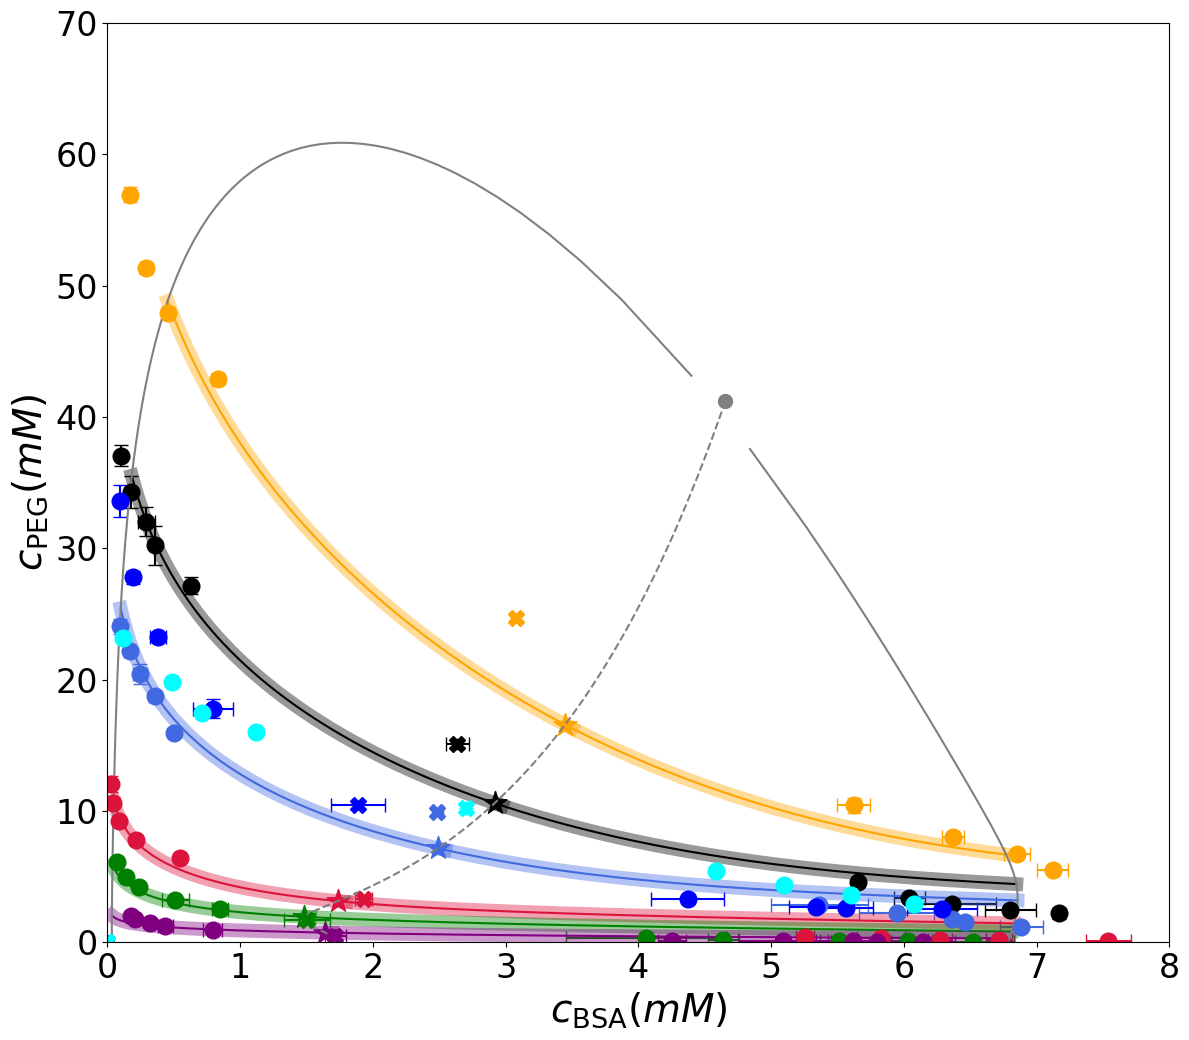

In [8]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

N_steps = 2000 # number of points between PhiP_max and PhiP_min 

solvent = 'good'

guess_c = [0.24, 0.7];

# BSA_PEG_4K = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_6K = PD(3.0e-9, 2.45e-9, mbsa, mpeg6, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_8K = PD(3.0e-9, 3.1e-9, mbsa, mpeg8, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_20K = PD(3.0e-9, 5.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_35K = PD(3.0e-9, 7.8e-9, mbsa, mpeg35, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_100K = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
# BSA_PEG_Q8 = PD(3.0e-9, 24e-9, mbsa, mpegQ8, solvent, N_steps, guess_c).GFVT()
# BSA_PEG_Q10 = PD(3.0e-9, 32e-9, mbsa, mpegQ10, solvent, N_steps, guess_c).GFVT()

BSA_PEG_6p7K = PD(3.0e-9, 2.68e-9, mbsa, 6.7, solvent, N_steps, guess_c).GFVT()
BSA_PEG_7p3K = PD(3.0e-9, 2.83e-9, mbsa, 7.3, solvent, N_steps, guess_c).GFVT()
BSA_PEG_25K = PD(3.0e-9, 6.2e-9, mbsa, 25, solvent, N_steps, guess_c).GFVT()

BSA_PEG_4K_full = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)
BSA_PEG_6K_full = PD(3.0e-9, 2.45e-9, mbsa, mpeg6, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)
BSA_PEG_8K_full = PD(3.0e-9, 3.1e-9, mbsa, mpeg8, solvent, N_steps, guess_c).GFVT_full(PhiP_max=4)
BSA_PEG_20K_full = PD(3.0e-9, 5.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c).GFVT_full(PhiP_max=6)
BSA_PEG_35K_full = PD(3.0e-9, 7.8e-9, mbsa, mpeg35, solvent, N_steps, guess_c).GFVT_full(PhiP_max=10)
BSA_PEG_100K_full = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, solvent, N_steps, guess_c).GFVT_full(PhiP_max=30)
BSA_PEG_Q8_full = PD(3.0e-9, 24e-9, mbsa, mpegQ8, solvent, N_steps, guess_c).GFVT_full(PhiP_max=50)
BSA_PEG_Q10_full = PD(3.0e-9, 32e-9, mbsa, mpegQ10, solvent, N_steps, guess_c).GFVT_full(PhiP_max=60)

BSA_PEG_7p3K_full = PD(3.0e-9, 2.83e-9, mbsa, 7.3, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)
BSA_PEG_25K_full = PD(3.0e-9, 6.2e-9, mbsa, 25, solvent, N_steps, guess_c).GFVT_full(PhiP_max=6)

guess_c = [0.1, 50]
# BSA_PEG_Q16 = PD(3.0e-9, 48e-9, mbsa, mpegQ16, solvent, N_steps, guess_c).GFVT()
BSA_PEG_Q16_full = PD(3.0e-9, 48e-9, mbsa, mpegQ16, solvent, N_steps, guess_c).GFVT_full(PhiP_max=120)

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K + 35K, pH 7, 200 mM KCl', 'blue', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW,'2K+35K Molar (35K only), pH 7, 200 mM KCl', 'cyan', mbsa,  8.57, False)


BSA_PEG_4K.molplot('4K, pH 7, 200 mM KCl, ', 'orange')
BSA_PEG_6K.molplot('6K, pH 7, 200 mM KCl, ', 'black')
BSA_PEG_8K.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue')
BSA_PEG_20K.molplot('20K, pH 7, 200 mM KCl, ', 'crimson')
BSA_PEG_35K.molplot('35K, pH 7, 200 mM KCl, ', 'green')
BSA_PEG_100K.molplot('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='gray')
BSA_PEG_Q8.molplot('Q8, ', 'red')
BSA_PEG_Q10.molplot('Q10, ', 'magenta')
BSA_PEG_Q16.molplot('Q16, ', 'cyan')

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

## molplot_phi

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.6)
# plt.ylim(0,2.5)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

# BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
# BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
# BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

# molplot_phi(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange')
# molplot_phi(gfvt6K_200mM_Z0, f'6K, pH 7, 200 mM KCl, ', 'black')
# molplot_phi(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
BSA_PEG_20K.molplot_phi(f'20K, pH 7, 200 mM KCl, ', 'crimson')
BSA_PEG_35K.molplot_phi(f'35K, pH 7, 200 mM KCl, ', 'green')
BSA_PEG_100K.molplot_phi(f'100K, pH 7, 200 mM KCl, ', 'purple', crit_color='black')

BSA_PEG_Q8.molplot_phi(f'Q=8, pH 7, 200 mM KCl, ', 'red')
BSA_PEG_Q10.molplot_phi(f'Q=10, pH 7, 200 mM KCl, ', 'magenta')
BSA_PEG_Q16.molplot_phi(f'Q=16, pH 7, 200 mM KCl, ', 'cyan')
plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## molplot_phiR

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.45)
plt.ylim(0,2.1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$q_R^{-1/\gamma}\phi^R_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

# BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4,False)
# BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
# BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
# BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
# BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# molplot_phiR(gfvt4K_200mM_Z0_full, '4K, pH 7, 200 mM KCl, ', 'orange', crit_color='red')
# molplot_phiR(gfvt6K_200mM_Z0_full, '6K, pH 7, 200 mM KCl, ', 'black', crit_color='red')
# molplot_phiR(gfvt8K_200mM_Z0_full, '8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='red')
BSA_PEG_20K.molplot_phiR('20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='black')
BSA_PEG_35K.molplot_phiR('35K, pH 7, 200 mM KCl, ', 'green', crit_color='black')
BSA_PEG_100K.molplot_phiR('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='black')
# BSA_PEG_Q8_full.molplot_phiR('Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
# BSA_PEG_Q10_full.molplot_phiR('Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_phiR('Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black', show_legend=True)

# plt.grid(True, which='both', ls='--', lw=0.5)


# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## molplot_phi_analytical

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.xlim(0,0.5)
# plt.ylim(0,2.5)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$\phi_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4, gamma=0)
BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, gamma=0)
BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8, gamma=0)
BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20, gamma=0)
BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35, gamma=0)
BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100, gamma=0)

BSA_PEG_4K.molplot_phi_analytical(f'4K, pH 7, 200 mM KCl, ', 'orange', crit_color='orange')
BSA_PEG_6K.molplot_phi_analytical(f'6K, pH 7, 200 mM KCl, ', 'black', crit_color='black')
BSA_PEG_8K.molplot_phi_analytical(f'8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='royalblue')
BSA_PEG_20K.molplot_phi_analytical(f'20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='crimson')
BSA_PEG_35K.molplot_phi_analytical(f'35K, pH 7, 200 mM KCl, ', 'green', crit_color='green')
BSA_PEG_100K.molplot_phi_analytical(f'100K, pH 7, 200 mM KCl, ', 'purple', crit_color='purple')
BSA_PEG_Q8.molplot_phi_analytical(f'Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
BSA_PEG_Q10.molplot_phi_analytical(f'Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_phi_analytical(f'Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## molplot_analytical

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA}$ (mM)',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG}$ (mM)',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

BSA_PEG_4K.molplot_analytical(f'4K, pH 7, 200 mM KCl, ', 'orange', crit_color='orange')
BSA_PEG_6K.molplot_analytical(f'6K, pH 7, 200 mM KCl, ', 'black', crit_color='black')
BSA_PEG_8K.molplot_analytical(f'8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='royalblue')
BSA_PEG_20K.molplot_analytical(f'20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='crimson')
BSA_PEG_35K.molplot_analytical(f'35K, pH 7, 200 mM KCl, ', 'green', crit_color='green')
BSA_PEG_100K.molplot_analytical(f'100K, pH 7, 200 mM KCl, ', 'purple', crit_color='purple')
BSA_PEG_Q8.molplot_analytical(f'Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
BSA_PEG_Q10.molplot_analytical(f'Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_analytical(f'Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

## theta solvent

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(1e-2,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 500 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 

guess_b = [g1, g2];
PhiP_max = 0.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.35
# gfvt4K_200mM_Z0_theta = PD(3.0e-9, 1.52e-9, mbsa, mpeg4, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 1# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4
guess_c = gfvt6K_200mM_Z0_theta[-1][7]
guess_b = gfvt6K_200mM_Z0_theta[-1][8]

# gfvt6K_200mM_Z0_theta = PD(3.0e-9, 1.95e-9, mbsa, mpeg6, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
# gfvt8K_200mM_Z0_theta = PD(3.0e-9, 2.35e-9, mbsa, mpeg8, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 2.0# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4
guess_c = gfvt20K_200mM_Z0_theta[-1][7]
guess_b = gfvt20K_200mM_Z0_theta[-1][8]

# gfvt20K_200mM_Z0_theta = PD(3.0e-9, 3.7e-9, mbsa, mpeg20, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 2.4# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4
guess_c = gfvt100K_200mM_Z0_theta[-1][7]
guess_b = gfvt100K_200mM_Z0_theta[-1][8]

# gfvt35K_200mM_Z0_theta = PD(3.0e-9, 4.8e-9, mbsa, mpeg35, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
# gfvt100K_200mM_Z0_theta = PD(3.0e-9, 7.0e-9, mbsa, mpeg100, 'theta', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
guess_b = [1e-4, 0.5];
guess_c = [0.24, 0.7];
PhiP_max = 24# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
# gfvt100K_200mM_Z0_rg = PD(3.0e-9, 14.8e-9, mbsa, mpeg100, 'RG', N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)


PD.molplot_dat_err_csv(data_4K_pH7_200mM, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA, '4K, pH 7, 200 mM KCl', 'magenta', mbsa, mpeg4,False)
PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA2, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'magenta', mbsa, mpeg4,False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

PD.from_legacy_list(gfvt4K_200mM_Z0_theta).molplot(f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
gfvt4K_200mM_Z0.molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0_theta).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0_theta).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0_theta).molplot(f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0_theta).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0_theta).molplot(f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'magenta', 'red')
PD.from_legacy_list(gfvt100K_200mM_Z0_rg).molplot(f'100K, pH 7, 200 mM KCl, ', 'red', 'red')

# molplot(gfvt4K_200mM_Z0_theta, f'4K, pH 7, 200 mM KCl, ', 'magenta', 'red')
# molplot(gfvt8K_200mM_Z0_theta, f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')
# plt.savefig('phase_diagram.png')

# plt.yscale('log')

#%%

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

## FVT

In [ ]:
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.plot(x1,y1,'magenta',ms = 3)
# plt.plot(x2,y2, 'magenta',ms = 3)

plt.xlim(0,8)
plt.ylim(1e-2,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.5 # guess protein volume fraction in phase B
N_steps = 100 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
solvent = 'theta'

guess_b = [g1, g2];
guess_c = 0;

PhiP_max = 1.4 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt4K_200mM_Z0_FVT = PD(3.0e-9, 1.52e-9, mbsa, mpeg4, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 2.0 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #
# gfvt6K_200mM_Z0_FVT = PD(3.0e-9, 1.95e-9, mbsa, mpeg6, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
# gfvt8K_200mM_Z0_FVT = PD(3.0e-9, 2.35e-9, mbsa, mpeg8, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 6.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt20K_200mM_Z0_theta = PD(3.0e-9, 3.4e-9, mbsa, mpeg20, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)
PhiP_max = 6.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
# gfvt35K_200mM_Z0_FVT = PD(3.0e-9, 4.8-9, mbsa, mpeg35, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PD.molplot_dat_err_csv(data_4K_pH7_200mM, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4, False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)


molplot_FVT(gfvt4K_200mM_Z0_FVT, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
gfvt4K_200mM_Z0.molplot(f'4K, pH 7, 200 mM KCl, ', 'yellow', 'red')
molplot_FVT(gfvt6K_200mM_Z0_FVT, f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'gray', 'red')
molplot_FVT(gfvt8K_200mM_Z0_FVT, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt8K_200mM_Z0).molplot(f'8K, pH 7, 200 mM KCl, ', 'cyan', 'red')
# molplot(gfvt20K_200mM_Z0_theta, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'red', 'red')
molplot_FVT(gfvt35K_200mM_Z0_FVT, f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'lawngreen', 'red')

# molplot(gfvt4K_200mM_Z0_theta, f'4K, pH 7, 200 mM KCl, ', 'magenta', 'red')
# molplot(gfvt8K_200mM_Z0_theta, f'8K, pH 7, 200 mM KCl, ', 'blue', 'red')
# plt.savefig('phase_diagram.png')

# plt.yscale('log')

# out = np.vstack((Pr_A,Pol_A,Pr_B,Pol_B))
# np.savetxt('phase_diagram_GFVT.txt',np.transpose(out), header = 'Phi Protein in phase A,Phi polymer in phase A,Phi Protein in phase B,Phi polymer in phase B')

# Fig. 1

In [ ]:
# figh = plt.figure(2, figsize = (20,9)) # aspect ratio for slide?
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

N_steps = 2000
guess_c = [0.24, 0.7]
# gfvt4K_200mM_Z0_full = PD(3.0e-9, 1.9e-9, mbsa, mpeg4, solvent, N_steps, guess_c).GFVT_full(PhiP_max=2)

BSA_PEG_4K.molplot('4K, pH 7, 200 mM KCl, ', 'black', n_tie=100)
# molplot_dat_err_csv(data_4K_pH7_200mM, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg4)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg4)
# molplot_dat_err_csv(data_4K_pH7_200mM_MA2, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg4)
PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg4)

# plt.savefig(date_string+'_phase_diagram_all_tie_Z0_good_molar_Fig01.png')
# plt.savefig(date_string+'_phase_diagram_all_tie_Z0_good_molar_Fig01.eps')

# Fig. 2

## Fig. 2A - PEG MW

### Between Triple Points

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

BSA_PEG_4K.molplot('4K, pH 7, 200 mM KCl, ', 'orange')
BSA_PEG_6K.molplot('6K, pH 7, 200 mM KCl, ', 'black')
BSA_PEG_8K.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue')
BSA_PEG_20K.molplot('20K, pH 7, 200 mM KCl, ', 'crimson')
BSA_PEG_35K.molplot('35K, pH 7, 200 mM KCl, ', 'green')
# BSA_PEG_100K.molplot('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='gray')
BSA_PEG_100K.molplot('100K, pH 7, 200 mM KCl, ', 'purple')
BSA_PEG_Q16.molplot('Q=16, pH 7, 200 mM KCl, ', 'magenta')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.eps')

### Full range

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0.01,70)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100)

BSA_PEG_4K_full.molplot('4K, pH 7, 200 mM KCl, ', 'orange', plim=60)
BSA_PEG_6K_full.molplot('6K, pH 7, 200 mM KCl, ', 'black', plim=40)
BSA_PEG_8K_full.molplot('8K, pH 7, 200 mM KCl, ', 'royalblue', plim=26)
BSA_PEG_20K_full.molplot('20K, pH 7, 200 mM KCl, ', 'crimson', plim=13)
BSA_PEG_35K_full.molplot('35K, pH 7, 200 mM KCl, ', 'green', plim=6.5)
BSA_PEG_100K_full.molplot('100K, pH 7, 200 mM KCl, ', 'purple', plim=2)
BSA_PEG_Q10_full.molplot('Q=10, pH 7, 200 mM KCl, ', 'gray')
BSA_PEG_Q16_full.molplot('Q=16, pH 7, 200 mM KCl, ', 'cyan')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_molar_Fig02A.eps')

### Mass (g/L)

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,550)
plt.ylim(0,300)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange')
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', False)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', False)

PD.from_legacy_list(gfvt4K_200mM_Z0_full).molplot('4K, pH 7, 200 mM KCl, ', 'orange', mass=True, plim=60)
PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot('6K, pH 7, 200 mM KCl, ', 'black', mass=True, plim=40)
PD.from_legacy_list(gfvt8K_200mM_Z0_full).molplot('8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True, plim=26)
PD.from_legacy_list(gfvt20K_200mM_Z0_full).molplot('20K, pH 7, 200 mM KCl, ', 'crimson', mass=True, plim=12.4)
PD.from_legacy_list(gfvt35K_200mM_Z0_full).molplot('35K, pH 7, 200 mM KCl, ', 'green', mass=True, plim=6.5)
PD.from_legacy_list(gfvt100K_200mM_Z0_full).molplot('100K, pH 7, 200 mM KCl, ', 'purple', mass=True, plim=2)
# molplot(gfvtQ8_200mM_Z0, f'Q=8, pH 7, 200 mM KCl, ', 'red', mass=True)
# molplot(gfvtQ16_200mM_Z0, f'Q=16, pH 7, 200 mM KCl, ', 'magenta', mass=True)
plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,300)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_35K_GFP, '35K GFP', 'orange', False)


## Fig. 2B

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,40)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4)
# molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8)
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35)
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mw=25K, pH 7, 200 mM KCl', 'magenta', mbsa=mbsa, mpeg=25)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl', 'red', mbsa=mbsa, mpeg=mpeg35)

# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mn=6K, pH 7, 200 mM KCl', 'lawngreen', mbsa=mbsa, mpeg=mpeg6, False)
# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mw=6.7K, pH 7, 200 mM KCl', 'red', mbsa=mbsa, mpeg=6.7, False)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'blue', mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', mbsa=mbsa, mpeg=7.3)
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW8K, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'blue', mbsa=mbsa, mpeg=8)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n,'2K+8K Mn=5K, pH 7, 200 mM KCl', 'lawngreen', mbsa=mbsa,  mpeg=5, False)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n,'2K+8K Mw=6.8K, pH 7, 200 mM KCl', 'yellowgreen', mbsa=mbsa,  mpeg=6.8, False)

# data_2K8K_pH7_200mM_n = np.loadtxt('/Users/arebane/Library/CloudStorage/Dropbox/Abu Dhabi/Science/AUC/Binodals/Final/New format_PEG 2K+8K-200 mM-pH Binodal.csv', delimiter=',')
# data_2K8K_pH7_200mM_n_MW = np.loadtxt('/Users/arebane/Library/CloudStorage/Dropbox/Abu Dhabi/Science/AUC/Binodals/Final/PEG-2K8KK pH-7, 200 mM Salt.csv', delimiter=',')
# data_2K8K_pH7_200mM_n_MW8K = np.loadtxt('/Users/arebane/Library/CloudStorage/Dropbox/Abu Dhabi/Science/AUC/Binodals/Final/PEG-2K8KK pH-7, 200 mM Salt_8Kmass.csv', delimiter=',')



# molplot(gfvt4K_200mM_Z0, '4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa=mbsa, mpeg=mpeg4)
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot('6K, pH 7, 200 mM KCl, ', 'orange', 'red')
# molplot(gfvt6p7K_200mM_Z0, '6.7K, pH 7, 200 mM KCl, ', 'red', 'red')
gfvt7p3K_200mM_Z0.molplot('7.3K, pH 7, 200 mM KCl, ', 'cyan', 'red')
# molplot(gfvt8K_200mM_Z0, '8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa=mbsa, mpeg=mpeg8)
# molplot(gfvt20K_200mM_Z0, '20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot('35K, pH 7, 200 mM KCl, ', 'green', 'red')
# molplot(gfvt25K_200mM_Z0, '25K, pH 7, 200 mM KCl, ', 'magenta', 'red')

# If you have 251.3 mM final osmolarity, it should be 221.1 mM PEG 2K and 30.15 mM PEG 35K.
# I get you need 350 uL of 580 g/L 2K PEG for every 1 mL of 490 g/L 35K PEG.

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_molar_Fig02B.png')
# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_molar_Fig02B.eps')

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(30, 30))

# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

axes[0][0].set_xlim(0,8)
axes[0][0].set_ylim(0,40)
axes[0][0].tick_params(axis='x', labelsize=24)
axes[0][0].tick_params(axis='y', labelsize=24)
axes[0][0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[0][0].set_ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0][0].grid(True, which='both', ls='--', lw=0.5)

axes[0][1].set_xlim(0,8)
axes[0][1].set_ylim(0,40)
axes[0][1].tick_params(axis='x', labelsize=24)
axes[0][1].tick_params(axis='y', labelsize=24)
axes[0][1].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[0][1].set_ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0][1].grid(True, which='both', ls='--', lw=0.5)


axes[1][0].set_xlim(0,500)
axes[1][0].set_ylim(0,250)
axes[1][0].tick_params(axis='x', labelsize=24)
axes[1][0].tick_params(axis='y', labelsize=24)
axes[1][0].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[1][0].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1][0].grid(True, which='both', ls='--', lw=0.5)

axes[1][1].set_xlim(0,500)
axes[1][1].set_ylim(0,250)
axes[1][1].tick_params(axis='x', labelsize=24)
axes[1][1].tick_params(axis='y', labelsize=24)
axes[1][1].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[1][1].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1][1].grid(True, which='both', ls='--', lw=0.5)

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[0][0])
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8, ax=axes[0][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'dodgerblue', mbsa=mbsa, mpeg=6, ax=axes[0][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', mbsa=mbsa, mpeg=7.3, ax=axes[0][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW8K, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'magenta', mbsa=mbsa, mpeg=mpeg8, ax=axes[0][0])

PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', ax=axes[0][0])
PD.from_legacy_list(gfvt8K_200mM_Z0_full).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', ax=axes[0][0])
PD.from_legacy_list(gfvt7p3K_200mM_Z0_full).molplot(f'7.3K, pH 7, 200 mM KCl, ', 'cyan', ax=axes[0][0])

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[0][1])
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', ax=axes[0][1])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35, ax=axes[0][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'yellowgreen', mbsa=mbsa, mpeg=6, ax=axes[0][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mw=25K, pH 7, 200 mM KCl', 'lawngreen', mbsa=mbsa, mpeg=25, ax=axes[0][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl ', 'magenta', mbsa=mbsa, mpeg=mpeg35, ax=axes[0][1])

PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', ax=axes[0][1])
PD.from_legacy_list(gfvt25K_200mM_Z0_full).molplot(f'25K, pH 7, 200 mM KCl, ', 'lawngreen', mbsa=mbsa, mpeg=25, ax=axes[0][1])
PD.from_legacy_list(gfvt35K_200mM_Z0_full).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', ax=axes[0][1])

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', ax=axes[1][0])
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', ax=axes[1][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', ax=axes[1][0])
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW8K, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'magenta', ax=axes[1][0])

PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True, ax=axes[1][0])
PD.from_legacy_list(gfvt8K_200mM_Z0_full).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True, ax=axes[1][0])
PD.from_legacy_list(gfvt7p3K_200mM_Z0_full).molplot(f'7.3K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=7.3, ax=axes[1][0])

PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', ax=axes[1][1])
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', ax=axes[1][1])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', ax=axes[1][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'lawngreen', ax=axes[1][1])
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl ', 'magenta', ax=axes[1][1])

PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True, ax=axes[1][1])
PD.from_legacy_list(gfvt25K_200mM_Z0_full).molplot(f'25K, pH 7, 200 mM KCl, ', 'lawngreen', mass=True, mbsa=mbsa, mpeg=25, ax=axes[1][1])
# molplot(gfvt20K_200mM_Z0_full, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', mass=True, mbsa=mbsa, mpeg=mpeg20, ax=axes[1][1])
PD.from_legacy_list(gfvt35K_200mM_Z0_full).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', mass=True, ax=axes[1][1])

plt.savefig(date_string+'_phase_diagram_PD_Z0_all_FigS1.png')
plt.savefig(date_string+'_phase_diagram_PD_Z0_all_FigS1.eps')

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,250)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange')
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black')
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue')

# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson')
# molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green')

# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mn=6K Mw=6.7K, pH 7, 200 mM KCl', 'magenta')
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K Mw=25, pH 7, 200 mM KCl', 'purple')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K Mw=7, pH 7, 200 mM KCl', 'cyan')
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'cyan')
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_8Konly, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'blue')

# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', False)
# molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl', 'red')

# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa=mbsa, mpeg=mpeg4)
PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True)

PD.from_legacy_list(gfvt8K_200mM_Z0_full).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
# molplot(gfvt35K_200mM_Z0, f'35K, pH 7, 200 mM KCl, ', 'green', 'red', False, mbsa=mbsa, mpeg=mpeg35)
# molplot(gfvt100K_200mM_Z0, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red', False, mbsa=mbsa, mpeg=mpeg100)


# molplot(gfvt6p7K_200mM_Z0, f'6.7K, pH 7, 200 mM KCl, ', 'red', 'red', False, mbsa=mbsa, mpeg=6.7)
PD.from_legacy_list(gfvt7p3K_200mM_Z0_full).molplot(f'7.3K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=7.3)

# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa=mbsa, mpeg=mpeg8)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
# molplot(gfvt35K_200mM_Z0, f'35K, pH 7, 200 mM KCl, ', 'green', mass=True)
# molplot(gfvt25K_200mM_Z0, f'25K, pH 7, 200 mM KCl, ', 'magenta', mass=True)

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.png')
# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.eps')

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,250)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange')
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black')
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue')

PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson')
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green')

# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mn=6K Mw=6.7K, pH 7, 200 mM KCl', 'magenta')
# molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K Mw=25, pH 7, 200 mM KCl', 'purple')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K Mw=7, pH 7, 200 mM KCl', 'cyan')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'cyan')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_8Konly, '2K+8K Mn=8only, pH 7, 200 mM KCl ', 'blue')

# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan', False)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl', 'red')
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'magenta')

# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa=mbsa, mpeg=mpeg4)
PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', mass=True)

# molplot(gfvt8K_200mM_Z0_full, f'8K, pH 7, 200 mM KCl, ', 'royalblue', mass=True)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', 'red', False, mbsa=mbsa, mpeg=mpeg35)
# molplot(gfvt100K_200mM_Z0, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red', False, mbsa=mbsa, mpeg=mpeg100)


# molplot(gfvt6p7K_200mM_Z0, f'6.7K, pH 7, 200 mM KCl, ', 'red', 'red', False, mbsa=mbsa, mpeg=6.7)
# molplot(gfvt7p3K_200mM_Z0_full, f'7.3K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=7.3)
PD.from_legacy_list(gfvt25K_200mM_Z0_full).molplot(f'7.3K, pH 7, 200 mM KCl, ', 'gray', mass=True, mbsa=mbsa, mpeg=25)

# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa=mbsa, mpeg=mpeg8)
# molplot(gfvt20K_200mM_Z0, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa=mbsa, mpeg=mpeg20)
PD.from_legacy_list(gfvt35K_200mM_Z0_full).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', mass=True)
# molplot(gfvt25K_200mM_Z0, f'25K, pH 7, 200 mM KCl, ', 'magenta', mass=True)

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.png')
# plt.savefig(date_string+'_phase_diagram_PD_Z0_good_mass_Fig02B.eps')

## Fig. 2C - Rg scaling

In [ ]:
figh, ax = plt.subplots(1, 1, figsize = (12.75,15))   #width x height, aspect ratio 0.85 (0.87)
# plt.xlim(3000,40000)
plt.xlim(3000,110000)
plt.ylim(1,20)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\mathrm{MW_{PEG}}$ (Da)',fontsize = 28)
plt.ylabel(r'$\mathrm{R_{g}}$ (nm)',fontsize = 28)
plt.tight_layout()

mwlist = [4000, 6000, 8000, 20000, 35000, 100000]
# Rplist = [1.9, 2.45,  3.1, 5.6, 8.4]
Rplist = [1.9, 2.45,  3.1, 5.4, 7.8, 14.8]


mwrange = np.logspace(3.5,110,100)

lgmw = np.asarray([np.log10(mw) for mw in mwlist])

lgRp = np.asarray([np.log10(rgpol) for rgpol in Rplist])

# Perform linear fit
logfit_rg,residuals,_,_,_ = np.polyfit(lgmw, lgRp, 1,full=True)  # Degree 1 polynomial (linear fit)
slope_rg, intercept_rg = logfit_rg
chi_squared = residuals[0]/(len(mwlist)-2)/0.05**2
print(f"Flory Exponent: {slope_rg}, Prefactor: {10**intercept_rg}")
print(f'Chi squared (power): {chi_squared:.4f}')

lgrp_fit =  [10**intercept_rg*x**slope_rg for x in mwrange]
# lgrp_PEG =  [intercept_rg_lin + x*slope_rg_lin for x in mwrange]

plt.loglog(mwlist,Rplist,'ok',markersize=20)
plt.loglog(mwrange, lgrp_fit,'--r')

# ax.xaxis.set_major_locator(mticker.LogLocator(numticks=999))
# ax.xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
# ax.yaxis.set_major_locator(mticker.LogLocator(numticks=999))
# ax.yaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
ax.grid(True, which='both', ls='--', lw=0.5)

[10**intercept_rg*x**slope_rg for x in [25000, 7300, 6700]]

# plt.savefig(date_string+'_MW_Rg_Z0_good_Fig02C.png')
# plt.savefig(date_string+'_MW_Rg_Z0_good_Fig02C.eps')

# Fig. 3

## mM

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(50, 10))

axes[0].set_xlim(0,70)
axes[0].set_ylim(0,2.5)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0].set_ylabel(r'$\mathrm{\delta} (nm)$',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0,70)
axes[1].set_ylim(0,180)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[1].set_ylabel("Osmolarity (mOsm)",fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

axes[2].set_xlim(0,8)
axes[2].set_ylim(0,1)
axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[2].set_ylabel(r'$\alpha$',fontsize = 28)
axes[2].grid(True, which='both', ls='--', lw=0.5)

# axes[1][0].set_xlim(0,200)
# axes[1][0].set_ylim(0.1,1e5)
# axes[1][0].tick_params(axis='x', labelsize=24)
# axes[1][0].tick_params(axis='y', labelsize=24)
# axes[1][0].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
# axes[1][0].set_ylabel(r'$\mathrm{\Pi}$',fontsize = 28)
# axes[1][0].grid(True, which='both', ls='--', lw=0.5)
# axes[1][0].set_yscale('log')

def d_Rg(gfvt_out, pcolor, plabel, ax, plim=100):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rp = {rpeg*1e9:.2f} nm'

    q=rpeg/rbsa
    # qq=q**-1.3
    
    # qq=q**-(1/gamma)

    idx = np.abs(np.array(PEG_Sup) - plim).argmin()

    # print(f'Index of PEG concentration closest to {plim:.0f} mM: {idx}, PEG concentration at this index: {phi_R[idx]*phix_peg:.0f} mM and {rbsa*1e9*qx_Sup_p[idx]:.2f} nm')

    PhiR = np.linspace(0, 2000, 100000)
    Phi_R_approx = np.linspace(np.round(0), 2000, 100000)
    ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [rbsa*1e9*0.865*q**0.88/(1 + 3.95*Phi_pol**1.54)**0.44 for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    ax.plot([phi_PEG*phix_peg for phi_PEG in Phi_R_approx], [rbsa*1e9*0.865*q**0.88/(3.95*Phi_pol**1.54)**0.44 for Phi_pol in Phi_R_approx], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    ax.scatter(phi_R[-1]*phix_peg, rbsa*1e9*qx_Drop_p[-1], label='Droplet Total', color=pcolor, s=150)
    ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R[idx:]], [rbsa*1e9*qx for qx in qx_Sup_p[idx:]], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.6)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in PEG_Drop], [rbsa*1e9*qx for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=5)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in PEG_Sup], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=5)


def pi_scale(gfvt_out, pcolor, plabel, ax, plim=100):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;
    # gamma = 0.698
    gamma = 0.77

    idx = np.abs(np.array(PEG_Sup) - plim).argmin()

    PhiR = np.linspace(0, 2000, 100000)
    Phi_R_approx = np.linspace(np.round(phi_R[0]/3), 2000, 100000)
    pinu = [q**-3*(y + 1.62*y**(3*gamma)) for y in PhiR]

    Rb = 8.314
    T = 273.15 + TC # temperature
    rt = Rb*T

    def inverse(x):
        Rb = 8.314
        # TC = 22
        T = 273.15 + TC # temperature
        return 1000*x/Rb/T
    
    def forward(x):
        Rb = 8.314
        # TC = 22
        T = 273.15 + TC # temperature
        return x*Rb*T/1000
    
    ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [phix_peg*(y + 1.62*y**(3*gamma)) for y in PhiR], label='Droplet Total', color=pcolor)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR[:idx]], [phix_peg*(y + 1.62*y**(3*gamma)) for y in PhiR[:idx]], label='Droplet Total', color=pcolor)
    ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [phix_peg*(1.62*y**(3*gamma)) for y in PhiR], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [phix_peg*(1.62*y**(3*gamma)) for y in PhiR], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R[idx:]], [phix_peg*(y + 1.62*y**(3*gamma)) for y in phi_R[idx:]], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.6)
    ax.scatter(phi_R[-1]*phix_peg, phix_peg*(phi_R[-1] + 1.62*phi_R[-1]**(3*gamma)), color=pcolor, s=150, marker='o')
    # ax.plot([phi_PEG*phix_peg for phi_PEG in Phi_R_approx], [rbsa*1e9*0.865*(q/(3.95*Phi_pol**1.54)**(1/2))**(0.88) for Phi_pol in Phi_R_approx], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    secay = ax.secondary_yaxis('right', functions=(forward, inverse))
    secay.set_ylabel(r'$\Pi$ (kPa)', fontsize=28)
    secay.tick_params(axis='y', labelsize=24)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    
def a_plot(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;
    Phi_BSA_range = np.linspace(0, 0.6, 1000)
    Phi_BSA_Drop = [phi/phix_bsa for phi in BSA_Drop]
    Phi_BSA_Sup = [phi/phix_bsa for phi in BSA_Sup]
    # plt.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    ax.scatter(BSA_Drop[-1], a_Drop[-1], color=pcolor, s=150, marker='o')
    ax.plot([phi for phi in BSA_Drop], [a for a, phi in zip(a_Drop, PEG_Drop)], label='Droplet Total', color=pcolor)
    ax.plot([phi for phi in BSA_Sup], [a for a, phi in zip(a_Sup,PEG_Sup)], label='Droplet Total', color=pcolor, linewidth=1)
    ax.plot(BSA_Sup, [1-phi*(1+qx)**3 for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')
    # ax.plot([phi*phix_bsa for phi in Phi_BSA_range], [1-phi*(1+q)**3 for phi in Phi_BSA_range], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')
    # ax.plot([phi for phi in BSA_Drop], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Drop_p, Phi_BSA_Drop)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')
    # ax.plot([phi for phi in BSA_Sup], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')

def a_plot_peg(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    Phi_BSA_Drop = [phi/phix_bsa for phi in BSA_Drop]
    Phi_BSA_Sup = [phi/phix_bsa for phi in BSA_Sup]
    # plt.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    ax.scatter(PEG_Drop[-1], a_Drop[-1], color=pcolor ,s=150, marker='o')
    ax.plot([phi for phi in PEG_Drop], [a for a, phi in zip(a_Drop, PEG_Drop)], label='Droplet Total', color=pcolor)
    ax.plot([phi for phi in PEG_Sup], [a for a, phi in zip(a_Sup,PEG_Sup)], label='Droplet Total', color=pcolor, linewidth=1)
    # ax.plot([phi for phi in BSA_Drop], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Drop_p, Phi_BSA_Drop)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')
    # ax.plot([phi for phi in BSA_Sup], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')


d_Rg(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[0], plim=60)
d_Rg(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[0], plim=40)
d_Rg(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[0], plim=27)
d_Rg(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[0], plim=13)
d_Rg(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[0], plim=6.5)
d_Rg(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[0], plim=2)
# d_Rg(gfvtQ10_200mM_Z0_full, 'magenta', 'Q10', axes[0])
# d_Rg(gfvtQ16_200mM_Z0_full, 'cyan', 'Q15', axes[0])

pi_scale(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[1], plim=60)
pi_scale(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[1], plim=40)
pi_scale(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[1], plim=26)
pi_scale(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[1], plim=12.4)
pi_scale(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[1], plim=6.5)
pi_scale(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[1], plim=2)
# pi_scale(gfvtQ10_200mM_Z0_full, 'magenta', 'Q10', axes[1])
# pi_scale(gfvtQ16_200mM_Z0_full, 'cyan', 'Q15', axes[1])

a_plot(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[2])
a_plot(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[2])
a_plot(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[2])
a_plot(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[2])
a_plot(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[2])
a_plot(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[2])
# a_plot(gfvtQ10_200mM_Z0_full, 'magenta', 'Q10', axes[2])
# a_plot(gfvtQ16_200mM_Z0_full, 'cyan', 'Q15', axes[2])

# a_plot_peg(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[0][2])
# a_plot_peg(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[0][2])
# a_plot_peg(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[0][2])
# a_plot_peg(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[0][2])
# a_plot_peg(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[0][2])
# a_plot_peg(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[0][2])
# a_plot_peg(gfvtQ10_200mM_Z0_full, 'magenta', 'Q10', axes[0][2])
# a_plot_peg(gfvtQ16_200mM_Z0_full, 'cyan', 'Q15', axes[0][2])

plt.savefig(date_string+'_d_Pi_a.png')
plt.savefig(date_string+'_d_Pi_a.eps')

## g/L

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

fig, axes = plt.subplots(1, 3, figsize=(30, 10))

axes[0].set_xlim(0,500)
axes[0].set_ylim(0,1.5)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[0].set_ylabel(r'$\mathrm{\delta} (nm)$',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0,500)
axes[1].set_ylim(0,45)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1].set_ylabel(r'$\Pi$ (kDa)',fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

axes[2].set_xlim(0,8)
axes[2].set_ylim(0,1)
axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[2].set_ylabel(r'$\alpha$',fontsize = 28)
axes[2].grid(True, which='both', ls='--', lw=0.5)

def d_Rg(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rp = {rpeg*1e9:.2f} nm'

    q=rpeg/rbsa

    PhiR = np.linspace(0, 2000, 100000)
    Phi_R_approx = np.linspace(np.round(phi_R[0]/3), 2000, 100000)
    
    ax.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in PhiR], [rbsa*1e9*0.865*q**0.88/(1 + 3.95*Phi_pol**1.54)**0.44 for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    ax.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in Phi_R_approx], [rbsa*1e9*0.865*q**0.88/(3.95*Phi_pol**1.54)**0.44 for Phi_pol in Phi_R_approx], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    ax.scatter(phi_R[-1]*phix_peg*mpeg_in, rbsa*1e9*qx_Drop_p[-1], label='Droplet Total', color=pcolor, s=150)
    ax.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=5, alpha=0.6)


def pi_scale(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;
    gamma = 0.698

    PhiR = np.linspace(0, 2000, 100000)
    Phi_R_approx = np.linspace(np.round(phi_R[0]/3), 2000, 100000)
    pinu = [q**-3*(y + 1.62*y**(3*gamma)) for y in PhiR]

    ax.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in PhiR], [q**-3*(y + 1.62*y**(3*gamma)) for y in PhiR], label='Droplet Total', color=pcolor)
    ax.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in PhiR], [q**-3*(1.62*y**(3*gamma)) for y in PhiR], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    ax.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in phi_R], [q**-3*(y + 1.62*y**(3*gamma)) for y in phi_R], label='Droplet Total', color=pcolor, linewidth=5, alpha=0.6)


def a_plot(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    Phi_BSA_range = np.linspace(0, 0.6, 1000)
    Phi_BSA_Drop = [phi/phix_bsa for phi in BSA_Drop]
    Phi_BSA_Sup = [phi/phix_bsa for phi in BSA_Sup]

    ax.scatter(BSA_Drop[-1], a_Drop[-1], color=pcolor, s=150, marker='o')
    ax.plot([phi for phi in BSA_Drop], [a for a, phi in zip(a_Drop, PEG_Drop)], label='Droplet Total', color=pcolor, linewidth=1)
    ax.plot([phi for phi in BSA_Sup], [a for a, phi in zip(a_Sup,PEG_Sup)], label='Droplet Total', color=pcolor, linewidth=1)
    ax.plot(BSA_Sup, [1-phi*(1+qx)**3 for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=2, linestyle='--')
    ax.plot([phi*phix_bsa for phi in Phi_BSA_range], [1-phi*(1+q)**3 for phi in Phi_BSA_range], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')


d_Rg(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[0])
d_Rg(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[0])
d_Rg(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[0])
d_Rg(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[0])
d_Rg(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[0])
d_Rg(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[0])

pi_scale(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[1])
pi_scale(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[1])
pi_scale(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[1])
pi_scale(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[1])
pi_scale(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[1])
pi_scale(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[1])

a_plot(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[2])
a_plot(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[2])
a_plot(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[2])
a_plot(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[2])
a_plot(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[2])
a_plot(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[2])

plt.savefig(date_string+'_d_Pi_a_mass.png')
plt.savefig(date_string+'_d_Pi_a_mass.eps')

In [ ]:
def g_plot(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    Rb = 8.314
    T = 273.15 + TC # temperature
    rt = Rb*T

    gamma=0.77
    
    ax.semilogx(BSA_Drop, [phix_peg*(y + 1.62*y**(3*gamma))*g for y,g in zip(phi_R,g_Drop)], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    ax.semilogx(BSA_Sup, [phix_peg*(y + 1.62*y**(3*gamma))*g for y,g in zip(phi_R,g_Sup)], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    ax.scatter(BSA_Drop[-1], phix_peg*(phi_R[-1] + 1.62*phi_R[-1]**(3*gamma))*g_Drop[-1], color=pcolor, s=150, marker='o')
    # ax.semilogx(BSA_Sup, [phix_peg*(1.62*y**(3*gamma)) for y in phi_R], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)

    # ax.scatter(BSA_Drop[-1], Pp_Drop[-1], color=pcolor, s=150, marker='o')

    # ax.semilogx(BSA_Drop, [p for g,p in zip(g_Drop, Pp_Drop)], label='Droplet Total', color=pcolor, linewidth=2)
    # ax.semilogx(BSA_Sup, [p for g,p in zip(g_Sup, Pp_Sup)], label='Droplet Total', color=pcolor, linewidth=2)

    # ax.semilogx(BSA_Drop, [g*p for g,p in zip(g_Drop, Pp_Drop)], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')
    # ax.semilogx(BSA_Sup, [g*p for g,p in zip(g_Sup, Pp_Sup)], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')

def h_plot(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    ax.scatter(BSA_Drop[-1], h_Drop[-1], color=pcolor, s=150, marker='o')
    ax.plot(BSA_Drop, h_Drop, label='Droplet Total', color=pcolor)
    ax.plot(BSA_Sup, h_Sup, label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')

def mu_plot(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    mu_dat_Drop = [mu - mu0 for mu, mu0 in zip(Mu_Drop, Mu0_Drop)]
    mu_dat_Sup = [mu - mu0 for mu, mu0 in zip(Mu_Sup, Mu0_Sup)]

    tmpx = np.linspace(1e-3, 10, 1000)
    tmpy = [12-6*np.log(tmp) for tmp in tmpx]

    ax.scatter(BSA_Drop[-1], mu_dat_Drop[-1], color=pcolor, s=150, marker='o')
    ax.semilogx(BSA_Drop, mu_dat_Drop, label='Droplet Total', color=pcolor)
    ax.semilogx(BSA_Sup, mu_dat_Sup, label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')
    ax.semilogx(tmpx, tmpy, label='Droplet Total', color='gray',linewidth=200, alpha=0.05)
    # ax.plot(BSA_Sup, [1-phi*(1+qx)**3 for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')

fig, axes = plt.subplots(1, 2, figsize=(30, 10))

axes[0].set_xlim(0.1,8)
axes[0].set_ylim(0,400)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[0].set_ylabel(r'Pi_p',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0.1,8)
axes[1].set_ylim(-10,35)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[1].set_ylabel(r'$\mu$',fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

# h_plot(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[0])
# h_plot(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[0])
# h_plot(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[0])
# h_plot(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[0])
# h_plot(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[0])
# h_plot(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[0])

g_plot(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[0])
g_plot(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[0])
g_plot(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[0])
g_plot(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[0])
g_plot(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[0])
g_plot(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[0])

mu_plot(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', axes[1])
mu_plot(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', axes[1])
mu_plot(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', axes[1])
mu_plot(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', axes[1])
mu_plot(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', axes[1])
mu_plot(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', axes[1])

# Fig. 4

In [ ]:
fig, axes = plt.subplots(2,2, figsize=(30, 20))

axes[0][0].set_title("$\Pi$ (mOsm/L)")
axes[0][0].set_xlim(0,8)
axes[0][0].set_ylim(0,180)
axes[0][0].tick_params(axis='x', labelsize=24)
axes[0][0].tick_params(axis='y', labelsize=24)
axes[0][0].set_xlabel(r'$[BSA]_{sup}$ (mM)',fontsize = 28)
axes[0][0].set_ylabel(r'$\Pi$ (mOsm/L)',fontsize = 28)
axes[0][0].grid(True, which='both', ls='--', lw=0.5)

axes[0][1].set_title("Chemical Potential")
axes[0][1].set_xlabel(r'$[BSA]_{sup}$ (mM)',fontsize = 28)
axes[0][1].set_ylabel(r'$\mu_{BSA}/kT$',fontsize = 28)
axes[0][1].set_xlim(0,8)
axes[0][1].set_ylim(-100,-60)
axes[0][1].tick_params(axis='x', labelsize=24)
axes[0][1].tick_params(axis='y', labelsize=24)
# axes[0][1].axhline(0, color='black', linestyle='--', linewidth=1)
# axes[0][1].set_xscale('log')
# axes[0][1].legend(fontsize = 14)
axes[0][1].grid(True, which='both', ls='--', lw=0.5)

axes[1][0].set_xlim(0,0.55)
axes[1][0].set_ylim(0,2.5)
axes[1][0].tick_params(axis='x', labelsize=24)
axes[1][0].tick_params(axis='y', labelsize=24)
axes[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
axes[1][0].set_ylabel(r'$q_R^{1/\gamma}\phi_\mathrm{PEG}$',fontsize = 28)
axes[1][0].grid(True, which='both', ls='--', lw=0.5)

# axes[1][0].set_xlim(0,0.45)
# axes[1][0].set_ylim(0,2.1)
# axes[1][0].tick_params(axis='x', labelsize=24)
# axes[1][0].tick_params(axis='y', labelsize=24)
# axes[1][0].set_xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
# axes[1][0].set_ylabel(r'$q_R^{1/\gamma}\phi_\mathrm{PEG}$',fontsize = 28)
# axes[1][0].grid(True, which='both', ls='--', lw=0.5)


plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$q_R^{-1/\gamma}\phi^R_\mathrm{PEG}$',fontsize = 28)
# plt.tight_layout()

axes[1][1].set_xlim(0,550)
axes[1][1].set_ylim(0,300)
axes[1][1].tick_params(axis='x', labelsize=24)
axes[1][1].tick_params(axis='y', labelsize=24)
axes[1][1].set_xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
axes[1][1].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[1][1].grid(True, which='both', ls='--', lw=0.5)

def Pitot_plot(gfvt_out, pcolor, plabel, ax=None, plim=500):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    Rpr_in, Rpol_in, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params

    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm'

    idx = np.abs(np.array(PEG_Sup) - plim).argmin()

    Rb = 8.314
    T = 273.15 + TC # temperature
    RT = Rb*T

    def inverse(x):
        Rb = 8.314
        # TC = 22
        T = 273.15 + TC # temperature
        return 1000*x/Rb/T
    
    def forward(x):
        Rb = 8.314
        # TC = 22
        T = 273.15 + TC # temperature
        return x*Rb*T/1000

    gamma = 0

    q=Rpol_in/Rpr_in
    # qq=q**-1/gamma
    qq=1

    ax.plot(BSA_Drop, Pi_Drop/RT, label='Droplet Total', color=pcolor)
    ax.plot(BSA_Drop[idx:], Pi_Drop[idx:]/RT, label='Droplet Total', color=pcolor, linewidth=10, alpha=0.6)
    ax.scatter(BSA_Drop[-1], Pi_Drop[-1]/RT, color=pcolor, marker='*', s=200)
    # ax.plot(BSA_Drop, (Pi_Drop-P0_Drop)/RT, label='Polymer', linestyle='--', color=pcolor)
    ax.plot(BSA_Drop, P0_Drop/RT, label='Droplet HS', linestyle='--', color=pcolor)

    ax.plot(BSA_Sup, Pi_Sup/RT, label='Supernatant Total', color=pcolor)
    # ax.plot(BSA_Sup, (Pi_Sup-P0_Sup)/RT, label='Polymer', linestyle='--', color=pcolor)
    ax.plot(BSA_Sup, P0_Sup/RT, label='Sup HS', linestyle='--', color=pcolor)
    ax.plot(BSA_Sup[idx:], Pi_Sup[idx:]/RT, label='Supernatant Total', color=pcolor, linewidth=10, alpha=0.6)

    secay = ax.secondary_yaxis('right', functions=(forward, inverse))
    secay.set_ylabel(r'$\Pi$ (kPa)', fontsize=28)
    secay.tick_params(axis='y', labelsize=24)

def mu_plot(gfvt_out, pcolor, plabel, ax=None, plim=500):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, g_Drop, g_Sup, h_Drop, h_Sup, params = gfvt_out

    Rpr_in, Rpol_in, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params

    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm'

    idx = np.abs(np.array(PEG_Sup) - plim).argmin()

    gamma = 0

    q=Rpol_in/Rpr_in
    # qq=q**-1/gamma
    qq=1

    ax.plot(BSA_Sup, Mu_Sup, label='Mu Total Supernatant', color=pcolor)
    ax.plot(BSA_Drop, Mu_Drop, label='Mu Total Drop', color=pcolor)
    ax.plot(BSA_Sup[idx:], Mu_Sup[idx:], label='Mu Total Supernatant', color=pcolor, linewidth=10, alpha=0.6)
    ax.plot(BSA_Drop[idx:], Mu_Drop[idx:], label='Mu Total Drop', color=pcolor, linewidth=10, alpha=0.6)
    ax.scatter(BSA_Sup[-1], Mu_Sup[-1], color=pcolor, marker='*', s=200)

    # ax.plot(BSA_Sup, [np.exp(-(c/phix_bsa/(1-c/phix_bsa))*(1+q)**3) for c in BSA_Sup], label='Mu Total Supernatant', color=pcolor, linestyle='-.')
    # ax.plot(BSA_Drop, [np.exp(-(c/phix_bsa/(1-c/phix_bsa))*(1+q)**3) for c in BSA_Drop], label='Mu Total Drop', color=pcolor, linestyle='-.')
    
    # ax.plot(BSA_Sup, MuR_Sup, label='Mu Depletion Supernatant', color=pcolor, linestyle='--')
    # ax.plot(BSA_Drop, MuR_Drop, label='Mu Depletion Drop', color=pcolor, linestyle='--')
    
    ax.plot(BSA_Sup, Mu0_Sup, label='Mu HS Supernatant', color=pcolor, linestyle='--')
    ax.plot(BSA_Drop, Mu0_Drop, label='Mu HS Drop', color=pcolor, linestyle='--')


Pitot_plot(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', ax=axes[0][0], plim=60)
Pitot_plot(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', ax=axes[0][0], plim=40)
Pitot_plot(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', ax=axes[0][0], plim=27)
Pitot_plot(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', ax=axes[0][0], plim=13)
Pitot_plot(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', ax=axes[0][0], plim=6.5)
Pitot_plot(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', ax=axes[0][0], plim=2)
# Pitot_plot(gfvtQ10_200mM_Z0_full, 'gray', 'Q10', ax=axes[0][0])
# Pitot_plot(gfvtQ16_200mM_Z0_full, 'black', 'Q16', ax=axes[0][0])

mu_plot(gfvt4K_200mM_Z0_full, 'orange', 'PEG 4K', ax=axes[0][1], plim=60)
mu_plot(gfvt6K_200mM_Z0_full, 'black', 'PEG 6K', ax=axes[0][1], plim=40)
mu_plot(gfvt8K_200mM_Z0_full, 'royalblue', 'PEG 8K', ax=axes[0][1], plim=27)
mu_plot(gfvt20K_200mM_Z0_full, 'crimson', 'PEG 20K', ax=axes[0][1], plim=13)
mu_plot(gfvt35K_200mM_Z0_full, 'green', 'PEG 35K', ax=axes[0][1], plim=6.5)
mu_plot(gfvt100K_200mM_Z0_full, 'purple', 'PEG 100K', ax=axes[0][1], plim=2)
# mu_plot(gfvtQ10_200mM_Z0_full, 'gray', 'Q10', ax=axes[0][1])
# mu_plot(gfvtQ16_200mM_Z0_full, 'black', 'Q16', ax=axes[0][1])

BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa=mbsa, mpeg=mpeg4, ax=axes[1][0])
BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[1][0])
BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa=mbsa, mpeg=mpeg8, ax=axes[1][0])
BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa=mbsa, mpeg=mpeg20, ax=axes[1][0])
BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa=mbsa, mpeg=mpeg35, ax=axes[1][0])
BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa=mbsa, mpeg=mpeg100, ax=axes[1][0])
BSA_PEG_4K_full.molplot_phi('4K, pH 7, 200 mM KCl, ', 'orange', ax=axes[1][0])
BSA_PEG_6K_full.molplot_phi('6K, pH 7, 200 mM KCl, ', 'black', ax=axes[1][0])
BSA_PEG_8K_full.molplot_phi('8K, pH 7, 200 mM KCl, ', 'royalblue', ax=axes[1][0])
BSA_PEG_20K_full.molplot_phi('20K, pH 7, 200 mM KCl, ', 'crimson', ax=axes[1][0])
BSA_PEG_35K_full.molplot_phi('35K, pH 7, 200 mM KCl, ', 'green', ax=axes[1][0])
BSA_PEG_100K_full.molplot_phi('100K, pH 7, 200 mM KCl, ', 'purple', ax=axes[1][0])
# molplot_phi(gfvtQ8_200mM_Z0, 'Q=8, pH 7, 200 mM KCl, ', 'orange', ax=axes[1][0])
# molplot_phi(gfvtQ10_200mM_Z0, 'Q=10, pH 7, 200 mM KCl, ', 'royalblue', ax=axes[1][0])
# molplot_phi(gfvtQ16_200mM_Z0, 'Q=16, pH 7, 200 mM KCl, ', 'magenta', ax=axes[1][0])
# molplot_phi(gfvtQ16_GFP, 'GFP, ', 'cyan', crit_color='black')

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', ax=axes[1][1])
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', ax=axes[1][1])
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', ax=axes[1][1])
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', ax=axes[1][1])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', ax=axes[1][1])
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', ax=axes[1][1])

PD.from_legacy_list(gfvt4K_200mM_Z0_full).molplot('4K, pH 7, 200 mM KCl, ', 'orange', mbsa=mbsa, mpeg=mpeg4, ax=axes[1][1], mass=True, plim=60)
PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot('6K, pH 7, 200 mM KCl, ', 'black', mbsa=mbsa, mpeg=mpeg6, ax=axes[1][1], mass=True, plim=40)
PD.from_legacy_list(gfvt8K_200mM_Z0_full).molplot('8K, pH 7, 200 mM KCl, ', 'royalblue', mbsa=mbsa, mpeg=mpeg8, ax=axes[1][1], mass=True, plim=27)
PD.from_legacy_list(gfvt20K_200mM_Z0_full).molplot('20K, pH 7, 200 mM KCl, ', 'crimson', mbsa=mbsa, mpeg=mpeg20, ax=axes[1][1], mass=True, plim=13)
PD.from_legacy_list(gfvt35K_200mM_Z0_full).molplot('35K, pH 7, 200 mM KCl, ', 'green', mbsa=mbsa, mpeg=mpeg35, ax=axes[1][1], mass=True, plim=6.5)
PD.from_legacy_list(gfvt100K_200mM_Z0_full).molplot('100K, pH 7, 200 mM KCl, ', 'purple', mbsa=mbsa, mpeg=mpeg100, ax=axes[1][1], mass=True, plim=2)
# molplot(gfvtQ8_200mM_Z0, 'Q=8, pH 7, 200 mM KCl, ', 'orange', mbsa=mbsa, mpeg=mpegQ8, ax=axes[1][1], mass=True)
# molplot(gfvtQ10_200mM_Z0, 'Q=10, pH 7, 200 mM KCl, ', 'royalblue', mbsa=mbsa, mpeg=mpegQ10, ax=axes[1][1], mass=True)
# molplot(gfvtQ16_200mM_Z0, 'Q=16, pH 7, 200 mM KCl, ', 'magenta', mbsa=mbsa, mpeg=mpegQ16, ax=axes[1][1], mass=True)

# plt.yscale('log')

plt.savefig(date_string+'_Y_good_mOsmM_Fig04.png')
plt.savefig(date_string+'_Y_good_mOsM_Fig04.eps')

# Fig. 5

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
fig, axes = plt.subplots(2,2, figsize=(30, 20))
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.45)
plt.ylim(0,2.1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$q_R^{-1/\gamma}\phi^R_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

# BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4,False)
# BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
# BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
# BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
# BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# molplot_phiR(gfvt4K_200mM_Z0_full, '4K, pH 7, 200 mM KCl, ', 'orange', crit_color='red')
# molplot_phiR(gfvt6K_200mM_Z0_full, '6K, pH 7, 200 mM KCl, ', 'black', crit_color='red')
# molplot_phiR(gfvt8K_200mM_Z0_full, '8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='red')
BSA_PEG_20K.molplot_phiR('20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='black')
BSA_PEG_35K.molplot_phiR('35K, pH 7, 200 mM KCl, ', 'green', crit_color='black')
BSA_PEG_100K.molplot_phiR('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='black')
# molplot_phiR(gfvtQ8_200mM_Z0_full, 'Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
# molplot_phiR(gfvtQ10_200mM_Z0_full, 'Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_phiR('Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

# GFP

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(30, 10))

axes[0].set_xlim(0,550)
axes[0].set_ylim(0,250)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{BSA}$ (g/L)',fontsize = 28)
axes[0].set_ylabel(r'$c_\mathrm{PEG}$ (g/L)',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0,7)
axes[1].set_ylim(0,12)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{protein} (mM)$',fontsize = 28)
axes[1].set_ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

axes[2].set_xlim(0,100)
axes[2].set_ylim(0,200)
axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_xlabel(r'$c_\mathrm{protein} (g/L)$',fontsize = 28)
axes[2].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[2].grid(True, which='both', ls='--', lw=0.5)
axes[2].legend(fontsize=14)

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K', 'orange', ax=axes[0])
# molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K', 'black', ax=axes[0])
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K', 'royalblue', ax=axes[0])
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K', 'crimson', ax=axes[0])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K', 'green', ax=axes[0])
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K', 'purple', ax=axes[0])
# molplot_analytical(gfvt4K_200mM_Z0_full, '4K', 'orange', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt6K_200mM_Z0_full, '6K', 'black', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt8K_200mM_Z0_full, '8K', 'royalblue', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt20K_200mM_Z0_full, '20K', 'crimson', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt35K_200mM_Z0_full, '35K', 'green', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt100K_200mM_Z0_full, '100K', 'purple', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvtQ8_200mM_Z0_full, 'Q=8, ', 'red', ax=axes[0], crit_color='black', mass=True)
# molplot_analytical(gfvtQ10_200mM_Z0_full, 'Q=10, ', 'magenta', ax=axes[0], crit_color='black', mass=True)
PD.from_legacy_list(gfvtQ16_200mM_Z0_full).molplot_analytical('Q=16, ', 'cyan', ax=axes[0], crit_color='black', mass=True)
PD.from_legacy_list(gfvtQ16_200mM_Z0_full).molplot('Q=16, ', 'gray', ax=axes[0], crit_color='black', mass=True)


N_steps = 2000 # number of points between PhiP_max and PhiP_min 
solvent = 'good'
guess_c = [0.24, 0.7];
rgfp = 1.2e-9
mgfp=27

rPEG_GFP_4K = rpeg4K/rbsa*rgfp
mpeg_GFP_4K = (rPEG_GFP_4K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_6K = rpeg6K/rbsa*rgfp
mpeg_GFP_6K = (rPEG_GFP_6K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_8K = rpeg8K/rbsa*rgfp
mpeg_GFP_8K = (rPEG_GFP_8K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_20K = rpeg20K/rbsa*rgfp
mpeg_GFP_20K = (rPEG_GFP_20K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_35K = rpeg35K/rbsa*rgfp
mpeg_GFP_35K = (rPEG_GFP_35K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_100K = rpeg100K/rbsa*rgfp
mpeg_GFP_100K = (rPEG_GFP_100K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_Q8 = 8*rgfp
mpeg_GFP_Q8 = (rPEG_GFP_Q8/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_Q10 = 10*rgfp
mpeg_GFP_Q10 = (rPEG_GFP_Q10/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_Q16 = 16*rgfp
mpeg_GFP_Q16 = (rPEG_GFP_Q16/14.8e-9)**(1/0.6379)*mpeg100

# gfvt4K_GFP = PD(rgfp, rPEG_GFP_4K, mgfp, mpeg_GFP_4K, solvent, N_steps, guess_c).GFVT()
# gfvt4K_GFP_real = PD(rgfp, rpeg4K, mgfp, mpeg4, solvent, N_steps, guess_c).GFVT()
# gfvt6K_GFP = PD(rgfp, rPEG_GFP_6K, mgfp, mpeg_GFP_6K, solvent, N_steps, guess_c).GFVT()
# gfvt6K_GFP_real = PD(rgfp, rpeg6K, mgfp, mpeg6, solvent, N_steps, guess_c).GFVT()
# gfvt8K_GFP = PD(rgfp, rPEG_GFP_8K, mgfp, mpeg_GFP_8K, solvent, N_steps, guess_c).GFVT()
# gfvt8K_GFP_real = PD(rgfp, rpeg8K, mgfp, mpeg8, solvent, N_steps, guess_c).GFVT()

# gfvt20K_GFP_real = PD(rgfp, rpeg20K, mgfp, mpeg20, solvent, N_steps, guess_c).GFVT()

# gfvt35K_GFP_real = PD(rgfp, rpeg35K, mgfp, mpeg35, solvent, N_steps, guess_c).GFVT()

# gfvt100K_GFP_real = PD(rgfp, rpeg100K, mgfp, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
# gfvtQ8_GFP = PD(rgfp, rPEG_GFP_Q8, mgfp, mpeg_GFP_Q8, solvent, N_steps, guess_c).GFVT()
# gfvtQ10_GFP = PD(rgfp, rPEG_GFP_Q10, mgfp, mpeg_GFP_Q10, solvent, N_steps, guess_c).GFVT()
# guess_c = [0.1, 50]

# gfvt20K_GFP = PD(2.8e-9, rpeg20K, mgfp, mpeg20, solvent, N_steps, guess_c).GFVT()
# gfvt35K_GFP = PD(2.8e-9, rpeg35K, mgfp, mpeg35, solvent, N_steps, guess_c).GFVT()
# gfvt100K_GFP = PD(2.8e-9, rpeg100K, mgfp, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
# gfvtQ16_GFP = PD(2.8e-9, 25e-9, rpegQ16, mpegQ16, solvent, N_steps, guess_c).GFVT()

gfvt35K_GFP_s = PD(2.1e-9, rpeg35K, mgfp, mpeg35, solvent, 50, guess_c).GFVT()
gfvt35K_GFP_s2 = PD(3.2e-9, rpeg35K, mgfp, mpeg35, solvent, 50, guess_c).GFVT()
# gfvtQ16_GFP_s = PD(2.8e-9, rpeg35K, mgfp, mpeg35, solvent, 50, guess_c).GFVT()
# gfvtQ16_GFP_s2 = PD(2.8e-9, rpeg100K, mgfp, mpeg100, solvent, 50, guess_c).GFVT()


# molplot_analytical(gfvt4K_200mM_Z0_full, 'BSA, 4K, ', 'orange', crit_color='black', ax=axes[1])
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot_analytical('BSA, 35K, ', 'green', crit_color='green', ax=axes[1])
PD.from_legacy_list(gfvt100K_200mM_Z0_full).molplot_analytical('BSA, 100K, ', 'purple', crit_color='purple', ax=axes[1])
# molplot_analytical(gfvtQ8_GFP, 'GFP, ', 'blue', crit_color='black', ax=axes[1]))
# molplot_analytical(gfvtQ16_200mM_Z0, 'BSA, ', 'blue', crit_color='blue', ax=axes[1])

# molplot_analytical(gfvt4K_GFP, 'GFP, 4K, ', 'red', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt4K_GFP_real, 'GFP, 4K real, ', 'red', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt6K_GFP, 'GFP, 6K, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt6K_GFP_real, 'GFP, 6K real, ', 'gray', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt8K_GFP, 'GFP, 8K, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt8K_GFP_real, 'GFP, 8K real, ', 'dodgerblue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt20K_GFP, 'GFP, 20K, ', 'hotpink', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt35K_GFP, 'GFP, 35K, ', 'lime', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt35K_GFP_real, 'GFP, 35K real, ', 'lawngreen', crit_color='lawngreen', ax=axes[1])
PD.from_legacy_list(gfvt35K_GFP_real).molplot_analytical('GFP, 35K real, 1.8 nm', 'yellowgreen', crit_color='yellowgreen', ax=axes[1])
PD.from_legacy_list(gfvt100K_GFP_real).molplot_analytical('GFP, 100K real, 1.8 nm ', 'violet', crit_color='violet', ax=axes[1])
# molplot_analytical(gfvtQ8_GFP, 'GFP, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvtQ10_GFP, 'GFP, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvtQ16_GFP, 'GFP, ', 'cyan', ax=axes[1], crit_color='cyan')


# molplot_analytical(gfvt4K_200mM_Z0_full, 'BSA, 4K, ', 'orange', crit_color='orange', ax=axes[2], mass=True)
# molplot_analytical(gfvt35K_200mM_Z0, 'BSA, 35K, ', 'green', crit_color='green', ax=axes[2], mass=True)
# molplot_analytical(gfvt100K_200mM_Z0_full, 'BSA, 100K, ', 'purple', ax=axes[2], crit_color='purple', mass=True)
# molplot_analytical(gfvtQ16_200mM_Z0, 'BSA, Q16, ', 'blue', ax=axes[2], crit_color='blue', mass=True)

# molplot_analytical(gfvt4K_GFP_real, 'GFP, 4K real, ', 'red', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt6K_GFP_real, 'GFP, 6K real, ', 'gray', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt8K_GFP_real, 'GFP, 8K real, ', 'dodgerblue', crit_color='black', ax=axes[2], mass=True)

# molplot_analytical(gfvt20K_GFP_real, 'GFP, 20K real, ', 'hotpink', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt35K_GFP, 'GFP, 35K, ', 'lime', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt35K_GFP_real, 'GFP, 35K real, ', 'yellowgreen', crit_color='yellowgreen', ax=axes[2], mass=True)
# molplot_analytical(gfvt35K_GFP_real, 'GFP, 35K real, 1.8 nm', 'yellowgreen', crit_color='yellowgreen', ax=axes[2], mass=True)
# molplot_analytical(gfvt100K_GFP_real, 'GFP, 100K real, 1.8 nm', 'violet', crit_color='violet', ax=axes[2], mass=True)

# molplot_analytical(gfvtQ16_GFP_s, 'GFP, 35K, 2.8 nm', 'blue', crit_color='blue', ax=axes[2], mass=True)
# molplot_analytical(gfvtQ16_GFP_s2, 'GFP, 100K, 2.8 nm', 'cyan', crit_color='cyan', ax=axes[2], mass=True)

# molplot_analytical(gfvt20K_GFP, 'GFP, 20K, ', 'red', crit_color='crimson', ax=axes[2], mass=True)
PD.from_legacy_list(gfvt35K_GFP).molplot('GFP, 35K, ', 'green', crit_color='green', ax=axes[2], mass=True)
gfvt35K_GFP_s.molplot('GFP, 35K, ', 'lawngreen', crit_color='green', ax=axes[2], mass=True)
gfvt35K_GFP_s2.molplot('GFP, 35K, ', 'aquamarine', crit_color='green', ax=axes[2], mass=True)

# molplot_analytical(gfvt100K_GFP, 'GFP, 100K, ', 'red', crit_color='purple', ax=axes[2], mass=True)
# molplot_analytical(gfvtQ16_GFP, 'GFP, Q16', 'yellow', crit_color='gray', ax=axes[2], mass=True)

PD.molplot_dat_err_csv(data_35K_GFP, '35K GFP', 'green', ax=axes[2])
# molplot_dat_err_csv(data_20K_GFP, '20K GFP', 'crimson', ax=axes[2])



# molplot_analytical(gfvt100K_GFP_real, 'GFP, 100K real, ', 'violet', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvtQ16_GFP, 'GFP, ', 'cyan', ax=axes[2], crit_color='cyan', mass=True)
# plt.yscale('log')

# plt.savefig(date_string+'_analytical_good_Fig05_mass.png')
# plt.savefig(date_string+'_analytical_good_Fig05_mass.eps')

In [ ]:
fig= plt.figure(figsize=(10, 10))

plt.xlim(0,300)
plt.ylim(0,200)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{protein} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.grid(True, which='both', ls='--', lw=0.5)
plt.legend(fontsize=14)


N_steps = 2000 # number of points between PhiP_max and PhiP_min 
solvent = 'good'
guess_c = [0.24, 0.7];
rgfp = 1.2e-9
mgfp=27

# gfvt8K_GFP = PD(2.8e-9, rpeg8K, mgfp, mpeg8, solvent, N_steps, guess_c).GFVT()
# gfvt20K_GFP = PD(2.8e-9, rpeg20K, mgfp, mpeg20, solvent, N_steps, guess_c).GFVT()
# gfvt35K_GFP = PD(2.8e-9, rpeg35K, mgfp, mpeg35, solvent, N_steps, guess_c).GFVT()
# gfvt100K_GFP = PD(2.8e-9, rpeg100K, mgfp, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
# gfvtQ16_GFP = PD(2.8e-9, 25e-9, rpegQ16, mpegQ16, solvent, N_steps, guess_c).GFVT()


# molplot_analytical(gfvt8K_GFP, 'GFP, 8K, ', 'royalblue', crit_color='royalblue', mass=True)
# molplot_analytical(gfvt20K_GFP, 'GFP, 20K, ', 'crimson', crit_color='crimson', mass=True)
# molplot_analytical(gfvt35K_GFP, 'GFP, 35K, ', 'green', crit_color='green', mass=True)
PD.from_legacy_list(gfvt35K_GFP).molplot('GFP, 35K, ', 'green', crit_color='green', mass=True)
# molplot_analytical(gfvt100K_GFP, 'GFP, 100K, ', 'purple', crit_color='purple', mass=True)
# molplot_analytical(gfvtQ16_GFP, 'GFP, Q16, ', 'gray', crit_color='gray', mass=True)

PD.molplot_dat_err_csv(data_35K_GFP, '35K GFP', 'green')
PD.molplot_dat_err_csv(data_20K_GFP, '20K GFP', 'crimson')



# plt.yscale('log')

plt.savefig('../output/'+date_string+'_GFP_mass.png')
plt.savefig('../output/'+date_string+'_GFP_mass.eps')

In [ ]:
np.exp(-1)

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(30, 10))

axes[0].set_xlim(0,550)
axes[0].set_ylim(0,300)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{BSA}$ (g/L)',fontsize = 28)
axes[0].set_ylabel(r'$c_\mathrm{PEG}$ (g/L)',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K', 'orange', ax=axes[0])
# molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K', 'black', ax=axes[0])
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K', 'royalblue', ax=axes[0])
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K', 'crimson', ax=axes[0])
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K', 'green', ax=axes[0])
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K', 'purple', ax=axes[0])
# molplot_analytical(gfvt4K_200mM_Z0_full, '4K', 'orange', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt6K_200mM_Z0_full, '6K', 'black', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt8K_200mM_Z0_full, '8K', 'royalblue', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt20K_200mM_Z0_full, '20K', 'crimson', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt35K_200mM_Z0_full, '35K', 'green', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvt100K_200mM_Z0_full, '100K', 'purple', ax=axes[0], crit_color='gray', mass=True)
# molplot_analytical(gfvtQ8_200mM_Z0_full, 'Q=8, ', 'red', ax=axes[0], crit_color='black', mass=True)
# molplot_analytical(gfvtQ10_200mM_Z0_full, 'Q=10, ', 'magenta', ax=axes[0], crit_color='black', mass=True)
PD.from_legacy_list(gfvtQ16_200mM_Z0_full).molplot_analytical('Q=16, ', 'cyan', ax=axes[0], crit_color='black', mass=True)
PD.from_legacy_list(gfvtQ16_200mM_Z0_full).molplot('Q=16, ', 'gray', ax=axes[0], crit_color='black', mass=True)

plt.savefig(date_string+'_analytical_good_Fig05_mass.png')
plt.savefig(date_string+'_analytical_good_Fig05_mass.eps')

In [ ]:
fig, axes = plt.subplots(1,3, figsize=(30, 10))

axes[0].set_xlim(0,8)
axes[0].set_ylim(0,70)
axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_xlabel(r'$c_\mathrm{BSA}$ (mM)',fontsize = 28)
axes[0].set_ylabel(r'$c_\mathrm{PEG}$ (mM)',fontsize = 28)
axes[0].grid(True, which='both', ls='--', lw=0.5)

axes[1].set_xlim(0,7)
axes[1].set_ylim(0,12)
axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_xlabel(r'$c_\mathrm{protein} (mM)$',fontsize = 28)
axes[1].set_ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[1].grid(True, which='both', ls='--', lw=0.5)

axes[2].set_xlim(0,100)
# axes[2].set_ylim(0,400)
axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_xlabel(r'$c_\mathrm{protein} (g/L)$',fontsize = 28)
axes[2].set_ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
axes[2].grid(True, which='both', ls='--', lw=0.5)

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K', 'orange', ax=axes[0], mbsa=mbsa, mpeg=mpeg4)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K', 'black', ax=axes[0], mbsa=mbsa, mpeg=mpeg6)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K', 'royalblue', ax=axes[0], mbsa=mbsa, mpeg=mpeg8)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K', 'crimson', ax=axes[0], mbsa=mbsa, mpeg=mpeg20)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K', 'green', ax=axes[0], mbsa=mbsa, mpeg=mpeg35)
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K', 'purple', ax=axes[0], mbsa=mbsa, mpeg=mpeg100)
PD.from_legacy_list(gfvt4K_200mM_Z0_full).molplot_analytical('4K', 'orange', ax=axes[0], crit_color='gray')
PD.from_legacy_list(gfvt6K_200mM_Z0_full).molplot_analytical('6K', 'black', ax=axes[0], crit_color='gray')
PD.from_legacy_list(gfvt8K_200mM_Z0_full).molplot_analytical('8K', 'royalblue', ax=axes[0], crit_color='gray')
PD.from_legacy_list(gfvt20K_200mM_Z0_full).molplot_analytical('20K', 'crimson', ax=axes[0], crit_color='gray')
PD.from_legacy_list(gfvt35K_200mM_Z0_full).molplot_analytical('35K', 'green', ax=axes[0], crit_color='gray')
PD.from_legacy_list(gfvt100K_200mM_Z0_full).molplot_analytical('100K', 'purple', ax=axes[0], crit_color='gray')
# molplot_analytical(gfvtQ8_200mM_Z0_full, 'Q=8, ', 'red', ax=axes[0], crit_color='black')
# molplot_analytical(gfvtQ10_200mM_Z0_full, 'Q=10, ', 'magenta', ax=axes[0], crit_color='black')
# molplot_analytical(gfvtQ16_200mM_Z0_full, 'Q=16, ', 'cyan', ax=axes[0], crit_color='black')


N_steps = 2000 # number of points between PhiP_max and PhiP_min 
solvent = 'good'
guess_c = [0.24, 0.7];
rgfp = 1.2e-9
mgfp=27

rPEG_GFP_4K = rpeg4K/rbsa*rgfp
mpeg_GFP_4K = (rPEG_GFP_4K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_6K = rpeg6K/rbsa*rgfp
mpeg_GFP_6K = (rPEG_GFP_6K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_8K = rpeg8K/rbsa*rgfp
mpeg_GFP_8K = (rPEG_GFP_8K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_20K = rpeg20K/rbsa*rgfp
mpeg_GFP_20K = (rPEG_GFP_20K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_35K = rpeg35K/rbsa*rgfp
mpeg_GFP_35K = (rPEG_GFP_35K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_100K = rpeg100K/rbsa*rgfp
mpeg_GFP_100K = (rPEG_GFP_100K/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_Q8 = 8*rgfp
mpeg_GFP_Q8 = (rPEG_GFP_Q8/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_Q10 = 10*rgfp
mpeg_GFP_Q10 = (rPEG_GFP_Q10/14.8e-9)**(1/0.6379)*mpeg100

rPEG_GFP_Q16 = 16*rgfp
mpeg_GFP_Q16 = (rPEG_GFP_Q16/14.8e-9)**(1/0.6379)*mpeg100

# gfvt4K_GFP = PD(rgfp, rPEG_GFP_4K, mgfp, mpeg_GFP_4K, solvent, N_steps, guess_c).GFVT()
# gfvt4K_GFP_real = PD(rgfp, rpeg4K, mgfp, mpeg4, solvent, N_steps, guess_c).GFVT()
# gfvt6K_GFP = PD(rgfp, rPEG_GFP_6K, mgfp, mpeg_GFP_6K, solvent, N_steps, guess_c).GFVT()
# gfvt6K_GFP_real = PD(rgfp, rpeg6K, mgfp, mpeg6, solvent, N_steps, guess_c).GFVT()
# gfvt8K_GFP = PD(rgfp, rPEG_GFP_8K, mgfp, mpeg_GFP_8K, solvent, N_steps, guess_c).GFVT()
# gfvt8K_GFP_real = PD(rgfp, rpeg8K, mgfp, mpeg8, solvent, N_steps, guess_c).GFVT()
# gfvt20K_GFP = PD(rgfp, rPEG_GFP_20K, mgfp, mpeg_GFP_20K, solvent, N_steps, guess_c).GFVT()
# gfvt20K_GFP_real = PD(rgfp, rpeg20K, mgfp, mpeg20, solvent, N_steps, guess_c).GFVT()
# gfvt35K_GFP = PD(rgfp, rPEG_GFP_35K, mgfp, mpeg_GFP_35K, solvent, N_steps, guess_c).GFVT()
# gfvt35K_GFP_real = PD(rgfp, rpeg35K, mgfp, mpeg35, solvent, N_steps, guess_c).GFVT()
# gfvt100K_GFP = PD(rgfp, rPEG_GFP_100K, mgfp, mpeg_GFP_100K, solvent, N_steps, guess_c, critical=True).GFVT()
# gfvt100K_GFP_real = PD(rgfp, rpeg100K, mgfp, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
# gfvtQ8_GFP = PD(rgfp, rPEG_GFP_Q8, mgfp, mpeg_GFP_Q8, solvent, N_steps, guess_c).GFVT()
# gfvtQ10_GFP = PD(rgfp, rPEG_GFP_Q10, mgfp, mpeg_GFP_Q10, solvent, N_steps, guess_c).GFVT()
guess_c = [0.1, 50]
# gfvtQ16_GFP = PD(rgfp, rPEG_GFP_Q16, mgfp, mpeg_GFP_Q16, solvent, N_steps, guess_c).GFVT()

# molplot_analytical(gfvt4K_200mM_Z0_full, 'BSA, 4K, ', 'orange', crit_color='black', ax=axes[1])
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot_analytical('BSA, 35K, ', 'green', crit_color='green', ax=axes[1])
PD.from_legacy_list(gfvt100K_200mM_Z0_full).molplot_analytical('BSA, 100K, ', 'purple', crit_color='purple', ax=axes[1])
# molplot_analytical(gfvtQ8_GFP, 'GFP, ', 'blue', crit_color='black', ax=axes[1]))
# molplot_analytical(gfvtQ16_200mM_Z0, 'BSA, ', 'blue', crit_color='blue', ax=axes[1])

# molplot_analytical(gfvt4K_GFP, 'GFP, 4K, ', 'red', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt4K_GFP_real, 'GFP, 4K real, ', 'red', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt6K_GFP, 'GFP, 6K, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt6K_GFP_real, 'GFP, 6K real, ', 'gray', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt8K_GFP, 'GFP, 8K, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt8K_GFP_real, 'GFP, 8K real, ', 'dodgerblue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt20K_GFP, 'GFP, 20K, ', 'hotpink', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt35K_GFP, 'GFP, 35K, ', 'lime', crit_color='black', ax=axes[1])
# molplot_analytical(gfvt35K_GFP_real, 'GFP, 35K real, ', 'lawngreen', crit_color='lawngreen', ax=axes[1])
PD.from_legacy_list(gfvt35K_GFP1p8_real).molplot_analytical('GFP, 35K real, 1.8 nm', 'yellowgreen', crit_color='yellowgreen', ax=axes[1])
PD.from_legacy_list(gfvt100K_GFP1p8_real).molplot_analytical('GFP, 100K real, 1.8 nm ', 'violet', crit_color='violet', ax=axes[1])
# molplot_analytical(gfvtQ8_GFP, 'GFP, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvtQ10_GFP, 'GFP, ', 'blue', crit_color='black', ax=axes[1])
# molplot_analytical(gfvtQ16_GFP, 'GFP, ', 'cyan', ax=axes[1], crit_color='cyan')


# molplot_analytical(gfvt4K_200mM_Z0_full, 'BSA, 4K, ', 'orange', crit_color='orange', ax=axes[2], mass=True)
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot_analytical('BSA, 35K, ', 'green', crit_color='green', ax=axes[2], mass=True)
PD.from_legacy_list(gfvt100K_200mM_Z0_full).molplot_analytical('BSA, 100K, ', 'purple', ax=axes[2], crit_color='purple', mass=True)
# molplot_analytical(gfvtQ16_200mM_Z0, 'BSA, Q16, ', 'blue', ax=axes[2], crit_color='blue', mass=True)

# molplot_analytical(gfvt4K_GFP_real, 'GFP, 4K real, ', 'red', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt6K_GFP_real, 'GFP, 6K real, ', 'gray', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt8K_GFP_real, 'GFP, 8K real, ', 'dodgerblue', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt20K_GFP, 'GFP, 20K, ', 'red', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt20K_GFP_real, 'GFP, 20K real, ', 'hotpink', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt35K_GFP, 'GFP, 35K, ', 'lime', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvt35K_GFP_real, 'GFP, 35K real, ', 'yellowgreen', crit_color='yellowgreen', ax=axes[2], mass=True)
PD.from_legacy_list(gfvt35K_GFP1p8_real).molplot_analytical('GFP, 35K real, 1.8 nm', 'yellowgreen', crit_color='yellowgreen', ax=axes[2], mass=True)
PD.from_legacy_list(gfvt100K_GFP1p8_real).molplot_analytical('GFP, 100K real, 1.8 nm', 'violet', crit_color='violet', ax=axes[2], mass=True)
# molplot_analytical(gfvtQ16_GFP1p8, 'GFP, Q16, 1.8 nm', 'yellow', crit_color='yellow', ax=axes[2], mass=True)

axes[2].scatter([2.36,1.29,0.64],[255,325,417])
axes[2].scatter([1.93,0.86],[230,391])
axes[2].scatter([2.8,1.9,0.9],[161,184,322])

# molplot_analytical(gfvt100K_GFP_real, 'GFP, 100K real, ', 'violet', crit_color='black', ax=axes[2], mass=True)
# molplot_analytical(gfvtQ16_GFP, 'GFP, ', 'cyan', ax=axes[2], crit_color='cyan', mass=True)
# plt.yscale('log')

plt.savefig(date_string+'_analytical_good_Fig05_mass.png')
plt.savefig(date_string+'_analytical_good_Fig05_mass.eps')

In [ ]:
N_steps = 2000 # number of points between PhiP_max and PhiP_min 
solvent = 'good'
guess_c = [0.24, 0.7];
rgfp_1p8 = 1.8e-9
mgfp=27

rPEG1p8_GFP_4K = rpeg4K/rbsa*rgfp_1p8
mpeg1p8_GFP_4K = (rPEG1p8_GFP_4K/14.8e-9)**(1/0.6379)*mpeg100

rPEG1p8_GFP_6K = rpeg6K/rbsa*rgfp_1p8
mpeg1p8_GFP_6K = (rPEG1p8_GFP_6K/14.8e-9)**(1/0.6379)*mpeg100

rPEG1p8_GFP_8K = rpeg8K/rbsa*rgfp_1p8
mpeg1p8_GFP_8K = (rPEG1p8_GFP_8K/14.8e-9)**(1/0.6379)*mpeg100

rPEG1p8_GFP_20K = rpeg20K/rbsa*rgfp_1p8
mpeg1p8_GFP_20K = (rPEG1p8_GFP_20K/14.8e-9)**(1/0.6379)*mpeg100

rPEG1p8_GFP_35K = rpeg35K/rbsa*rgfp_1p8
mpeg1p8_GFP_35K = (rPEG1p8_GFP_35K/14.8e-9)**(1/0.6379)*mpeg100

rPEG1p8_GFP_100K = rpeg100K/rbsa*rgfp_1p8
mpeg1p8_GFP_100K = (rPEG1p8_GFP_100K/14.8e-9)**(1/0.6379)*mpeg100

rPEG1p8_GFP_Q8 = 8*rgfp_1p8
mpeg1p8_GFP_Q8 = (rPEG1p8_GFP_Q8/14.8e-9)**(1/0.6379)*mpeg100

rPEG_1p8GFP_Q10 = 10*rgfp_1p8
mpeg1p8_GFP_Q10 = (rPEG_1p8GFP_Q10/14.8e-9)**(1/0.6379)*mpeg100

rPEG1p8_GFP_Q16 = 16*rgfp_1p8
mpeg1p8_GFP_Q16 = (rPEG1p8_GFP_Q16/14.8e-9)**(1/0.6379)*mpeg100

gfvt4K_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_4K, mgfp, mpeg1p8_GFP_4K, solvent, N_steps, guess_c).GFVT()
gfvt4K_GFP1p8_real = PD(rgfp_1p8, rpeg4K, mgfp, mpeg4, solvent, N_steps, guess_c).GFVT()
gfvt6K_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_6K, mgfp, mpeg1p8_GFP_6K, solvent, N_steps, guess_c).GFVT()
gfvt6K_GFP1p8_real = PD(rgfp_1p8, rpeg6K, mgfp, mpeg6, solvent, N_steps, guess_c).GFVT()
gfvt8K_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_8K, mgfp, mpeg1p8_GFP_8K, solvent, N_steps, guess_c).GFVT()
gfvt8K_GFP1p8_real = PD(rgfp_1p8, rpeg8K, mgfp, mpeg8, solvent, N_steps, guess_c).GFVT()
gfvt20K_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_20K, mgfp, mpeg1p8_GFP_20K, solvent, N_steps, guess_c).GFVT()
gfvt20K_GFP1p8_real = PD(rgfp_1p8, rpeg20K, mgfp, mpeg20, solvent, N_steps, guess_c).GFVT()
gfvt35K_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_35K, mgfp, mpeg1p8_GFP_35K, solvent, N_steps, guess_c).GFVT()
gfvt35K_GFP1p8_real = PD(rgfp_1p8, rpeg35K, mgfp, mpeg35, solvent, N_steps, guess_c).GFVT()
gfvt100K_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_100K, mgfp, mpeg1p8_GFP_100K, solvent, N_steps, guess_c).GFVT()
gfvt100K_GFP1p8_real = PD(rgfp_1p8, rpeg100K, mgfp, mpeg100, solvent, N_steps, guess_c, critical=True).GFVT()
gfvtQ8_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_Q8, mgfp, mpeg1p8_GFP_Q8, solvent, N_steps, guess_c).GFVT()
gfvtQ10_GFP1p8 = PD(rgfp_1p8, rPEG_1p8GFP_Q10, mgfp, mpeg1p8_GFP_Q10, solvent, N_steps, guess_c).GFVT()
guess_c = [0.1, 50]
gfvtQ16_GFP1p8 = PD(rgfp_1p8, rPEG1p8_GFP_Q16, mgfp, mpeg1p8_GFP_Q16, solvent, N_steps, guess_c).GFVT()

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,0.5)
plt.ylim(0,2.1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\phi_\mathrm{BSA}$',fontsize = 28)
plt.ylabel(r'$q_R^{-1/\gamma}\phi^R_\mathrm{PEG}$',fontsize = 28)
plt.tight_layout()

# BSA_PEG_4K.molplot_dat_err_csv_phi(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', mbsa, mpeg4,False)
# BSA_PEG_6K.molplot_dat_err_csv_phi(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# BSA_PEG_8K.molplot_dat_err_csv_phi(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', mbsa, mpeg8, False)
# BSA_PEG_20K.molplot_dat_err_csv_phi(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', mbsa, mpeg20, False)
# BSA_PEG_35K.molplot_dat_err_csv_phi(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', mbsa, mpeg35, False)
# BSA_PEG_100K.molplot_dat_err_csv_phi(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple', mbsa, mpeg100, False)

# molplot_phiR(gfvt4K_200mM_Z0_full, '4K, pH 7, 200 mM KCl, ', 'orange', crit_color='red')
# molplot_phiR(gfvt6K_200mM_Z0_full, '6K, pH 7, 200 mM KCl, ', 'black', crit_color='red')
# molplot_phiR(gfvt8K_200mM_Z0_full, '8K, pH 7, 200 mM KCl, ', 'royalblue', crit_color='red')
# molplot_phiR(gfvt20K_200mM_Z0, '20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='black')
BSA_PEG_35K.molplot_phiR('35K, pH 7, 200 mM KCl, ', 'green', crit_color='black')
BSA_PEG_100K.molplot_phiR('100K, pH 7, 200 mM KCl, ', 'purple', crit_color='black')
# molplot_phiR(gfvtQ8_200mM_Z0_full, 'Q=8, pH 7, 200 mM KCl, ', 'red', crit_color='black')
# molplot_phiR(gfvtQ10_200mM_Z0_full, 'Q=10, pH 7, 200 mM KCl, ', 'magenta', crit_color='black')
BSA_PEG_Q16.molplot_phiR('Q=16, pH 7, 200 mM KCl, ', 'cyan', crit_color='black')
# molplot_phiR(gfvtQ16_GFP, 'GFP, ', 'blue', crit_color='black')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.yscale('log')

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

# Other various plots

In [ ]:
def Pi_Mu_a_plots(gfvt_out, axes, pcolor, plabel, mpeg):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, params = gfvt_out

    Rpr_in, Rpol_in, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params

    full_label = plabel + f'Rbsa = {Rpr_in*1e9:.2f} nm, Rp = {Rpol_in*1e9:.2f} nm'

    gamma = 0

    q=Rpol_in/Rpr_in
    # qq=q**-1/gamma
    qq=1

    axes[0].plot(BSA_Drop, Pi_Drop/1000, label='Droplet Total', color=pcolor)
    axes[0].plot(BSA_Drop, (Pi_Drop-P0_Drop)/1000, label='Polymer', linestyle='--', color=pcolor)
    axes[0].plot(BSA_Drop, P0_Drop/1000, label='Droplet HS', linestyle=':', color=pcolor)

    axes[0].plot(BSA_Sup, Pi_Sup/1000, label='Supernatant Total', color=pcolor)
    axes[0].plot(BSA_Sup, (Pi_Sup-P0_Sup)/1000, label='Polymer', linestyle='--', color=pcolor)
    axes[0].plot(BSA_Sup, P0_Sup/1000, label='Sup HS', linestyle=':', color=pcolor)
    axes[0].set_title("$\Pi$ (kPa)")
    axes[0].set_xlabel("$[BSA]_{sup}$ (mM)")
    axes[0].set_ylabel("$\Pi$ (kPa)")
    axes[0].set_xlim(0,7)
    axes[0].set_ylim(0,300)
    # axes[0].legend(fontsize = 14)

    phi_BSA_Sup = BSA_Sup/phix_bsa
    phi_BSA_Drop = BSA_Drop/phix_bsa

    phi_PEG_Sup = PEG_Sup/phix_peg
    phi_PEG_Drop = PEG_Drop/phix_peg

    print(phix_bsa)
    print(phix_peg)
    print(f'rescale with q = {q:.2f}, phix_peg/q**3={phix_peg*q**3:.2f}')
    
    axes[1].plot(BSA_Sup, Mu_Sup, label='Mu Total Supernatant', color=pcolor)
    axes[1].plot(BSA_Drop, Mu_Drop, label='Mu Total Drop', color=pcolor)
    
    axes[1].plot(BSA_Sup, MuR_Sup, label='Mu Depletion Supernatant', color=pcolor, linestyle='--')
    axes[1].plot(BSA_Drop, MuR_Drop, label='Mu Depletion Drop', color=pcolor, linestyle='--')

    axes[1].plot(BSA_Sup, Mu0_Sup, label='Mu HS Supernatant', color=pcolor, linestyle='-.')
    axes[1].plot(BSA_Drop, Mu0_Drop, label='Mu HS Drop', color=pcolor, linestyle='-.')
    
    axes[1].set_title("Chemical Potential")
    axes[1].set_xlabel("$[BSA]_{sup}$ (mM)")
    axes[1].set_ylabel("$\mu_{BSA}/kT$")
    axes[1].set_xlim(0,8)
    axes[1].set_ylim(-100,50)
    # axes[1].axhline(0, color='black', linestyle='--', linewidth=1)
    axes[1].set_xscale('log')
    # axes[1].legend(fontsize = 14)

    Q_BSA_A1 = [1-a for a in a_Drop]
    Q_BSA_B1 = [1-a for a in a_Sup]
    
    # c_PEG_A1 = [fPEG*rpeg**-3*(rpeg/rbsa)**2.41 for fPEG, fBSA in zip(phi_PEG_Drop, phi_BSA_Drop)]
    # c_PEG_B1 = [fPEG*rpeg**-3*(rpeg/rbsa)**2.41 for fPEG, fBSA in zip(phi_PEG_Sup, phi_BSA_Sup)]

    c_PEG_A1 = [fPEG*q**1.63*qx**1.5 for qx, fPEG in zip(qx_Drop_p, PEG_Drop)]
    c_PEG_B1 = [fPEG*q**1.63*qx**1.5 for qx, fPEG in zip(qx_Sup_p, PEG_Sup)]

    axes[2].plot(Q_BSA_A1, c_PEG_A1, label='Droplet alpha', linestyle='-', color=pcolor)
    axes[2].plot(Q_BSA_B1, c_PEG_B1, label='Supernatant alpha', linestyle='-', color=pcolor)

    # axes[2].plot(BSA_Drop, c_PEG_A1, label='Droplet alpha', linestyle='--', color=pcolor)
    # axes[2].plot(BSA_Sup, c_PEG_B1, label='Supernatant alpha', linestyle='--', color=pcolor)

    # axes[2].plot(BSA_Drop, [phig*q**1.7 for a, phi, phig, phiR in zip(a_Drop, phi_BSA_Drop, PEG_Drop, phi_R)], label='Droplet alpha', linestyle='-', color=pcolor)

# axes[2].plot(BSA_Drop, [phig*a*rpeg**2 for a, phi, phig in zip(a_Drop, phi_BSA_Drop, PEG_Drop)], label='Droplet alpha', linestyle='-', color=pcolor)
    # axes[2].plot(BSA_Drop, [np.log(phig/a) for a, phi, phig, phi_R in zip(a_Drop, phi_BSA_Drop, PEG_Drop, phi_R)], label='Droplet alpha', linestyle='-', color=pcolor)
    # axes[2].plot(PEG_Drop, [qx for a, phi_peg, phi_bsa, qx in zip(a_Drop, phi_PEG_Drop, phi_BSA_Drop, qx_Drop_p)], label='Droplet alpha', linestyle='-', color=pcolor)
    # axes[2].plot(BSA_Drop, [phi_bsa for phi_bsa in phi_BSA_Drop], label='Droplet Phi_BSA', linestyle='--', color=pcolor)
    # axes[2].plot(BSA_Drop, PEG_Drop/phixpeg, label='Phi PEG', linestyle='-', color=pcolor)

    # axes[2].plot(BSA_Sup, [phig*q**1.7 for a, phi, phig, phiR in zip(a_Sup, phi_BSA_Sup, PEG_Sup, phi_R)], label='Supernatant alpha', linestyle='-', color=pcolor)

# axes[2].plot(BSA_Sup, [phig*a*rpeg**2 for a, phi, phig in zip(a_Sup, phi_BSA_Sup, PEG_Sup)], label='Supernatant alpha', linestyle='-', color=pcolor)
    # axes[2].plot(BSA_Sup, [np.log(phig/a) for a, phi, phig, phiR in zip(a_Sup, phi_BSA_Sup, PEG_Sup, phi_R)], label='Supernatant alpha', linestyle='-', color=pcolor)
    # axes[2].plot(PEG_Sup, [qx for a, phi_peg, phi_bsa, qx in zip(a_Sup, phi_PEG_Sup, phi_BSA_Sup, qx_Sup_p)], label='Supernatant alpha', linestyle='-', color=pcolor)
    # axes[2].plot(BSA_Sup, [phi_bsa for phi_bsa in phi_BSA_Sup], label='Supernatant Phi_BSA', linestyle='--', color=pcolor)
    # a_approx = [1-eta*(1+qx)**3 for eta, qx in zip(phi_BSA_Sup, qx_Sup_p)]
    
    # a_norm_drop = [1-3*(1-a)/((1+qx)**3) for a, eta, qx in zip(a_Drop, phi_BSA_Drop, qx_Drop_p)]
    # a_norm_sup = [1-3*(1-a)/((1+qx)**3) for a, eta, qx in zip(a_Sup, phi_BSA_Sup, qx_Sup_p)]
    
    # axes[2].plot(BSA_Sup, a_approx, label='Supernatant approx', linestyle='--', color=pcolor)
    # axes[2].plot(BSA_Sup, a_norm_sup, label='Supernatant norm', linestyle='-.', color=pcolor)
    # axes[2].plot(BSA_Drop, a_norm_drop, label='Droplet norm', linestyle='-.', color=pcolor)
    # axes[2].plot(BSA_Sup, PEG_Sup/phixpeg, label='Phi PEG', linestyle='-', color=pcolor)

    axes[2].set_title("Free volume fraction")
    axes[2].set_xlabel("$[BSA]_{sup}$ (mM)")
    axes[2].set_ylabel("Free volume fraction")
    # axes[2].set_yscale('log')
    # axes[2].set_xlim(0,8)
    # axes[2].set_ylim(1,30)
    # axes[2].legend(fontsize = 14)
    
fig, axes = plt.subplots(1, 3, figsize=(30, 12))
Pi_Mu_a_plots(gfvt4K_200mM_Z0.to_legacy_list(), axes, 'orange', 'PEG 4K', 4)
Pi_Mu_a_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', 6)
Pi_Mu_a_plots(gfvt8K_200mM_Z0, axes, 'royalblue', 'PEG 8K', 8)
Pi_Mu_a_plots(gfvt20K_200mM_Z0, axes, 'crimson', 'PEG 20K', 20)
Pi_Mu_a_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', 35)
Pi_Mu_a_plots(gfvt100K_200mM_Z0, axes, 'purple', 'PEG 100K', 100)
Pi_Mu_a_plots(gfvtQ10_200mM_Z0, axes, 'gray', 'Q10', 100)
Pi_Mu_a_plots(gfvtQ16_200mM_Z0, axes, 'black', 'Q16', 100)

# plt.savefig(date_string+'_Pi_Mu_a_Z0_hiQ.png')
# plt.savefig(date_string+'_Pi_Mu_a_Z0_hiQ.eps')

## Depletion Length

### (delta/Rg, mM)

### Delta, rescaled

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

plt.xlim(0,250)
# plt.ylim(0,2)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.ylabel(r'$\mathrm{\delta} (nm)$',fontsize = 28)
plt.tight_layout()

def d_Rg(gfvt_out, pcolor, plabel):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, tp, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, outguess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    PhiR = np.linspace(0, 2000, 100000)
    # plt.plot([phi_PEG for phi_PEG in PhiR], [q**(0.44)*0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    plt.plot([phi_PEG for phi_PEG in PhiR], [(q**0.12)*0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in PhiR], [rpeg*1e9*0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in phi_R], [rpeg*1e9*qx/q for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # plt.plot([phi_PEG*phix_peg*mpeg_in for phi_PEG in phi_R], [rpeg*1e9*qx/q for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)   
    # plt.scatter(phix_peg*mpeg_in, rpeg*1e9*0.865*(q/(1 + 3.95*1**1.54)**(1/2))**(0.88)/q, color=pcolor ,s=200)
    # plt.plot([phi_PEG for phi_PEG in phi_R], [qx/q for qx in qx_Drop_p], label='Droplet Total', color=pcolor)


d_Rg(gfvt4K_200mM_Z0.to_legacy_list(), 'orange', 'PEG 4K')
d_Rg(gfvt6K_200mM_Z0, 'black', 'PEG 6K')
d_Rg(gfvt8K_200mM_Z0, 'royalblue', 'PEG 8K')
d_Rg(gfvt20K_200mM_Z0, 'crimson', 'PEG 20K')
d_Rg(gfvt35K_200mM_Z0, 'green', 'PEG 35K')
d_Rg(gfvt100K_200mM_Z0, 'purple', 'PEG 100K')
d_Rg(gfvtQ10_200mM_Z0, 'magenta', 'Q10')
d_Rg(gfvtQ16_200mM_Z0, 'cyan', 'Q15')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_Pi_Mu_a_Z0.png')
# plt.savefig(date_string+'_Pi_Mu_a_Z0.eps')

### Depletion scaling plots

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

fig, axes = plt.subplots(2, 3, figsize=(30, 20))

axes[0][0].set_xlim(0,200)
axes[0][0].set_ylim(0,2.5)
axes[0][0].tick_params(axis='x', labelsize=24)
axes[0][0].tick_params(axis='y', labelsize=24)
axes[0][0].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0][0].set_ylabel(r'$\mathrm{\delta} (nm)$',fontsize = 28)
axes[0][0].grid(True, which='both', ls='--', lw=0.5)

axes[0][1].set_xlim(0,8)
axes[0][1].set_ylim(0,1)
axes[0][1].tick_params(axis='x', labelsize=24)
axes[0][1].tick_params(axis='y', labelsize=24)
axes[0][1].set_xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
axes[0][1].set_ylabel(r'$\alpha$',fontsize = 28)
axes[0][1].grid(True, which='both', ls='--', lw=0.5)

axes[0][2].set_xlim(0,50)
axes[0][2].set_ylim(0,1)
axes[0][2].tick_params(axis='x', labelsize=24)
axes[0][2].tick_params(axis='y', labelsize=24)
axes[0][2].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[0][2].set_ylabel(r'$\alpha$',fontsize = 28)
axes[0][2].grid(True, which='both', ls='--', lw=0.5)

axes[1][0].set_xlim(0,200)
axes[1][0].set_ylim(0.1,1e5)
axes[1][0].tick_params(axis='x', labelsize=24)
axes[1][0].tick_params(axis='y', labelsize=24)
axes[1][0].set_xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
axes[1][0].set_ylabel(r'$\mathrm{\Pi}$',fontsize = 28)
axes[1][0].grid(True, which='both', ls='--', lw=0.5)
axes[1][0].set_yscale('log')

def d_Rg(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rp = {rpeg*1e9:.2f} nm'

    q=rpeg/rbsa
    # qq=q**-1.3
    
    # qq=q**-(1/gamma)

    PhiR = np.linspace(0, 2000, 100000)
    Phi_R_approx = np.linspace(np.round(phi_R[0]/3), 2000, 100000)
    # plt.plot([phi_PEG for phi_PEG in PhiR], [q**(0.44)*0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG for phi_PEG in PhiR], [(q**0.12)*0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [rbsa*1e9*0.865*q**0.88/(1 + 3.95*Phi_pol**1.54)**0.44 for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    ax.plot([phi_PEG*phix_peg for phi_PEG in Phi_R_approx], [rbsa*1e9*0.865*q**0.88/(3.95*Phi_pol**1.54)**0.44 for Phi_pol in Phi_R_approx], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    ax.scatter(phi_R[-1]*phix_peg, rbsa*1e9*qx_Drop_p[-1], label='Droplet Total', color=pcolor, s=150)
    ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.6)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in PEG_Drop], [rbsa*1e9*qx for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=5)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in PEG_Sup], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=5)


def pi_scale(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;
    gamma = 0.698

    PhiR = np.linspace(0, 2000, 100000)
    Phi_R_approx = np.linspace(np.round(phi_R[0]/3), 2000, 100000)
    pinu = [q**-3*(y + 1.62*y**(3*gamma)) for y in PhiR]
    
    ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [q**-3*(y + 1.62*y**(3*gamma)) for y in PhiR], label='Droplet Total', color=pcolor)
    ax.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [q**-3*(1.62*y**(3*gamma)) for y in PhiR], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in Phi_R_approx], [rbsa*1e9*0.865*(q/(3.95*Phi_pol**1.54)**(1/2))**(0.88) for Phi_pol in Phi_R_approx], label='Droplet Total', color=pcolor,linestyle='--', linewidth=1)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # ax.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [rbsa*1e9*qx for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)


def a_plot(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;
    Phi_BSA_range = np.linspace(0, 0.6, 1000)
    Phi_BSA_Drop = [phi/phix_bsa for phi in BSA_Drop]
    Phi_BSA_Sup = [phi/phix_bsa for phi in BSA_Sup]
    # plt.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    ax.scatter(BSA_Drop[-1], a_Drop[-1], color=pcolor, s=150, marker='o')
    ax.plot([phi for phi in BSA_Drop], [a for a, phi in zip(a_Drop, PEG_Drop)], label='Droplet Total', color=pcolor, linewidth=3)
    ax.plot([phi for phi in BSA_Sup], [a for a, phi in zip(a_Sup,PEG_Sup)], label='Droplet Total', color=pcolor, linewidth=3)
    ax.plot(BSA_Sup, [1-phi*(1+qx)**3 for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=2, linestyle='--')
    ax.plot([phi*phix_bsa for phi in Phi_BSA_range], [1-phi*(1+q)**3 for phi in Phi_BSA_range], label='Droplet Total', color=pcolor, linewidth=1, linestyle='--')
    # ax.plot([phi for phi in BSA_Drop], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Drop_p, Phi_BSA_Drop)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')
    # ax.plot([phi for phi in BSA_Sup], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')

def a_plot_peg(gfvt_out, pcolor, plabel, ax):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, cp_list, tp, tp_list, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, guess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    Phi_BSA_Drop = [phi/phix_bsa for phi in BSA_Drop]
    Phi_BSA_Sup = [phi/phix_bsa for phi in BSA_Sup]
    # plt.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    ax.scatter(PEG_Drop[-1], a_Drop[-1], color=pcolor ,s=150, marker='o')
    ax.plot([phi for phi in PEG_Drop], [a for a, phi in zip(a_Drop, PEG_Drop)], label='Droplet Total', color=pcolor, linewidth=3)
    ax.plot([phi for phi in PEG_Sup], [a for a, phi in zip(a_Sup,PEG_Sup)], label='Droplet Total', color=pcolor, linewidth=3)
    # ax.plot([phi for phi in BSA_Drop], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Drop_p, Phi_BSA_Drop)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')
    # ax.plot([phi for phi in BSA_Sup], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')


d_Rg(gfvt4K_200mM_Z0.to_legacy_list(), 'orange', 'PEG 4K', axes[0][0])
d_Rg(gfvt6K_200mM_Z0, 'black', 'PEG 6K', axes[0][0])
d_Rg(gfvt8K_200mM_Z0, 'royalblue', 'PEG 8K', axes[0][0])
d_Rg(gfvt20K_200mM_Z0, 'crimson', 'PEG 20K', axes[0][0])
d_Rg(gfvt35K_200mM_Z0, 'green', 'PEG 35K', axes[0][0])
d_Rg(gfvt100K_200mM_Z0, 'purple', 'PEG 100K', axes[0][0])
# d_Rg(gfvtQ10_200mM_Z0, 'magenta', 'Q10', axes[0][0])
# d_Rg(gfvtQ16_200mM_Z0, 'cyan', 'Q15', axes[0][0])

pi_scale(gfvt4K_200mM_Z0.to_legacy_list(), 'orange', 'PEG 4K', axes[1][0])
pi_scale(gfvt6K_200mM_Z0, 'black', 'PEG 6K', axes[1][0])
pi_scale(gfvt8K_200mM_Z0, 'royalblue', 'PEG 8K', axes[1][0])
pi_scale(gfvt20K_200mM_Z0, 'crimson', 'PEG 20K', axes[1][0])
pi_scale(gfvt35K_200mM_Z0, 'green', 'PEG 35K', axes[1][0])
pi_scale(gfvt100K_200mM_Z0, 'purple', 'PEG 100K', axes[1][0])
# pi_scale(gfvtQ10_200mM_Z0, 'magenta', 'Q10', axes[1][0])
# pi_scale(gfvtQ16_200mM_Z0, 'cyan', 'Q15', axes[1][0])

a_plot(gfvt4K_200mM_Z0.to_legacy_list(), 'orange', 'PEG 4K', axes[0][1])
a_plot(gfvt6K_200mM_Z0, 'black', 'PEG 6K', axes[0][1])
a_plot(gfvt8K_200mM_Z0, 'royalblue', 'PEG 8K', axes[0][1])
a_plot(gfvt20K_200mM_Z0, 'crimson', 'PEG 20K', axes[0][1])
a_plot(gfvt35K_200mM_Z0, 'green', 'PEG 35K', axes[0][1])
a_plot(gfvt100K_200mM_Z0, 'purple', 'PEG 100K', axes[0][1])
# a_plot(gfvtQ10_200mM_Z0, 'magenta', 'Q10', axes[0][1])
# a_plot(gfvtQ16_200mM_Z0, 'cyan', 'Q15', axes[0][1])

a_plot_peg(gfvt4K_200mM_Z0.to_legacy_list(), 'orange', 'PEG 4K', axes[0][2])
a_plot_peg(gfvt6K_200mM_Z0, 'black', 'PEG 6K', axes[0][2])
a_plot_peg(gfvt8K_200mM_Z0, 'royalblue', 'PEG 8K', axes[0][2])
a_plot_peg(gfvt20K_200mM_Z0, 'crimson', 'PEG 20K', axes[0][2])
a_plot_peg(gfvt35K_200mM_Z0, 'green', 'PEG 35K', axes[0][2])
a_plot_peg(gfvt100K_200mM_Z0, 'purple', 'PEG 100K', axes[0][2])
# a_plot_peg(gfvtQ10_200mM_Z0, 'magenta', 'Q10', axes[0][2])
# a_plot_peg(gfvtQ16_200mM_Z0, 'cyan', 'Q15', axes[0][2])



# plt.savefig(date_string+'_Pi_Mu_a_Z0.png')
# plt.savefig(date_string+'_Pi_Mu_a_Z0.eps')

## Volume Fraction

### Free Volume Fraction

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)

plt.xlim(0,8)
plt.ylim(0,1)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.ylabel(r'a',fontsize = 28)
plt.tight_layout()

def a_plot(gfvt_out, pcolor, plabel):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, cp, tp, params = gfvt_out

    rbsa, rpeg, mbsa_in, mpeg_in, solvent, N_steps, PhiP_min, PhiP_max, outguess_c, outguess_tp, guess_b, TC, phix_bsa, phix_peg = params
    q = rpeg/rbsa;

    Phi_BSA_Drop = [phi/phix_bsa for phi in BSA_Drop]
    Phi_BSA_Sup = [phi/phix_bsa for phi in BSA_Sup]
    # plt.plot([phi_PEG*phix_peg for phi_PEG in PhiR], [0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)/q for Phi_pol in PhiR], label='Droplet Total', color=pcolor)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Drop_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    # plt.plot([phi_PEG*phix_peg for phi_PEG in phi_R], [qx/q for qx in qx_Sup_p], label='Droplet Total', color=pcolor, linewidth=10, alpha=0.3)
    plt.plot([phi for phi in BSA_Drop], [a for a, phi in zip(a_Drop, PEG_Drop)], label='Droplet Total', color=pcolor, linewidth=5)
    plt.plot([phi for phi in BSA_Sup], [a for a, phi in zip(a_Sup,PEG_Sup)], label='Droplet Total', color=pcolor, linewidth=5)
    plt.plot([phi for phi in BSA_Drop], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Drop_p, Phi_BSA_Drop)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')
    plt.plot([phi for phi in BSA_Sup], [(1-phi)*np.exp(-((1+qx)**3-1)*(phi/(1-phi))) for qx, phi in zip(qx_Sup_p, Phi_BSA_Sup)], label='Droplet Total', color=pcolor, linewidth=5, linestyle='--')


a_plot(gfvt4K_200mM_Z0.to_legacy_list(), 'orange', 'PEG 4K')
a_plot(gfvt6K_200mM_Z0, 'black', 'PEG 6K')
a_plot(gfvt8K_200mM_Z0, 'royalblue', 'PEG 8K')
a_plot(gfvt20K_200mM_Z0, 'crimson', 'PEG 20K')
a_plot(gfvt35K_200mM_Z0, 'green', 'PEG 35K')
a_plot(gfvt100K_200mM_Z0, 'purple', 'PEG 100K')
# a_plot(gfvtQ10_200mM_Z0, 'magenta', 'Q10')
# a_plot(gfvtQ16_200mM_Z0, 'cyan', 'Q15')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_Pi_Mu_a_Z0.png')
# plt.savefig(date_string+'_Pi_Mu_a_Z0.eps')

# Old Scaling Codes

## SIM Jungbauer

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (10,9))  #width x height, aspect ratio 0.85 (0.87)

plt.xlim(0,30)
plt.ylim(1e0,1e3)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$\mathrm{PEG \%(w/v)}$',fontsize = 28)
plt.ylabel(r'$\log c_\mathrm{BSA}$',fontsize = 28)
plt.tight_layout()

def logy(gfvt_out, mbsa, mpeg, fitrange, pcolor, plabel):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, params = gfvt_out

    params = gfvt_out[-1];
    rbsa = params[0]*1e9;
    rpeg = params[1]*1e9;
    q = rpeg/rbsa;

    # print(rpeg)
    
    k1 = 24*np.pi/np.log(10)
    beta = k1*rpeg**2/(mpeg*1000)*rbsa

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0];
    rpeg = params[1];
    solvent = params[3];

    PEGrange = np.linspace(0,50,100)
    PEGrange_lim = np.linspace(fitrange[0],fitrange[1],100)

    cPEG = np.asarray([c_PEG*mpeg/10 for c_PEG in PEG_Sup])
    S = np.asarray([c_BSA*mbsa for c_BSA in BSA_Sup])
    lgS = np.asarray([np.log(s) for s in S])
    
    cPEG_lim = [c for c, s in zip(cPEG, lgS) if fitrange[0] < c < fitrange[1]]
    lgS_lim = [s for c, s in zip(cPEG, lgS) if fitrange[0] < c < fitrange[1]]
        
    # Perform linear fit
    logfit_S,residuals,_,_,_ = np.polyfit(cPEG_lim, lgS_lim, 1,full=True)  # Degree 1 polynomial (linear fit)
    slope_S, intercept_S = logfit_S
    print(f"Beta: {slope_S:.2f}, Intercept: {intercept_S:.2f}")
    print(f"Beta Theory: {beta:.2f}")

    lgS_fit =  [np.exp(intercept_S+x*slope_S) for x in PEGrange]
    lgS_fit_lim =  [np.exp(intercept_S+x*slope_S) for x in PEGrange_lim]
    # lgrp_PEG =  [intercept_rg_lin + x*slope_rg_lin for x in mwrange]
    
    plt.semilogy(cPEG, S, label='Sup', color=pcolor)
    # plt.semilogy(cPEG, [10**(-beta*c_PEG*mpeg/10+2) for c_PEG in PEG_Sup], linestyle='--', label='Sup', color=pcolor)
    plt.semilogy(PEGrange, lgS_fit, linestyle='--', label='Sup', color=pcolor)
    plt.semilogy(PEGrange_lim, lgS_fit_lim, linestyle='--', label='Sup', color='red')


def logS_plot_dat(data, plabel, pcolor):
    
    BN_BSA_sup = data[:,2]
    BN_BSA_sup_err = data[:,3]

    BN_PEG_sup = data[:,8]/10
    BN_PEG_sup_err = data[:,9]/10
    
    # Plot with adjusted cap thickness
    # plt.errorbar(BN_PEG_sup, BN_BSA_sup, yerr=BN_PEG_sup_err, xerr=BN_BSA_sup_err, markersize=12,fmt='o', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' binodal')
    plt.scatter(BN_PEG_sup, BN_BSA_sup, s=250, c=pcolor, label=plabel + ' binodal')
    plt.yscale('log')
    # plt.semilogy(BN_PEG_sup, BN_BSA_sup, markersize=12,fmt='o', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' binodal')

logy(gfvt4K_200mM_Z0.to_legacy_list(), mbsa, mpeg4, [15, 25], 'orange', 'PEG 4K')
logy(gfvt6K_200mM_Z0, mbsa, mpeg6, [15, 25], 'black', 'PEG 6K')
logy(gfvt8K_200mM_Z0, mbsa, mpeg8, [12, 22], 'royalblue', 'PEG 8K')
logy(gfvt20K_200mM_Z0, mbsa, mpeg20, [8, 25], 'crimson', 'PEG 20K')
logy(gfvt35K_200mM_Z0, mbsa, mpeg35, [8, 25], 'green', 'PEG 35K')
logy(gfvt100K_200mM_Z0, mbsa, mpeg100, [8, 25], 'purple', 'PEG 100K')

logS_plot_dat(data_4K_pH7_200mM_MA3, f'4K, pH 7, 200 mM KCl, ', 'orange')
logS_plot_dat(data_6K_pH7_200mM_SD, f'6K, pH 7, 200 mM KCl, ', 'black')
logS_plot_dat(data_8K_pH7_200mM_SD, f'8K, pH 7, 200 mM KCl, ', 'royalblue')
logS_plot_dat(data_20K_pH7_200mM, f'20K, pH 7, 200 mM KCl, ', 'crimson')
logS_plot_dat(data_35K_pH7_200mM, f'35K, pH 7, 200 mM KCl, ', 'green')
logS_plot_dat(data_100K_pH7_200mM, f'100K, pH 7, 200 mM KCl, ', 'purple')

plt.grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_Pi_Mu_a_Z0.png')
# plt.savefig(date_string+'_Pi_Mu_a_Z0.eps')

## scale_dat_binodal()

In [ ]:
def scale_dat_binodal(data, ax, plabel, pcolor, rbsa, rpeg, solvent, mbsa=0, mpeg=0):
    
    q = rpeg/rbsa

    rpeg = rpeg*1e9
    rbsa = rbsa*1e9
    
    vbsa = (4/3*np.pi*rbsa**3*6.022e23)
    vpeg = (4/3*np.pi*rpeg**3*6.022e23)

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + solvent + ' solvent GFVT binodal'
    print(full_label)

    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
            
        a = 3*qx+3*qx**2 + qx**3
        b = 9/2*qx**2+3*qx**3
        c = 3*qx**3

        return a*y + b*y**2 + c*y**3
    
    
    if mbsa == 0 or mpeg == 0:

        BN_BSA_sup = data[:,2]
        BN_BSA_sup_err = data[:,3]
        BN_BSA_drop = data[:,4]
        BN_BSA_drop_err = data[:,5]

        BN_PEG_sup = data[:,8]
        BN_PEG_sup_err = data[:,9]
        BN_PEG_drop = data[:,10]
        BN_PEG_drop_err = data[:,11]
        
        CP_BSA = data[:,12]
        CP_BSA_err = data[:,13]
        CP_PEG = data[:,14]
        CP_PEG_err = data[:,15]

        CP_BSA = data[:,12]
        CP_BSA_err = data[:,13]
        CP_PEG = data[:,14]
        CP_PEG_err = data[:,15]
        
    else:

        BN_BSA_sup = data[:,2]/mbsa
        BN_BSA_sup_err = data[:,3]/mbsa
        BN_BSA_drop = data[:,4]/mbsa
        BN_BSA_drop_err = data[:,5]/mbsa

        BN_PEG_sup = data[:,8]/mpeg
        BN_PEG_sup_err = data[:,9]/mpeg
        BN_PEG_drop = data[:,10]/mpeg
        BN_PEG_drop_err = data[:,11]/mpeg


        CP_BSA = data[:,12]/mbsa
        # CP_BSA_err = data[:,13]/mbsa
        CP_PEG = data[:,14]/mpeg
        # CP_PEG_err = data[:,15]/mpeg

    def get_a(cbsa, cpeg, q, solvent):

        Phi = cbsa*vbsa
        Phi_pol = cpeg*vpeg

        return (1 - Phi)*np.exp(-Qf(Phi, Phi_pol, q, solvent))
    
    BN_BSA_sup_exc = [np.log10(cbsa) for cbsa in BN_BSA_sup]
    PEG_Sup_exc = [cpeg*(rpeg/(rbsa+rbsa*0.865*(q/(1 + 3.95*(cpeg*vpeg)**1.54)**(1/2))**(0.88)))**3 for cpeg, cbsa in zip(BN_PEG_sup,BN_BSA_sup)]
    # PhiR_Sup = [cpeg/get_a0(cbsa, cpeg, q, solvent)*vpeg for cpeg, cbsa in zip(BN_PEG_sup,BN_BSA_sup)]
    
    
    BN_BSA_drop_exc = [np.log10(cbsa) for cbsa in BN_BSA_drop]
    PEG_Drop_exc = [cpeg*(rpeg/(rbsa+rbsa*0.865*(q/(1 + 3.95*(cpeg*vpeg)**1.54)**(1/2))**(0.88)))**3 for cpeg, cbsa in zip(BN_PEG_drop,BN_BSA_drop)]
    # PhiR_Drop = [cpeg/get_a0(cbsa, cpeg, q, solvent)*vpeg for cpeg, cbsa in zip(BN_PEG_drop,BN_BSA_drop)]
    
    # Plot with adjusted cap thickness
    ax[0].scatter(BN_BSA_sup, PEG_Sup_exc, c=pcolor, label=full_label, s=240)
    # ax[0].scatter(BN_BSA_sup, PEG_Sup_exc2, c=pcolor, marker="X", s=240)
    # ax[0].scatter(BN_BSA_sup, PEG_Sup_exc3, c=pcolor, marker="s", s=240)

    ax[0].scatter(BN_BSA_drop, PEG_Drop_exc, c=pcolor, label=full_label, s=240)
    # ax[0].scatter(BN_BSA_drop, PEG_Drop_exc2, c=pcolor, marker="X", s=240)
    # ax[0].scatter(BN_BSA_drop, PEG_Drop_exc3, c=pcolor, marker="s", s=240)

    ax[0].grid(True, which='both', ls='--', lw=0.5)
    ax[1].grid(True, which='both', ls='--', lw=0.5)

    ax[1].scatter(BN_BSA_sup, PEG_Sup_exc, c=pcolor, label=full_label)
    ax[1].scatter(BN_BSA_drop, PEG_Drop_exc, c=pcolor,)
    
    return

def scale_dat_binodal_a(data, ax, plabel, pcolor, rbsa, rpeg, solvent, mbsa=0, mpeg=0):
    
    q = rpeg/rbsa

    vbsa = (4/3*np.pi*rbsa**3*6.022e23)
    vpeg = (4/3*np.pi*rpeg**3*6.022e23)
    
    rpeg = rpeg*1e9
    rbsa = rbsa*1e9


    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + solvent + ' solvent GFVT binodal'
    print(full_label)

    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
            
        a = 3*qx+3*qx**2 + qx**3
        b = 9/2*qx**2+3*qx**3
        c = 3*qx**3

        return a*y + b*y**2 + c*y**3
    
    
    if mbsa == 0 or mpeg == 0:

        BN_BSA_sup = data[:,2]
        BN_BSA_sup_err = data[:,3]
        BN_BSA_drop = data[:,4]
        BN_BSA_drop_err = data[:,5]

        BN_PEG_sup = data[:,8]
        BN_PEG_sup_err = data[:,9]
        BN_PEG_drop = data[:,10]
        BN_PEG_drop_err = data[:,11]
        
        CP_BSA = data[:,12]
        CP_BSA_err = data[:,13]
        CP_PEG = data[:,14]
        CP_PEG_err = data[:,15]

        CP_BSA = data[:,12]
        CP_BSA_err = data[:,13]
        CP_PEG = data[:,14]
        CP_PEG_err = data[:,15]
        
    else:

        BN_BSA_sup = data[:,2]/mbsa
        BN_BSA_sup_err = data[:,3]/mbsa
        BN_BSA_drop = data[:,4]/mbsa
        BN_BSA_drop_err = data[:,5]/mbsa

        BN_PEG_sup = data[:,8]/mpeg
        BN_PEG_sup_err = data[:,9]/mpeg
        BN_PEG_drop = data[:,10]/mpeg
        BN_PEG_drop_err = data[:,11]/mpeg


        CP_BSA = data[:,12]/mbsa
        # CP_BSA_err = data[:,13]/mbsa
        CP_PEG = data[:,14]/mpeg
        # CP_PEG_err = data[:,15]/mpeg

    def get_a(cbsa, cpeg, q, solvent):

        Phi = cbsa*vbsa
        Phi_pol = cpeg*vpeg

        return (1 - Phi)*np.exp(-Qf(Phi, Phi_pol, q, solvent))
    
    BN_BSA_sup_exc = [cbsa for cbsa in BN_BSA_sup]
    PEG_Sup_exc = [get_a(cbsa, cpeg, q, solvent)*cpeg*rpeg**2 for cpeg, cbsa in zip(BN_PEG_sup,BN_BSA_sup)]
    
    BN_BSA_drop_exc = [cbsa for cbsa in BN_BSA_drop]
    PEG_Drop_exc = [get_a(cbsa, cpeg, q, solvent)*cpeg*rpeg**2 for cpeg, cbsa in zip(BN_PEG_drop,BN_BSA_drop)]
    
    # Plot with adjusted cap thickness
    ax[0].scatter(BN_BSA_sup, PEG_Sup_exc, c=pcolor, label=full_label, s=240)
    ax[0].scatter(BN_BSA_drop, PEG_Drop_exc, c=pcolor, label=full_label, s=240)

    ax[0].grid(True, which='both', ls='--', lw=0.5)
    ax[1].grid(True, which='both', ls='--', lw=0.5)

    ax[1].scatter(BN_BSA_sup, PEG_Sup_exc, c=pcolor, label=full_label, s=240)
    ax[1].scatter(BN_BSA_drop, PEG_Drop_exc, c=pcolor, s=240)

    
    return

## binodal_scaling_plots()

In [ ]:
def binodal_scaling_plots(gfvt_out, axes, pcolor, plabel, form, scheme = 'gfvt'):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, params = gfvt_out

    # params = [Rpr_in, Rpol_in, mbsa, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg]
    params = gfvt_out[-1];

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0];
    rpeg = params[1];
    solvent = params[3]
    
    q = rpeg/rbsa;

    rpeg = rpeg*1e9
    rbsa = rbsa*1e9

    phi_BSA_Sup = BSA_Sup/phixbsa
    phi_BSA_Drop = BSA_Drop/phixbsa

    phi_PEG_Sup = PEG_Sup/phixpeg
    phi_PEG_Drop = PEG_Drop/phixpeg

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + solvent + ' solvent GFVT binodal'
    print(full_label)


    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
            
        a = (1+qx)**3 -1
        a = 3*qx
        b = 9/2*qx**2+3*qx**3
        c = 3*qx**3

        Q3 = a*y + b*y**2 + c*y**3
        Q2 = a*y + b*y**2
        Q1 = a*y
        
        return [Q1, Q2, Q3]

    def Qfvt(Phi, Phi_pol, q):
        
        y = Phi/(1-Phi)
            
        a = 3*q+3*q**2 + q**3
        b = 9/2*q**2+3*q**3
        c = 3*q**3

        Q3 = a*y + b*y**2 + c*y**3
        Q2 = a*y + b*y**2
        Q1 = a*y
        
        return [Q1, Q2, Q3]
    
    def get_a(cbsa, Phi_pol_R, q, solvent, ii):

        Phi = cbsa/phixbsa

        Q1, Q2, Q3 = Qf(Phi, Phi_pol_R, q, solvent)

        if ii == 3:
            a = (1 - Phi)*np.exp(-Q3)
        elif ii == 2:
            a = (1 - Phi)*np.exp(-Q2)
        elif ii == 1:
            a = (1 - Phi)*np.exp(-Q1)
        
        return a

    def get_a_fvt(cbsa, Phi_pol_R, q, ii):

        Phi = cbsa/phixbsa

        Q1, Q2, Q3 = Qfvt(Phi, Phi_pol_R, q)

        if ii == 3:
            a = (1 - Phi)*np.exp(-Q3)
        elif ii == 2:
            a = (1 - Phi)*np.exp(-Q2)
        elif ii == 1:
            a = (1 - Phi)*np.exp(-Q1)
        
        return a
        
    PEG_Sup_exc = [a*cpeg*rpeg**2 for cpeg, cbsa, a, phiR in zip(PEG_Sup, BSA_Sup, a_Sup, phi_R)]
    BSA_Sup_exc = [cbsa for cbsa in BSA_Sup]
        
    PEG_Drop_exc = [a*cpeg*rpeg**2 for cpeg, cbsa, a, phiR in zip(PEG_Drop,BSA_Drop, a_Drop, phi_R)]
    BSA_Drop_exc = [cbsa for cbsa in BSA_Drop]

    axes[0].loglog(BSA_Sup_exc, PEG_Sup_exc, label=plabel + ' Supernatant', color=pcolor, linestyle=form)
    axes[0].loglog(BSA_Drop_exc, PEG_Drop_exc, label=plabel + ' Drop', color=pcolor, linestyle=form)
    
    axes[1].plot(BSA_Sup_exc, PEG_Sup_exc, label=plabel + ' Supernatant', color=pcolor, linestyle=form)
    axes[1].plot(BSA_Drop_exc, PEG_Drop_exc, label=plabel + ' Drop', color=pcolor, linestyle=form)


## good solvent scaling plots

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(30, 12))
fig, axes = plt.subplots(1, 2, figsize=(18, 10))

scheme = 'a'

binodal_scaling_plots(gfvt4K_200mM_Z0.to_legacy_list(), axes, 'orange', 'PEG 4K', '-', scheme)
binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '-', scheme)
binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '-', scheme)
binodal_scaling_plots(gfvt20K_200mM_Z0, axes, 'crimson', 'PEG 20K', '-', scheme)
binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '-', scheme)

axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_title("Binodal", fontsize = 25)
axes[0].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[0].set_ylabel("$a*cpeg*rPEG^2$", fontsize = 25)
axes[0].set_xlim(1e-2,1e1)
axes[0].set_ylim(1e-2,6e2)
axes[0].legend(fontsize = 18)
axes[0].grid(True, which='both', ls='--', lw=0.5)

scale_dat_binodal_a(data_4K_pH7_200mM, axes, '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
scale_dat_binodal_a(data_4K_pH7_200mM_MA2, axes, '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
scale_dat_binodal_a(data_6K_pH7_200mM_SD, axes, '6K, pH 7, 200 mM KCl', 'black', 3e-9, 2.45e-9, 'good', mbsa, mpeg6)
scale_dat_binodal_a(data_8K_pH7_200mM_SD, axes, '8K, pH 7, 200 mM KCl', 'royalblue', 3e-9, 3.1e-9, 'good', mbsa, mpeg8)
scale_dat_binodal_a(data_20K_pH7_200mM, axes, '20K, pH 7, 200 mM KCl', 'crimson', 3e-9,  5.0e-9, 'good', mbsa, mpeg20)
scale_dat_binodal_a(data_35K_pH7_200mM, axes, '35K, pH 7, 200 mM KCl', 'green', 3e-9,  8.4e-9, 'good', mbsa, mpeg35)
scale_dat_binodal_a(data_100K_pH7_200mM, axes, '100K, pH 7, 200 mM KCl', 'purple', 3e-9,  15e-9, 'good', mbsa, mpeg100)

axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_title("Binodal", fontsize = 25)
axes[1].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[1].set_ylabel("a*cpeg*rPEG^2", fontsize = 25)
axes[1].set_xlim(0,8)
axes[1].set_ylim(0,400)
axes[1].grid(True, which='both', ls='--', lw=0.5)

plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt.png')
plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt.eps')

## calculate free volume fraction for phi_pol = 0

In [ ]:
def alpha_plots(gfvt_out, axes, pcolor, plabel, form, fitrange):
    phi_R, BSA_Drop, PEG_Drop, a_Drop, BSA_Sup, PEG_Sup, a_Sup, qx_Drop_p, dPidPhiP_Drop_p, qx_Sup_p, dPidPhiP_Sup_p, Pi_Drop, P0_Drop, Pp_Drop, Mu_Drop, Mu_Drop, Mu0_Drop, MuR_Drop, Pi_Sup, P0_Sup, Pp_Sup, Mu_Sup, Mu0_Sup, MuR_Sup, params = gfvt_out

    # params = [Rpr_in, Rpol_in, mbsa, solvent, N_steps, PhiP_min, PhiP_max, guess_c, guess_b, TC, phix_bsa, phix_peg]
    params = gfvt_out[-1];

    phixbsa = params[-2];
    phixpeg = params[-1];
    rbsa = params[0];
    rpeg = params[1];
    solvent = params[3]
    
    q = rpeg/rbsa;

    phi_BSA_Sup = BSA_Sup/phixbsa
    phi_BSA_Drop = BSA_Drop/phixbsa

    phi_PEG_Sup = PEG_Sup/phixpeg
    phi_PEG_Drop = PEG_Drop/phixpeg

    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + solvent + ' solvent GFVT binodal'
    print(full_label)

    rpeg = rpeg*1e9
    rbsa = rbsa*1e9


    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
            
        a = (1+qx)**3 -1
        a = 3*qx
        b = 9/2*qx**2+3*qx**3
        c = 3*qx**3

        Q3 = a*y + b*y**2 + c*y**3
        Q2 = a*y + b*y**2
        Q1 = a*y
        
        return [Q1, Q2, Q3]

    def Qfvt(Phi, Phi_pol, q):
        
        y = Phi/(1-Phi)
            
        a = 3*q+3*q**2 + q**3
        b = 9/2*q**2+3*q**3
        c = 3*q**3

        Q3 = a*y + b*y**2 + c*y**3
        Q2 = a*y + b*y**2
        Q1 = a*y
        
        return [Q1, Q2, Q3]
    
    def get_a(cbsa, Phi_pol_R, q, solvent, ii):

        Phi = cbsa/phixbsa

        Q1, Q2, Q3 = Qf(Phi, Phi_pol_R, q, solvent)

        if ii == 3:
            a = (1 - Phi)*np.exp(-Q3)
        elif ii == 2:
            a = (1 - Phi)*np.exp(-Q2)
        elif ii == 1:
            a = (1 - Phi)*np.exp(-Q1)
        
        return a

    def get_a_fvt(cbsa, Phi_pol_R, q, ii):

        Phi = cbsa/phixbsa

        Q1, Q2, Q3 = Qfvt(Phi, Phi_pol_R, q)

        if ii == 3:
            a = (1 - Phi)*np.exp(-Q3)
        elif ii == 2:
            a = (1 - Phi)*np.exp(-Q2)
        elif ii == 1:
            a = (1 - Phi)*np.exp(-Q1)
        
        return a
        
    PEG_Sup_exc = [a for cpeg, cbsa, a, phiR in zip(PEG_Sup, phi_BSA_Sup, a_Sup, phi_R)]
    BSA_Sup_exc = [cbsa for cbsa in phi_BSA_Sup]
        
    PEG_Drop_exc = [a for cpeg, cbsa, a, phiR in zip(PEG_Drop, phi_BSA_Drop, a_Drop, phi_R)]
    BSA_Drop_exc = [cbsa for cbsa in phi_BSA_Drop]

    axes[0].loglog(BSA_Sup_exc, PEG_Sup_exc, label=plabel + ' Supernatant', color=pcolor, linestyle=form)
    axes[0].loglog(BSA_Drop_exc, PEG_Drop_exc, label=plabel + ' Drop', color=pcolor, linestyle=form)
    
    axes[1].plot(BSA_Sup_exc, PEG_Sup_exc, label=plabel + ' Supernatant', color=pcolor, linestyle=form)
    axes[1].plot(BSA_Drop_exc, PEG_Drop_exc, label=plabel + ' Drop', color=pcolor, linestyle=form)

    PHIrange = np.linspace(0,1,100)
    # PEGrange_lim = np.linspace(fitrange[0],fitrange[1],100)
    
    BSA_Sup_fit = [c for c, s in zip(BSA_Sup_exc, PEG_Sup_exc) if fitrange[0] < c < fitrange[1]]
    PEG_Sup_fit = [s for c, s in zip(BSA_Sup_exc, PEG_Sup_exc) if fitrange[0] < c < fitrange[1]]
        
    # # Perform linear fit
    fit_a,residuals,_,_,_ = np.polyfit(BSA_Sup_fit, PEG_Sup_fit, 1,full=True)  # Degree 1 polynomial (linear fit)
    slope_a, intercept_a = fit_a
    # print(f"Beta: {slope_S:.2f}, Intercept: {intercept_S:.2f}")
    # print(f"Beta Theory: {beta:.2f}")

    # lgS_fit =  [np.exp(intercept_S+x*slope_S) for x in PEGrange]
    a_fit_lin =  [intercept_a + x*slope_a for x in PHIrange]
    # # lgrp_PEG =  [intercept_rg_lin + x*slope_rg_lin for x in mwrange]
    
    # plt.plot(PHIrange, a_fit_lin, label='fit', color=pcolor, linestyle='--')

    a_lin_Sup = [1-cbsa*(1 + qq)**3 for cbsa, qq in zip(BSA_Sup_exc,qx_Sup_p)]
    a_lin_Drop = [1-cbsa*(1 + qq)**3 for cbsa, qq in zip(BSA_Drop_exc, qx_Drop_p)]

    axes[0].loglog(BSA_Sup_exc, a_lin_Sup, label='fit', color=pcolor, linestyle='--')
    axes[0].loglog(BSA_Drop_exc, a_lin_Drop, label='fit', color=pcolor, linestyle='--')
    axes[1].plot(BSA_Sup_exc, a_lin_Sup, label='fit', color=pcolor, linestyle='--')
    axes[1].plot(BSA_Drop_exc, a_lin_Drop, label='fit', color=pcolor, linestyle='--')
    # # plt.semilogy(cPEG, [10**(-beta*c_PEG*mpeg/10+2) for c_PEG in PEG_Sup], linestyle='--', label='Sup', color=pcolor)
    # plt.semilogy(PEGrange, lgS_fit, linestyle='--', label='Sup', color=pcolor)
    # plt.semilogy(PEGrange_lim, lgS_fit_lim, linestyle='--', label='Sup', color='red')


def dat_a(data, ax, plabel, pcolor, rbsa, rpeg, solvent, mbsa=0, mpeg=0):
    
    q = rpeg/rbsa

    vbsa = (4/3*np.pi*rbsa**3*6.022e23)
    vpeg = (4/3*np.pi*rpeg**3*6.022e23)
    
    rpeg = rpeg*1e9
    rbsa = rbsa*1e9


    full_label = plabel + f'Rbsa = {rbsa*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + solvent + ' solvent GFVT binodal'
    print(full_label)

    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
            
        a = 3*qx+3*qx**2 + qx**3
        b = 9/2*qx**2+3*qx**3
        c = 3*qx**3

        return a*y + b*y**2 + c*y**3
    
    
    if mbsa == 0 or mpeg == 0:

        BN_BSA_sup = data[:,2]
        BN_BSA_sup_err = data[:,3]
        BN_BSA_drop = data[:,4]
        BN_BSA_drop_err = data[:,5]

        BN_PEG_sup = data[:,8]
        BN_PEG_sup_err = data[:,9]
        BN_PEG_drop = data[:,10]
        BN_PEG_drop_err = data[:,11]
        
        CP_BSA = data[:,12]
        CP_BSA_err = data[:,13]
        CP_PEG = data[:,14]
        CP_PEG_err = data[:,15]

        CP_BSA = data[:,12]
        CP_BSA_err = data[:,13]
        CP_PEG = data[:,14]
        CP_PEG_err = data[:,15]
        
    else:

        BN_BSA_sup = data[:,2]/mbsa
        BN_BSA_sup_err = data[:,3]/mbsa
        BN_BSA_drop = data[:,4]/mbsa
        BN_BSA_drop_err = data[:,5]/mbsa

        BN_PEG_sup = data[:,8]/mpeg
        BN_PEG_sup_err = data[:,9]/mpeg
        BN_PEG_drop = data[:,10]/mpeg
        BN_PEG_drop_err = data[:,11]/mpeg


        CP_BSA = data[:,12]/mbsa
        # CP_BSA_err = data[:,13]/mbsa
        CP_PEG = data[:,14]/mpeg
        # CP_PEG_err = data[:,15]/mpeg

    def get_a(cbsa, cpeg, q, solvent):

        Phi = cbsa*vbsa
        Phi_pol = cpeg*vpeg

        return (1 - Phi)*np.exp(-Qf(Phi, Phi_pol, q, solvent))
    
    BN_BSA_sup_exc = [cbsa*vbsa for cbsa in BN_BSA_sup]
    PEG_Sup_exc = [get_a(cbsa, cpeg, q, solvent) for cpeg, cbsa in zip(BN_PEG_sup,BN_BSA_sup)]
    
    BN_BSA_drop_exc = [cbsa*vbsa for cbsa in BN_BSA_drop]
    PEG_Drop_exc = [get_a(cbsa, cpeg, q, solvent) for cpeg, cbsa in zip(BN_PEG_drop,BN_BSA_drop)]
    
    # Plot with adjusted cap thickness
    ax[0].scatter(BN_BSA_sup_exc, PEG_Sup_exc, c=pcolor, label=full_label, s=240)
    ax[0].scatter(BN_BSA_drop_exc, PEG_Drop_exc, c=pcolor, label=full_label, s=240)
    
    ax[0].grid(True, which='both', ls='--', lw=0.5)
    ax[1].grid(True, which='both', ls='--', lw=0.5)

    ax[1].scatter(BN_BSA_sup_exc, PEG_Sup_exc, c=pcolor, label=full_label, s=240)
    ax[1].scatter(BN_BSA_drop_exc, PEG_Drop_exc, c=pcolor, s=240)
    
    return

fig, axes = plt.subplots(1, 2, figsize=(15, 12))

alpha_plots(gfvt4K_200mM_Z0.to_legacy_list(), axes, 'orange', 'PEG 4K', '-', [0, 0.2])
alpha_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '-', [0, 0.2])
alpha_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '-', [0, 0.15])
alpha_plots(gfvt20K_200mM_Z0, axes, 'crimson', 'PEG 20K', '-', [0, 0.1])
alpha_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '-', [0, 0.1])
alpha_plots(gfvt100K_200mM_Z0, axes, 'purple', 'PEG 100K', '-', [0, 0.1])

axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_title("Binodal", fontsize = 25)
axes[0].set_xlabel("$\phi_{BSA}$", fontsize = 25)
axes[0].set_ylabel("$alpha$", fontsize = 25)
axes[0].set_xlim(1e-2,6e-1)
axes[0].set_ylim(6e-2,1)
axes[0].legend(fontsize = 18)
axes[0].grid(True, which='both', ls='--', lw=0.5)

dat_a(data_4K_pH7_200mM, axes, '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
dat_a(data_4K_pH7_200mM_MA2, axes, '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
dat_a(data_6K_pH7_200mM_SD, axes, '6K, pH 7, 200 mM KCl', 'black', 3e-9, 2.45e-9, 'good', mbsa, mpeg6)
dat_a(data_8K_pH7_200mM_SD, axes, '8K, pH 7, 200 mM KCl', 'royalblue', 3e-9, 3.1e-9, 'good', mbsa, mpeg8)
dat_a(data_20K_pH7_200mM, axes, '20K, pH 7, 200 mM KCl', 'crimson', 3e-9,  5.0e-9, 'good', mbsa, mpeg20)
dat_a(data_35K_pH7_200mM, axes, '35K, pH 7, 200 mM KCl', 'green', 3e-9,  8.4e-9, 'good', mbsa, mpeg35)
dat_a(data_100K_pH7_200mM, axes, '100K, pH 7, 200 mM KCl', 'purple', 3e-9,  15e-9, 'good', mbsa, mpeg100)

axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_title("Binodal", fontsize = 25)
axes[1].set_xlabel("$\phi_{BSA}$", fontsize = 25)
axes[1].set_ylabel("alpha", fontsize = 25)
axes[1].set_xlim(0,0.6)
axes[1].set_ylim(0,1)
axes[1].grid(True, which='both', ls='--', lw=0.5)

# plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt.png')
# plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt.eps')

## calculate free volume fraction for phi_pol = 0

## theta solvent scaling plots

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(30, 12))
fig, axes = plt.subplots(2, 2, figsize=(30, 24))

scheme = 'a/(1-a)'

binodal_scaling_plots(gfvt4K_200mM_Z0_theta, axes[0], 'orange', 'PEG 4K', '-', scheme)
binodal_scaling_plots(gfvt6K_200mM_Z0_theta, axes[0], 'black', 'PEG 6K', '-', scheme)
binodal_scaling_plots(gfvt8K_200mM_Z0_theta, axes[0], 'dodgerblue', 'PEG 8K', '-', scheme)
binodal_scaling_plots(gfvt20K_200mM_Z0_theta, axes[0], 'crimson', 'PEG 20K', '-', scheme)
binodal_scaling_plots(gfvt35K_200mM_Z0_theta, axes[0], 'green', 'PEG 35K', '-', scheme)

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '-.', 'gfvt')

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '--', 'simple')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '--', 'simple')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '--', 'simple')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '--', 'simple')

axes[0][0].tick_params(axis='x', labelsize=24)
axes[0][0].tick_params(axis='y', labelsize=24)
axes[0][0].set_title("Binodal", fontsize = 25)
axes[0][0].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[0][0].set_ylabel("$a$/$(1-a)$", fontsize = 25)
axes[0][0].set_xlim(1e-2,1e1)
axes[0][0].set_ylim(1e-0,1e3)
axes[0][0].legend(fontsize = 22)

scale_dat_binodal(data_4K_pH7_200mM, axes[0], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'theta', mbsa, mpeg4)
scale_dat_binodal(data_4K_pH7_200mM_MA2, axes[0], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'theta', mbsa, mpeg4)
scale_dat_binodal(data_6K_pH7_200mM_SD, axes[0], '6K, pH 7, 200 mM KCl', 'black', 3e-9, 2.45e-9, 'theta', mbsa, mpeg6)
scale_dat_binodal(data_8K_pH7_200mM_SD, axes[0], '8K, pH 7, 200 mM KCl', 'royalblue', 3e-9, 3.1e-9, 'theta', mbsa, mpeg8)
scale_dat_binodal(data_20K_pH7_200mM, axes[0], '20K, pH 7, 200 mM KCl', 'crimson', 3e-9,  5.0e-9, 'theta', mbsa, mpeg20)
scale_dat_binodal(data_35K_pH7_200mM, axes[0], '35K, pH 7, 200 mM KCl', 'green', 3e-9,  8.4e-9, 'theta', mbsa, mpeg35)
scale_dat_binodal(data_100K_pH7_200mM, axes[0], '100K, pH 7, 200 mM KCl', 'purple', 3e-9,  15e-9, 'theta', mbsa, mpeg100)

axes[0][1].tick_params(axis='x', labelsize=24)
axes[0][1].tick_params(axis='y', labelsize=24)
axes[0][1].set_title("Binodal", fontsize = 25)
axes[0][1].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[0][1].set_ylabel("$a$/$(1-a)$", fontsize = 25)
axes[0][1].set_xlim(0,2)
axes[0][1].set_ylim(0,50)

scheme = 'a'

binodal_scaling_plots(gfvt4K_200mM_Z0_theta, axes[1], 'orange', 'PEG 4K', '-', scheme)
binodal_scaling_plots(gfvt6K_200mM_Z0_theta, axes[1], 'black', 'PEG 6K', '-', scheme)
binodal_scaling_plots(gfvt8K_200mM_Z0_theta, axes[1], 'dodgerblue', 'PEG 8K', '-', scheme)
binodal_scaling_plots(gfvt20K_200mM_Z0_theta, axes[1], 'crimson', 'PEG 20K', '-', scheme)
binodal_scaling_plots(gfvt35K_200mM_Z0_theta, axes[1], 'green', 'PEG 35K', '-', scheme)

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '-.', 'gfvt')

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '--', 'simple')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '--', 'simple')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '--', 'simple')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '--', 'simple')

axes[1][0].tick_params(axis='x', labelsize=24)
axes[1][0].tick_params(axis='y', labelsize=24)
axes[1][0].set_title("Binodal", fontsize = 25)
axes[1][0].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[1][0].set_ylabel("$a$", fontsize = 25)
axes[1][0].set_xlim(2e-2,2e0)
axes[1][0].set_ylim(7e-1,1)
# axes[0][0].legend(fontsize = 22)

scale_dat_binodal_a(data_4K_pH7_200mM, axes[1], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'theta', mbsa, mpeg4)
scale_dat_binodal_a(data_4K_pH7_200mM_MA2, axes[1], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'theta', mbsa, mpeg4)
scale_dat_binodal_a(data_6K_pH7_200mM_SD, axes[1], '6K, pH 7, 200 mM KCl', 'black', 3e-9, 2.45e-9, 'theta', mbsa, mpeg6)
scale_dat_binodal_a(data_8K_pH7_200mM_SD, axes[1], '8K, pH 7, 200 mM KCl', 'royalblue', 3e-9, 3.1e-9, 'theta', mbsa, mpeg8)
scale_dat_binodal_a(data_20K_pH7_200mM, axes[1], '20K, pH 7, 200 mM KCl', 'crimson', 3e-9,  5.0e-9, 'theta', mbsa, mpeg20)
scale_dat_binodal_a(data_35K_pH7_200mM, axes[1], '35K, pH 7, 200 mM KCl', 'green', 3e-9,  8.4e-9, 'theta', mbsa, mpeg35)
scale_dat_binodal_a(data_100K_pH7_200mM, axes[1], '100K, pH 7, 200 mM KCl', 'purple', 3e-9,  15e-9, 'theta', mbsa, mpeg100)

axes[1][1].tick_params(axis='x', labelsize=24)
axes[1][1].tick_params(axis='y', labelsize=24)
axes[1][1].set_title("Binodal", fontsize = 25)
axes[1][1].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[1][1].set_ylabel("$a$", fontsize = 25)
axes[1][1].set_xlim(0,2)
axes[1][1].set_ylim(0,1)
# axes[1].legend(loc=(1.1,0), fontsize = 22)

# plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt.png')
# plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt.eps')

## plotIDR_dat()

In [ ]:
def plotIDR_dat(data, axes, plabel, pcolor, mark, siz, mpr=0, mpeg=0):
    if mpr == 0 or mpeg == 0:

        BN_pr_sup = data[:,0]
        BN_pr_sup_err = data[:,1]
        
        BN_PEG_sup = data[:,2]
        BN_PEG_sup_err = data[:,3]
        
    else:

        BN_pr_sup = data[:,0]/mpr
        BN_pr_sup_err = data[:,1]/mpr
        
        BN_PEG_sup = data[:,2]/mpeg
        BN_PEG_sup_err = data[:,3]/mpeg
        
    axes.errorbar(BN_PEG_sup, BN_pr_sup, xerr=BN_PEG_sup_err, yerr=BN_pr_sup_err, c=pcolor, ecolor=pcolor, capsize=5, capthick=1, fmt=mark, markersize=siz, label=plabel + ' binodal Simplest')
    axes.grid(True, which='both', ls='--', lw=0.5)
    # axes.loglog(CP_BSA, CP_PEG, xerr=CP_BSA_err, yerr=CP_PEG_err, markersize=12,fmt='X', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' critical point')
    
    # axes.legend(loc=(1.1,0), fontsize='x-large')
    
    return

## plotIDR_dat_rescale_a()

In [ ]:
def plotIDR_dat_rescale_a(data, axes, plabel, pcolor, mark, siz, rpr, rpeg, mpr=0, mpeg=0):
    
    q = rpeg/rpr
    
    vpr = (4/3*np.pi*rpr**3*6.022e23)
    vpeg = (4/3*np.pi*rpeg**3*6.022e23)
    
    phix_peg = 1/vpeg
    phix_pr= 1/vpr
    
    if mpr == 0 or mpeg == 0:

        BN_pr_sup = data[:,0]
        BN_pr_sup_err = data[:,1]
        
        BN_PEG_sup = data[:,2]
        BN_PEG_sup_err = data[:,3]
        
    else:

        BN_pr_sup = data[:,0]/mpr
        BN_pr_sup_err = data[:,1]/mpr
        
        BN_PEG_sup = data[:,2]/mpeg
        BN_PEG_sup_err = data[:,3]/mpeg

    
    full_label = plabel + f'Rpr = {rpr*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + solvent + ' solvent GFVT binodal'
    print(full_label)

    
    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        
        a = 3*qx+3*qx**2 + qx**3
        b = 9/2*qx**2+3*qx**3
        c = 3*qx**3

        return a*y# + b*y**2 + c*y**3

    def get_a(cbsa, cpeg, q, solvent):

        Phi = cbsa*vpr
        Phi_pol = cpeg*vpeg

        return (1 - Phi)*np.exp(-Qf(Phi, Phi_pol, q, solvent))
    
    BN_pr_sup_exc = [cpr for cpr in BN_pr_sup]
    PEG_Sup_exc = [get_a(cbsa, cpeg, q, solvent)/cbsa for cpeg, cbsa in zip(BN_PEG_sup, BN_pr_sup)]
    
    # BN_pr_sup_exc_err = [cpr for cpr in BN_pr_sup_err]
        
    # PEG_Sup_exc_1 = [cpeg/cpr*a for cpeg, cpr in zip(BN_PEG_sup,BN_pr_sup)]
    # PEG_Sup_exc_1_err = [a*np.sqrt((1/cpr)**2*s_peg**2 + (cpeg/cpr**2)*2*s_pr**2) for cpeg, cpr, s_peg, s_pr in zip(BN_PEG_sup, BN_pr_sup, BN_PEG_sup_err, BN_pr_sup_err)]

    
    axes.scatter(PEG_Sup_exc, BN_pr_sup_exc, c=pcolor, s=siz, marker=mark, label=full_label)
    plt.xscale('log')
    plt.yscale('log')
    axes.grid(True, which='both', ls='--', lw=0.5)
    # axes.loglog(CP_BSA, CP_PEG, xerr=CP_BSA_err, yerr=CP_PEG_err, markersize=12,fmt='X', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' critical point')
    
    return [BN_pr_sup_exc, PEG_Sup_exc]

## plotBSA_dat_rescale_a()

In [ ]:
def plotBSA_dat_rescale_a(data, axes, plabel, pcolor, mark, siz, rpr, rpeg, mpr=0, mpeg=0):
    
    q = rpeg/rpr
    
    vpr = (4/3*np.pi*rpr**3*6.022e23)
    vpeg = (4/3*np.pi*rpeg**3*6.022e23)
    
    phix_peg = 1/vpeg
    phix_pr= 1/vpr
    
    if mpr == 0 or mpeg == 0:

        BN_pr_sup = data[:,2]
        BN_pr_sup_err = data[:,3]
        
        BN_PEG_sup = data[:,8]
        BN_PEG_sup_err = data[:,8]
        
    else:

        BN_pr_sup = data[:,2]/mpr
        BN_pr_sup_err = data[:,3]/mpr
        
        BN_PEG_sup = data[:,8]/mpeg
        BN_PEG_sup_err = data[:,9]/mpeg
        
    full_label = plabel + f'Rbsa = {rpr*1e9:.2f} nm, Rpol = {rpeg*1e9:.2f} nm, q = {q:.2f}, ' + solvent + ' solvent GFVT binodal'
    print(full_label)
    
    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9) 
        
        a = 3*qx+3*qx**2 + qx**3
        b = 9/2*qx**2+3*qx**3
        c = 3*qx**3

        return a*y #+ b*y**2 + c*y**3

    def get_a0(cbsa, cpeg, q, solvent):

        Phi = cbsa*vpr
        Phi_pol = cpeg*vpeg

        return (1 - Phi)*np.exp(-Qf(Phi, Phi_pol, q, solvent))

    def get_a(cbsa, cpeg, q, solvent):

        Phi = cbsa*vpr
        Phi_pol = cpeg*vpeg

        return (1 - Phi)*np.exp(-Qf(Phi, Phi_pol, q, solvent))
    
    BN_pr_sup_exc = [cpr for cpr in BN_pr_sup]
    PEG_Sup_exc = [get_a(cbsa, cpeg, q, solvent)/cbsa for cpeg, cbsa in zip(BN_PEG_sup, BN_pr_sup)]
    
    axes.scatter(PEG_Sup_exc, BN_pr_sup_exc, c=pcolor, s=siz, marker=mark, label=full_label)
    plt.xscale('log')
    plt.yscale('log')
    axes.grid(True, which='both', ls='--', lw=0.5)
    # axes.loglog(CP_BSA, CP_PEG, xerr=CP_BSA_err, yerr=CP_PEG_err, markersize=12,fmt='X', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' critical point')
    
    axes.legend(loc=(1.1,0), fontsize='x-large')
    
    return [BN_pr_sup_exc, PEG_Sup_exc]

## fitIDR_dat_rescale_a

In [ ]:
def fitIDR_dat_rescale_a(scaledat, axes):

    tmpx=[]
    tmp = [dat[0] for dat in scaledat]
    for row in tmp:
        tmpx += row

    tmpy=[]
    tmp = [dat[1] for dat in scaledat]
    for row in tmp:
        tmpy += row
    
    xrange = np.logspace(-3,0.5,100)

    lgx = np.asarray([np.log10(x) for x in tmpx])
    
    lgy = np.asarray([np.log10(y) for y in tmpy])
    
    # Perform linear fit
    logfit_phi,residuals,_,_,_ = np.polyfit(lgx, lgy, 1,full=True)  # Degree 1 polynomial (linear fit)
    slope_phi, intercept_phi = logfit_phi
    # chi_squared = residuals[0]/(len(mwlist)-2)/0.05**2
    print(f"Slope: {slope_phi}, Intercept: {intercept_phi}")
    # print(f'Chi squared (power): {chi_squared:.4f}')
    
    lgphi_fit =  [10**intercept_phi*x**slope_phi for x in xrange]
    
    axes.plot(lgphi_fit, xrange, '--r')
    # axes.xscale('log')
    # axes.yscale('log')
    
    return [intercept_phi, slope_phi]

## fitIDR_dat_rescale_a_linear()

In [ ]:
def fitIDR_dat_rescale_a_linear(scaledat, axes):

    tmpx=[]
    tmp = [dat[0] for dat in scaledat]
    for row in tmp:
        tmpx += row

    tmpy=[]
    tmp = [dat[1] for dat in scaledat]
    for row in tmp:
        tmpy += row
    
    xrange = np.logspace(-3,0.5,100)

    lgx = np.asarray([np.log10(x) for x in tmpx])
    
    lgy = np.asarray([np.log10(y) for y in tmpy])
    
    # Perform linear fit
    logfit_phi,residuals,_,_,_ = np.polyfit(lgx, lgy, 1,full=True)  # Degree 1 polynomial (linear fit)
    slope_phi, intercept_phi = logfit_phi
    # chi_squared = residuals[0]/(len(mwlist)-2)/0.05**2
    print(f"Slope: {slope_phi}, Intercept: {intercept_phi}")
    # print(f'Chi squared (power): {chi_squared:.4f}')
    
    lgphi_fit =  [10**intercept_phi*x**slope_phi for x in xrange]
    
    axes.plot(lgphi_fit, xrange, '--r')
    
    return [intercept_phi, slope_phi]

## plotsolfit()

In [ ]:
def plotsolfit(PEG_range, fitparams, rpeg, rpr, axes, pcolor):

    b, g = fitparams;
    
    q = rpeg/rpr;

    c0 = 0.01;
    
    vpr = (4/3*np.pi*rpr**3*6.022e23)
    vpeg = (4/3*np.pi*rpeg**3*6.022e23)

    Pr_range = np.empty(PEG_range.size)

    def Qf(Phi, Phi_pol, q, solvent):
        
        y = Phi/(1-Phi)
        
        if solvent =='good':
            qx = 0.865*(q/(1 + 3.95*Phi_pol**1.54)**(1/2))**(0.88)
        else:
            qx = 0.938*(q/(1 + 6.02*Phi_pol**2)**(1/2))**(0.9)
        
        a = 3*qx + 3*qx**2 + qx**3
        b = 9/2*qx**2 + 3*qx**3
        c = 3*qx**3

        return a*y + b*y**2 + c*y**3

    def get_a(cbsa, cpeg, q, solvent):

        Phi = cbsa*vpr
        Phi_pol = cpeg*vpeg

        return (1 - Phi)*np.exp(-Qf(Phi, Phi_pol, q, solvent))

    def f(cbsa, q, solvent, b, g, cpeg):
        f_out = np.log10(get_a(cbsa, cpeg, q, solvent)) - b - (1+g)*np.log10(cbsa)
        return f_out

    for i, cpeg in enumerate(PEG_range):
        sol = root(f, c0, args=(q, solvent, b, g, cpeg), method = 'hybr')
        # print(sol.x)
        Pr_range[i] = sol.x[0]
    
    axes.plot(PEG_range, Pr_range, c=pcolor)
    
    return

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 12))

# Good Solvent
rpeg4 = 1.90e-9
rpeg6 = 2.45e-9
rpeg8 = 3.1e-9
rpeg20 = 5.4e-9
rpeg35 = 7.8e-9
rpeg100 = 14.8e-9

rfus = 1.5e-9
rdf1 = 1.1e-9
rbsa = 3.0e-9
rrod10 = 1.8e-9
rddx4 = 1.2e-9
rsumo1 = 1.5e-9
rsumo3 = 1.3e-9

mfus = 26.4
mdf1 = 60
mrod10 = 63
mddx4 = 56
msumo1 = 44.2
msumo3 = 67

scaledat = []
scaledatbsa = []

plotIDR_dat(data_DDX4_4K, axes[0], 'DDX4 4K', 'green', '-o', 12, mddx4, mpeg4)
plotIDR_dat(data_DDX4_6K, axes[0], 'DDX4 6K', 'green', '-s', 12, mddx4, mpeg6)
plotIDR_dat(data_DDX4_8K, axes[0], 'DDX4 8K', 'green', '-*', 20, mddx4, mpeg8)

plotIDR_dat(data_FUSNTD_4K, axes[0], 'FUS 4K', 'magenta', '-o', 12, mfus, mpeg4)
plotIDR_dat(data_FUSNTD_6K, axes[0], 'FUS 6K', 'magenta', '-s', 12, mfus, mpeg6)
# plotIDR_dat(data_FUSNTD_8K, axes[0], 'FUS 8K', 'magenta', '-*', 20, mfus, mpeg8)

plotIDR_dat(data_YTHDF1_4K, axes[0], 'YTHDF1 4K', 'blue', '-o', 12, mdf1, mpeg4)
plotIDR_dat(data_YTHDF1_6K, axes[0], 'YTHDF1 6K', 'blue', '-s', 12, mdf1, mpeg6)
plotIDR_dat(data_YTHDF1_8K, axes[0], 'YTHDF1 8K', 'blue', '-*', 20, mdf1, mpeg8)

plotIDR_dat(data_SUMO1_4K, axes[0], 'SUMO1 4K', 'gray', '-o', 12, msumo1, mpeg4)
plotIDR_dat(data_SUMO1_6K, axes[0], 'SUMO1 6K', 'gray', '-s', 12, msumo1, mpeg6)
plotIDR_dat(data_SUMO1_8K, axes[0], 'SUMO1 8K', 'gray', '-*', 20, msumo1, mpeg8)

plotIDR_dat(data_SUMO3_4K, axes[0], 'SUMO3 4K', 'orange', '-o', 12, msumo3, mpeg4)
plotIDR_dat(data_SUMO3_6K, axes[0], 'SUMO3 6K', 'orange', '-s', 12, msumo3, mpeg6)
plotIDR_dat(data_SUMO3_8K, axes[0], 'SUMO3 8K', 'orange', '-*', 20, msumo3, mpeg8)

plotIDR_dat_rescale_a(data_DDX4_4K, axes[1], 'DDX4 4K', 'green', 'o', 120, rddx4, rpeg4, mddx4, mpeg4)
plotIDR_dat_rescale_a(data_DDX4_6K, axes[1], 'DDX4 6K', 'green', 's', 120, rddx4, rpeg6, mddx4, mpeg6)
plotIDR_dat_rescale_a(data_DDX4_8K, axes[1], 'DDX4 8K', 'green', '*', 200, rddx4, rpeg8, mddx4, mpeg8)

plotIDR_dat_rescale_a(data_FUSNTD_4K, axes[1], 'FUS 4K', 'magenta', 'o', 120, rfus, rpeg4, mfus, mpeg4)
plotIDR_dat_rescale_a(data_FUSNTD_6K, axes[1], 'FUS 6K', 'magenta', 's', 120, rfus, rpeg6, mfus, mpeg6)
# plotIDR_dat_rescale_a(data_FUSNTD_8K, axes[1], 'FUS 8K', 'magenta', '*', 200, rfus, rpeg8, mfus, mpeg8)

plotIDR_dat_rescale_a(data_YTHDF1_4K, axes[1], 'YTHDF1 4K', 'blue', 'o', 120, rdf1, rpeg4, mdf1, mpeg4)
plotIDR_dat_rescale_a(data_YTHDF1_6K, axes[1], 'YTHDF1 6K', 'blue', 's', 120, rdf1, rpeg6, mdf1, mpeg6)
plotIDR_dat_rescale_a(data_YTHDF1_8K, axes[1], 'YTHDF1 8K', 'blue', '*', 200, rdf1, rpeg8, mdf1, mpeg8)

plotIDR_dat_rescale_a(data_SUMO1_4K, axes[1], 'SUMO1 4K', 'gray', 'o', 120, rsumo1, rpeg4, msumo1, mpeg4)
plotIDR_dat_rescale_a(data_SUMO1_6K, axes[1], 'SUMO1 6K', 'gray', 's', 120, rsumo1, rpeg6, msumo1, mpeg6)
plotIDR_dat_rescale_a(data_SUMO1_8K, axes[1], 'SUMO1 8K', 'gray', '*', 200, rsumo1, rpeg8, msumo1, mpeg8)

plotIDR_dat_rescale_a(data_SUMO3_4K, axes[1], 'SUMO3 4K', 'orange', 'o', 120, rsumo3, rpeg4, msumo3, mpeg4)
plotIDR_dat_rescale_a(data_SUMO3_6K, axes[1], 'SUMO3 6K', 'orange', 's', 120, rsumo3, rpeg6, msumo3, mpeg6)
plotIDR_dat_rescale_a(data_SUMO3_8K, axes[1], 'SUMO3 8K', 'orange', '*', 200, rsumo3, rpeg8, msumo3, mpeg8)


scaledatbsa.append(plotBSA_dat_rescale_a(data_4K_pH7_200mM_MA3, axes[2], 'BSA 4K', 'black', 'o', 120, rbsa,  rpeg4, mbsa, mpeg4))
# scaledatbsa.append(plotBSA_dat_rescale_a(data_4K_pH7_200mM_MA2, axes[2], 'BSA 4K', 'black', 'o', 12, rbsa,  rpeg4, mbsa, mpeg4))
scaledatbsa.append(plotBSA_dat_rescale_a(data_6K_pH7_200mM_SD, axes[2], 'BSA 6K', 'black', 's', 120, rbsa,   rpeg6, mbsa, mpeg6))
scaledatbsa.append(plotBSA_dat_rescale_a(data_8K_pH7_200mM_SD, axes[2], 'BSA 8K', 'black', '*', 200, rbsa,  rpeg8, mbsa, mpeg8))
scaledatbsa.append(plotBSA_dat_rescale_a(data_20K_pH7_200mM, axes[2], 'BSA 20K', 'black', '^', 200, rbsa,  rpeg35, mbsa, mpeg35))
scaledatbsa.append(plotBSA_dat_rescale_a(data_35K_pH7_200mM, axes[2], 'BSA 35K', 'black', 'p', 200, rbsa,  rpeg35, mbsa, mpeg35))

scaledat.append(plotIDR_dat_rescale_a(data_DDX4_4K, axes[2], 'DDX4 4K', 'green', 'o', 120, rddx4, rpeg4, mddx4, mpeg4))
scaledat.append(plotIDR_dat_rescale_a(data_DDX4_6K, axes[2], 'DDX4 6K', 'green', 's', 120, rddx4, rpeg6, mddx4, mpeg6))
scaledat.append(plotIDR_dat_rescale_a(data_DDX4_8K, axes[2], 'DDX4 8K', 'green', '*', 200, rddx4, rpeg8, mddx4, mpeg8))

scaledat.append(plotIDR_dat_rescale_a(data_FUSNTD_4K, axes[2], 'FUS 4K', 'magenta', 'o', 120, rfus, rpeg4, mfus, mpeg4))
scaledat.append(plotIDR_dat_rescale_a(data_FUSNTD_6K, axes[2], 'FUS 6K', 'magenta', 's', 120, rfus, rpeg6, mfus, mpeg6))
# scaledat.append(plotIDR_dat_rescale_a(data_FUSNTD_8K, axes[2], 'FUS 8K', 'magenta', '*', 200, rfus, rpeg8, mfus, mpeg8))

scaledat.append(plotIDR_dat_rescale_a(data_YTHDF1_4K, axes[2], 'YTHDF1 4K', 'blue', 'o', 120, rdf1, rpeg4, mdf1, mpeg4))
scaledat.append(plotIDR_dat_rescale_a(data_YTHDF1_6K, axes[2], 'YTHDF1 6K', 'blue', 's', 120, rdf1, rpeg6, mdf1, mpeg6))
scaledat.append(plotIDR_dat_rescale_a(data_YTHDF1_8K, axes[2], 'YTHDF1 8K', 'blue', '*', 200, rdf1, rpeg8, mdf1, mpeg8))

scaledat.append(plotIDR_dat_rescale_a(data_SUMO1_4K, axes[2], 'SUMO1 4K', 'gray', 'o', 120, rsumo1, rpeg4, msumo1, mpeg4))
scaledat.append(plotIDR_dat_rescale_a(data_SUMO1_6K, axes[2], 'SUMO1 6K', 'gray', 's', 120, rsumo1, rpeg6, msumo1, mpeg6))
scaledat.append(plotIDR_dat_rescale_a(data_SUMO1_8K, axes[2], 'SUMO1 8K', 'gray', '*', 200, rsumo1, rpeg8, msumo1, mpeg8))

scaledat.append(plotIDR_dat_rescale_a(data_SUMO3_4K, axes[2], 'SUMO3 4K', 'orange', 'o', 120, rsumo3, rpeg4, msumo3, mpeg4))
scaledat.append(plotIDR_dat_rescale_a(data_SUMO3_6K, axes[2], 'SUMO3 6K', 'orange', 's', 120, rsumo3, rpeg6, msumo3, mpeg6))
scaledat.append(plotIDR_dat_rescale_a(data_SUMO3_8K, axes[2], 'SUMO3 8K', 'orange', '*', 200, rsumo3, rpeg8, msumo3, mpeg8))

fitIDR_dat_rescale_a(scaledatbsa, axes[2])
fitIDR_dat_rescale_a(scaledat, axes[2])
fitparams = fitIDR_dat_rescale_a_linear(scaledat, axes[1])

plotsolfit(np.linspace(1e-3,50,100), fitparams, rpeg4, rsumo3, axes[0], 'orange')
plotsolfit(np.linspace(1e-3,50,100), fitparams, rpeg6, rsumo3, axes[0], 'orange')
plotsolfit(np.linspace(1e-3,50,100), fitparams, rpeg8, rsumo3, axes[0], 'orange')

axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_ylim(0,0.03)
axes[0].set_xlim(0,55)
axes[0].set_title("Solubility", fontsize = 25)
axes[0].set_ylabel("$[BSA]$ (mM)", fontsize = 25)
axes[0].set_xlabel("$[PEG]$ (mM)", fontsize = 25)

axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_ylim(0,0.03)
# axes[1].set_xlim(0,2.5e4)
axes[1].set_title("Rescaled Solubility", fontsize = 25)
axes[1].set_ylabel("$[BSA]$ (mM)", fontsize = 25)
axes[1].set_xlabel("a/(1-a", fontsize = 25)

axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_ylim(1e-3,1)
axes[2].set_xlim(1e-1,1e3)
axes[2].set_title("Rescaled Solubility Log-Log", fontsize = 25)
axes[2].set_ylabel("$[BSA]$ (mM)", fontsize = 25)
axes[2].set_xlabel("a/(1-a)", fontsize = 25)

axes[2].xaxis.set_major_locator(mticker.LogLocator(numticks=999))
axes[2].xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
axes[2].legend(loc=(1.1,0), fontsize='x-large')

# plt.savefig(date_string+'_phase_diagram_IDR_scaling_good.png')
# plt.savefig(date_string+'_phase_diagram_IDR_scaling_good.eps')

## align BSA and IDRs

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(30, 12))

rfus = 1.5e-9
rdf1 = 1.1e-9
rbsa = 3.0e-9
rrod10 = 1.8e-9
rddx4 = 2.6e-9
rsumo1 = 1.5e-9
rsumo3 = 1.3e-9

mfus = 26.4
mdf1 = 60
mrod10 = 63
mddx4 = 56
msumo1 = 44.2
msumo3 = 67

scaledat = []
scaledatbsa = []

plotIDR_dat(data_DDX4_4K, axes[0], 'DDX4 4K', 'green', '-o', 12, mddx4, mpeg4)
plotIDR_dat(data_DDX4_6K, axes[0], 'DDX4 6K', 'green', '-s', 12, mddx4, mpeg6)
plotIDR_dat(data_DDX4_8K, axes[0], 'DDX4 8K', 'green', '-*', 20, mddx4, mpeg8)

plotIDR_dat(data_FUSNTD_4K, axes[0], 'FUS 4K', 'magenta', '-o', 12, mfus, mpeg4)
plotIDR_dat(data_FUSNTD_6K, axes[0], 'FUS 6K', 'magenta', '-s', 12, mfus, mpeg6)
# plotIDR_dat(data_FUSNTD_8K, axes[0], 'FUS 8K', 'magenta', '-*', 20, mfus, mpeg8)

plotIDR_dat(data_YTHDF1_4K, axes[0], 'YTHDF1 4K', 'blue', '-o', 12, mdf1, mpeg4)
plotIDR_dat(data_YTHDF1_6K, axes[0], 'YTHDF1 6K', 'blue', '-s', 12, mdf1, mpeg6)
plotIDR_dat(data_YTHDF1_8K, axes[0], 'YTHDF1 8K', 'blue', '-*', 20, mdf1, mpeg8)

plotIDR_dat(data_SUMO1_4K, axes[0], 'SUMO1 4K', 'gray', '-o', 12, msumo1, mpeg4)
plotIDR_dat(data_SUMO1_6K, axes[0], 'SUMO1 6K', 'gray', '-s', 12, msumo1, mpeg6)
plotIDR_dat(data_SUMO1_8K, axes[0], 'SUMO1 8K', 'gray', '-*', 20, msumo1, mpeg8)

plotIDR_dat(data_SUMO3_4K, axes[0], 'SUMO3 4K', 'orange', '-o', 12, msumo3, mpeg4)
plotIDR_dat(data_SUMO3_6K, axes[0], 'SUMO3 6K', 'orange', '-s', 12, msumo3, mpeg6)
plotIDR_dat(data_SUMO3_8K, axes[0], 'SUMO3 8K', 'orange', '-*', 20, msumo3, mpeg8)

plotIDR_dat_rescale_a(data_DDX4_4K, axes[1], 'DDX4 4K', 'green', 'o', 120, rddx4, rpeg4, mddx4, mpeg4)
plotIDR_dat_rescale_a(data_DDX4_6K, axes[1], 'DDX4 6K', 'green', 's', 120, rddx4, rpeg6, mddx4, mpeg6)
plotIDR_dat_rescale_a(data_DDX4_8K, axes[1], 'DDX4 8K', 'green', '*', 200, rddx4, rpeg8, mddx4, mpeg8)

plotIDR_dat_rescale_a(data_FUSNTD_4K, axes[1], 'FUS 4K', 'magenta', 'o', 120, rfus, rpeg4, mfus, mpeg4)
plotIDR_dat_rescale_a(data_FUSNTD_6K, axes[1], 'FUS 6K', 'magenta', 's', 120, rfus, rpeg6, mfus, mpeg6)
# plotIDR_dat_rescale_a(data_FUSNTD_8K, axes[1], 'FUS 8K', 'magenta', '*', 200, rfus, rpeg8, mfus, mpeg8)

plotIDR_dat_rescale_a(data_YTHDF1_4K, axes[1], 'YTHDF1 4K', 'blue', 'o', 120, rdf1, rpeg4, mdf1, mpeg4)
plotIDR_dat_rescale_a(data_YTHDF1_6K, axes[1], 'YTHDF1 6K', 'blue', 's', 120, rdf1, rpeg6, mdf1, mpeg6)
plotIDR_dat_rescale_a(data_YTHDF1_8K, axes[1], 'YTHDF1 8K', 'blue', '*', 200, rdf1, rpeg8, mdf1, mpeg8)

plotIDR_dat_rescale_a(data_SUMO1_4K, axes[1], 'SUMO1 4K', 'gray', 'o', 120, rsumo1, rpeg4, msumo1, mpeg4)
plotIDR_dat_rescale_a(data_SUMO1_6K, axes[1], 'SUMO1 6K', 'gray', 's', 120, rsumo1, rpeg6, msumo1, mpeg6)
plotIDR_dat_rescale_a(data_SUMO1_8K, axes[1], 'SUMO1 8K', 'gray', '*', 200, rsumo1, rpeg8, msumo1, mpeg8)

plotIDR_dat_rescale_a(data_SUMO3_4K, axes[1], 'SUMO3 4K', 'orange', 'o', 120, rsumo3, rpeg4, msumo3, mpeg4)
plotIDR_dat_rescale_a(data_SUMO3_6K, axes[1], 'SUMO3 6K', 'orange', 's', 120, rsumo3, rpeg6, msumo3, mpeg6)
plotIDR_dat_rescale_a(data_SUMO3_8K, axes[1], 'SUMO3 8K', 'orange', '*', 200, rsumo3, rpeg8, msumo3, mpeg8)


scaledatbsa.append(plotBSA_dat_rescale_a(data_4K_pH7_200mM_MA3, axes[2], 'BSA 4K', 'black', 'o', 120, rbsa,  rpeg4, mbsa, mpeg4))
# scaledatbsa.append(plotBSA_dat_rescale_a(data_4K_pH7_200mM_MA2, axes[2], 'BSA 4K', 'black', 'o', 12, rbsa,  rpeg4, mbsa, mpeg4))
scaledatbsa.append(plotBSA_dat_rescale_a(data_6K_pH7_200mM_SD, axes[2], 'BSA 6K', 'black', 's', 120, rbsa,   rpeg6, mbsa, mpeg6))
scaledatbsa.append(plotBSA_dat_rescale_a(data_8K_pH7_200mM_SD, axes[2], 'BSA 8K', 'black', '*', 200, rbsa,  rpeg8, mbsa, mpeg8))
scaledatbsa.append(plotBSA_dat_rescale_a(data_20K_pH7_200mM, axes[2], 'BSA 20K', 'black', '^', 200, rbsa,  rpeg35, mbsa, mpeg35))
scaledatbsa.append(plotBSA_dat_rescale_a(data_35K_pH7_200mM, axes[2], 'BSA 35K', 'black', 'p', 200, rbsa,  rpeg35, mbsa, mpeg35))

scaledat.append(plotIDR_dat_rescale_a(data_DDX4_4K, axes[2], 'DDX4 4K', 'green', 'o', 120, rddx4, rpeg4, mddx4, mpeg4))
scaledat.append(plotIDR_dat_rescale_a(data_DDX4_6K, axes[2], 'DDX4 6K', 'green', 's', 120, rddx4, rpeg6, mddx4, mpeg6))
scaledat.append(plotIDR_dat_rescale_a(data_DDX4_8K, axes[2], 'DDX4 8K', 'green', '*', 200, rddx4, rpeg8, mddx4, mpeg8))

# scaledat.append(plotIDR_dat_rescale_a(data_FUSNTD_4K, axes[2], 'FUS 4K', 'magenta', 'o', 120, rfus, rpeg4, mfus, mpeg4))
# scaledat.append(plotIDR_dat_rescale_a(data_FUSNTD_6K, axes[2], 'FUS 6K', 'magenta', 's', 120, rfus, rpeg6, mfus, mpeg6))
# # scaledat.append(plotIDR_dat_rescale_a(data_FUSNTD_8K, axes[2], 'FUS 8K', 'magenta', '*', 200, rfus, rpeg8, mfus, mpeg8))

# scaledat.append(plotIDR_dat_rescale_a(data_YTHDF1_4K, axes[2], 'YTHDF1 4K', 'blue', 'o', 120, rdf1, rpeg4, mdf1, mpeg4))
# scaledat.append(plotIDR_dat_rescale_a(data_YTHDF1_6K, axes[2], 'YTHDF1 6K', 'blue', 's', 120, rdf1, rpeg6, mdf1, mpeg6))
# scaledat.append(plotIDR_dat_rescale_a(data_YTHDF1_8K, axes[2], 'YTHDF1 8K', 'blue', '*', 200, rdf1, rpeg8, mdf1, mpeg8))

# scaledat.append(plotIDR_dat_rescale_a(data_SUMO1_4K, axes[2], 'SUMO1 4K', 'gray', 'o', 120, rsumo1, rpeg4, msumo1, mpeg4))
# scaledat.append(plotIDR_dat_rescale_a(data_SUMO1_6K, axes[2], 'SUMO1 6K', 'gray', 's', 120, rsumo1, rpeg6, msumo1, mpeg6))
# scaledat.append(plotIDR_dat_rescale_a(data_SUMO1_8K, axes[2], 'SUMO1 8K', 'gray', '*', 200, rsumo1, rpeg8, msumo1, mpeg8))

# scaledat.append(plotIDR_dat_rescale_a(data_SUMO3_4K, axes[2], 'SUMO3 4K', 'orange', 'o', 120, rsumo3, rpeg4, msumo3, mpeg4))
# scaledat.append(plotIDR_dat_rescale_a(data_SUMO3_6K, axes[2], 'SUMO3 6K', 'orange', 's', 120, rsumo3, rpeg6, msumo3, mpeg6))
# scaledat.append(plotIDR_dat_rescale_a(data_SUMO3_8K, axes[2], 'SUMO3 8K', 'orange', '*', 200, rsumo3, rpeg8, msumo3, mpeg8))

fitIDR_dat_rescale_a(scaledatbsa, axes[2])
fitIDR_dat_rescale_a(scaledat, axes[2])
fitparams = fitIDR_dat_rescale_a_linear(scaledat, axes[1])

plotsolfit(np.linspace(1e-3,50,100), fitparams, rpeg4, rddx4, axes[0], 'green')
plotsolfit(np.linspace(1e-3,50,100), fitparams, rpeg6, rddx4, axes[0], 'green')
plotsolfit(np.linspace(1e-3,50,100), fitparams, rpeg8, rddx4, axes[0], 'green')

axes[0].tick_params(axis='x', labelsize=24)
axes[0].tick_params(axis='y', labelsize=24)
axes[0].set_ylim(0,0.03)
axes[0].set_xlim(0,55)
axes[0].set_title("Solubility", fontsize = 25)
axes[0].set_ylabel("$[BSA]$ (mM)", fontsize = 25)
axes[0].set_xlabel("$[PEG]$ (mM)", fontsize = 25)

axes[1].tick_params(axis='x', labelsize=24)
axes[1].tick_params(axis='y', labelsize=24)
axes[1].set_ylim(0,0.03)
# axes[1].set_xlim(0,2.5e4)
axes[1].set_title("Rescaled Solubility", fontsize = 25)
axes[1].set_ylabel("$[BSA]$ (mM)", fontsize = 25)
axes[1].set_xlabel("a/(1-a", fontsize = 25)

axes[2].tick_params(axis='x', labelsize=24)
axes[2].tick_params(axis='y', labelsize=24)
axes[2].set_ylim(1e-3,2)
axes[2].set_xlim(1,1e5)
axes[2].set_title("Rescaled Solubility Log-Log", fontsize = 25)
axes[2].set_ylabel("$[BSA]$ (mM)", fontsize = 25)
axes[2].set_xlabel("a/(1-a)", fontsize = 25)

axes[2].xaxis.set_major_locator(mticker.LogLocator(numticks=999))
axes[2].xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))
axes[2].legend(loc=(1.1,0), fontsize='x-large')

# plt.savefig(date_string+'_phase_diagram_IDR_scaling_good.png')
# plt.savefig(date_string+'_phase_diagram_IDR_scaling_good.eps')

In [ ]:
def plotIDR_dat(data, plabel, pcolor, mark, siz, mpr=0, mpeg=0):
    if mpr == 0 or mpeg == 0:

        BN_pr_sup = data[:,0]
        BN_pr_sup_err = data[:,1]
        
        BN_PEG_sup = data[:,2]
        BN_PEG_sup_err = data[:,3]
        
    else:

        BN_pr_sup = 1000*data[:,0]/mpr
        BN_pr_sup_err = 1000*data[:,1]/mpr
        
        BN_PEG_sup = data[:,2]/mpeg
        BN_PEG_sup_err = data[:,3]/mpeg
        
    plt.errorbar(BN_pr_sup, BN_PEG_sup, xerr=BN_pr_sup_err, yerr=BN_PEG_sup_err, c=pcolor, ecolor=pcolor, capsize=5, capthick=1, fmt=mark, markersize=siz, label=plabel + ' binodal Simplest')
    plt.grid(True, which='both', ls='--', lw=0.5)
    # axes.loglog(CP_BSA, CP_PEG, xerr=CP_BSA_err, yerr=CP_PEG_err, markersize=12,fmt='X', c=pcolor, ecolor=pcolor, capsize=5, capthick=1, label=plabel + ' critical point')
    
    # axes.legend(loc=(1.1,0), fontsize='x-large')
    
    return

In [ ]:
figh = plt.figure(2, figsize = (9,12))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,40)
plt.ylim(0,50)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'[mEGFP-DDX4] (µM)',fontsize = 28)
plt.ylabel(r'$[PEG] (mM)$',fontsize = 28)
plt.tight_layout()

plotIDR_dat(data_GFP_DDX4_4K, 'DDX4 4K', 'orange', '-o', 12, mddx4, mpeg4)
plotIDR_dat(data_GFP_DDX4_8K, 'DDX4 6K', 'royalblue', '-s', 12, mddx4, mpeg8)
plotIDR_dat(data_GFP_DDX4_20K, 'DDX4 8K', 'crimson', '-*', 20, mddx4, mpeg20)
plotIDR_dat(data_GFP_DDX4_35K, 'DDX4 8K', 'green', '-*', 20, mddx4, mpeg35)

g1 = 0.0001 # guess protein volume fraction in phase A
g2 = 0.3 # guess protein volume fraction in phase B
N_steps = 500 # number of points between PhiP_max and PhiP_min 
PhiP_max = 8.5# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.39 # 
solvent = 'good'

# guess_b = [g1, g2];
# guess_c = 0;
# guess_b = [1e-4, 0.5];
PhiP_max = 2.6# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 # 
guess_c = DDX4K_Z0.params[7] if isinstance(DDX4K_Z0, PD) else DDX4K_Z0[-1][7]
guess_b = DDX4K_Z0.params[8] if isinstance(DDX4K_Z0, PD) else DDX4K_Z0[-1][8]
DDX4K_Z0 = PD(1.9e-9, 1.9e-9, mddx4, mpeg4, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 5.4 # Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.4 #
guess_c = DDX8K_Z0[-1][7]
guess_b = DDX8K_Z0[-1][8]
# DDX8K_Z0 = PD(1.9e-9, 3.1e-9, mddx4, mpeg8, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 6.7# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
guess_c = DDX20K_Z0[-1][7]
guess_b = DDX20K_Z0[-1][8]
# DDX20K_Z0 = PD(1.9e-9, 5.4e-9, mddx4, mpeg20, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

PhiP_max = 12# Starting point: maximum relative volume fraction of polymer in reservoir
PhiP_min = 0.2 # 
guess_c = DDX35K_Z0[-1][7]
guess_b = DDX35K_Z0[-1][8]
c1 = guess_c
c2 = guess_b
# DDX35K_Z0 = PD(1.9e-9, 7.8e-9, mddx4, mpeg35, solvent, N_steps, guess_c, guess_b=guess_b).GFVT(PhiP_max_override=PhiP_max)

DDX4K_Z0.molplot(f'4K, ', 'orange', 'red')
PD.from_legacy_list(DDX8K_Z0).molplot(f'8K, ', 'royalblue', 'red')
PD.from_legacy_list(DDX20K_Z0).molplot(f'20K, ', 'crimson', 'red')
PD.from_legacy_list(DDX35K_Z0).molplot(f'35K, ', 'green', 'red')

plt.savefig(date_string+'_phase_diagram_IDR_good.png')
plt.savefig(date_string+'_phase_diagram_IDR_good.eps')

In [ ]:
figh = plt.figure(2, figsize = (9,12))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
# plt.xlim(0,40)
# plt.ylim(0,50)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'[mEGFP-DDX4] (g/L)',fontsize = 28)
plt.ylabel(r'$[PEG] (g/L)$',fontsize = 28)
plt.tight_layout()

plotIDR_dat(data_GFP_DDX4_4K, 'DDX4 4K', 'orange', '-o', 12)
plotIDR_dat(data_GFP_DDX4_8K, 'DDX4 6K', 'royalblue', '-s', 12)
plotIDR_dat(data_GFP_DDX4_20K, 'DDX4 8K', 'crimson', '-*', 20)
plotIDR_dat(data_GFP_DDX4_35K, 'DDX4 8K', 'green', '-*', 20)

DDX4K_Z0.molplot(f'4K, ', 'orange', 'red', False, mddx4, mpeg4)
PD.from_legacy_list(DDX8K_Z0).molplot(f'8K, ', 'royalblue', 'red', False, mddx4, mpeg8)
PD.from_legacy_list(DDX20K_Z0).molplot(f'20K, ', 'crimson', 'red', False, mddx4, mpeg20)
PD.from_legacy_list(DDX35K_Z0).molplot(f'35K, ', 'green', 'red', False, mddx4, mpeg35)

plt.savefig(date_string+'_phase_diagram_IDR_mass_good.png')
plt.savefig(date_string+'_phase_diagram_IDR_mass_good.eps')

## Fig. S3

In [ ]:
def plot_IDR_all(data4k, data6k, data8k, axes, plabel, pcolor4k, pcolor6k, pcolor8k, rpr, rp4, rp6, rp8, mpr, mp4, mp6, mp8, xlims=0, ylims=0):
    
    scaledat = []
    PEG_range = np.linspace(10,55,100)

    plotIDR_dat(data4k, axes[2], plabel + ' 4K', pcolor4k, '-o', 12, mpr, mp4)
    plotIDR_dat(data6k, axes[2], plabel + ' 6K', pcolor6k, '-s', 12, mpr, mp6)
    plotIDR_dat(data8k, axes[2], plabel + ' 8K', pcolor8k, '-*', 20, mpr, mp8)
    
    plotIDR_dat_rescale_a(data4k, axes[1], plabel + ' 4K', pcolor4k, 'o', 120, rpr, rp4, mpr, mp4)
    plotIDR_dat_rescale_a(data6k, axes[1], plabel + ' 6K', pcolor6k, 's', 120, rpr, rp6, mpr, mp6)
    plotIDR_dat_rescale_a(data8k, axes[1], plabel + ' 8K', pcolor8k, '*', 200, rpr, rp8, mpr, mp8)
    
    scaledat.append(plotIDR_dat_rescale_a(data4k, axes[0], plabel + ' 4K', pcolor4k, 'o', 120, rpr, rp4, mpr, mp4))
    scaledat.append(plotIDR_dat_rescale_a(data6k, axes[0], plabel + ' 6K', pcolor6k, 's', 120, rpr, rp6, mpr, mp6))
    scaledat.append(plotIDR_dat_rescale_a(data8k, axes[0], plabel + ' 8K', pcolor8k, '*', 200, rpr, rp8, mpr, mp8))
    
    fitIDR_dat_rescale_a(scaledat, axes[0])
    fitparams = fitIDR_dat_rescale_a_linear(scaledat, axes[1])
    
    plotsolfit(PEG_range, fitparams, rp4, rpr, axes[2], pcolor4k)
    plotsolfit(PEG_range,fitparams, rp6, rpr, axes[2], pcolor6k)
    plotsolfit(PEG_range, fitparams, rp8, rpr, axes[2], pcolor8k)
    
    axes[2].tick_params(axis='x', labelsize=24)
    axes[2].tick_params(axis='y', labelsize=24)
    axes[2].set_ylim(2e-3,0.03)
    axes[2].set_xlim(4,55)
    axes[2].set_title("Solubility", fontsize = 25)
    axes[2].set_ylabel('['+plabel+'] (mM)', fontsize = 25)
    axes[2].set_xlabel("$[PEG]$ (mM)", fontsize = 25)
    axes[2].legend(loc=(1.1,0), fontsize='x-large')
    
    axes[1].tick_params(axis='x', labelsize=24)
    axes[1].tick_params(axis='y', labelsize=24)
    axes[1].set_ylim(0,0.03)
    axes[1].set_xlim(0,1e3)
    # axes[0][1].set_xlim(-10000,2.5e5)
    # axes[0][1].set_ylim(0,3e-1)
    axes[1].set_title("Rescaled Solubility", fontsize = 25)
    axes[1].set_ylabel('['+plabel+'] (mM)', fontsize = 25)
    axes[1].set_xlabel("a/(1-a)", fontsize = 25)

    axes[0].tick_params(axis='x', labelsize=24)
    axes[0].tick_params(axis='y', labelsize=24)
    axes[0].set_ylim(1e-3,0.04)
    axes[0].set_xlim(3e1,1e3)
    axes[0].set_title("Rescaled Solubility Log-Log", fontsize = 25)
    axes[0].set_ylabel('['+plabel+'] (mM)', fontsize = 25)
    axes[0].set_xlabel("a/(1-a)", fontsize = 25)
    axes[0].set_xscale('log')
    axes[0].set_yscale('log')
    axes[2].set_xscale('linear')
    axes[2].set_yscale('linear')
    # axes[2].xaxis.set_major_locator(mticker.LogLocator(numticks=999))
    # axes[2].xaxis.set_minor_locator(mticker.LogLocator(numticks=999, subs="auto"))

In [ ]:
fig, axes = plt.subplots(5, 3, figsize=(30, 60))

plot_IDR_all(data_DDX4_4K, data_DDX4_6K, data_DDX4_8K, axes[0], 'DDX4', 'orange', 'black', 'royalblue', rddx4, rpeg4, rpeg6, rpeg8, mddx4, mpeg4, mpeg6, mpeg8)
plot_IDR_all(data_GFP_DDX4_4K, data_GFP_DDX4_8K, data_GFP_DDX4_20K, axes[0], 'DDX4', 'orange', 'royalblue', 'red', rddx4, rpeg4, rpeg8, rpeg20, mddx4, mpeg4, mpeg8, mpeg20)

plot_IDR_all(data_FUSNTD_4K, data_FUSNTD_6K, data_FUSNTD_6K, axes[1], 'FUS', 'orange', 'black', 'royalblue', rfus, rpeg4, rpeg6, rpeg8, mfus, mpeg4, mpeg6, mpeg8)
plot_IDR_all(data_YTHDF1_4K, data_YTHDF1_6K, data_YTHDF1_8K, axes[2], 'YTHDF1', 'orange', 'black', 'royalblue', rdf1, rpeg4, rpeg6, rpeg8, mdf1, mpeg4, mpeg6, mpeg8)
plot_IDR_all(data_SUMO1_4K, data_SUMO1_6K, data_SUMO1_8K, axes[3], 'SUMO', 'orange', 'black', 'royalblue', rsumo1, rpeg4, rpeg6, rpeg8, msumo1, mpeg4, mpeg6, mpeg8)
plot_IDR_all(data_SUMO3_4K, data_SUMO3_6K, data_SUMO3_8K, axes[4], 'SUMO3', 'orange', 'black', 'royalblue', rsumo3, rpeg4, rpeg6, rpeg8, msumo3, mpeg4, mpeg6, mpeg8)

# plt.savefig(date_string+'_binodal_scaling_a_FigS3.png')
# plt.savefig(date_string+'_binodal_scaling_simple_FigS3.eps')

In [ ]:
fig, axes = plt.subplots(5, 1, figsize=(12, 60))

PEG_range = np.linspace(10,55,100)

plotIDR_dat(data_DDX4_4K, axes[0], 'DDX4 4K', 'orange', '-o', 12, mddx4, mpeg4)
plotIDR_dat(data_DDX4_6K, axes[0], 'DDX4 6K', 'black', '-s', 12, mddx4, mpeg6)
plotIDR_dat(data_DDX4_8K, axes[0], 'DDX4 8K', 'royalblue', '-*', 20, mddx4, mpeg8)
plotsolfit(PEG_range, fitparams, rpeg4, rddx4, axes[0], 'orange')
plotsolfit(PEG_range, fitparams, rpeg6, rddx4, axes[0], 'black')
plotsolfit(PEG_range, fitparams, rpeg8, rddx4, axes[0], 'royalblue')

plotIDR_dat(data_GFP_DDX4_4K, axes[0], 'DDX4 4K', 'orange', '-o', 12, mddx4, mpeg4)
plotIDR_dat(data_GFP_DDX4_8K, axes[0], 'DDX4 8K', 'royalblue', '-s', 12, mddx4, mpeg8)
plotIDR_dat(data_GFP_DDX4_20K, axes[0], 'DDX4 20K', 'red', '-*', 20, mddx4, mpeg20)
plotsolfit(PEG_range, fitparams, rpeg4, rddx4, axes[0], 'orange')
plotsolfit(PEG_range, fitparams, rpeg8, rddx4, axes[0], 'royalblue')
plotsolfit(PEG_range, fitparams, rpeg20, rddx4, axes[0], 'red')
axes[0].set_ylabel("$[DDX4]$ (mM)", fontsize = 25)

plotIDR_dat(data_FUSNTD_4K, axes[1], 'FUS 4K', 'orange', '-o', 12, mfus, mpeg4)
plotIDR_dat(data_FUSNTD_6K, axes[1], 'FUS 6K', 'black', '-s', 12, mfus, mpeg6)
# plotIDR_dat(data_FUSNTD_8K, axes[0], 'FUS 8K', 'magenta', '-*', 20, mfus, mpeg8)
plotsolfit(PEG_range, fitparams, rpeg4, rfus, axes[1], 'orange')
plotsolfit(PEG_range, fitparams, rpeg6, rfus, axes[1], 'black')
plotsolfit(PEG_range, fitparams, rpeg8, rfus, axes[1], 'royalblue')
axes[1].set_ylabel("$[FUS]$ (mM)", fontsize = 25)

plotIDR_dat(data_YTHDF1_4K, axes[2], 'YTHDF1 4K', 'orange', '-o', 12, mdf1, mpeg4)
plotIDR_dat(data_YTHDF1_6K, axes[2], 'YTHDF1 6K', 'black', '-s', 12, mdf1, mpeg6)
plotIDR_dat(data_YTHDF1_8K, axes[2], 'YTHDF1 8K', 'royalblue', '-*', 20, mdf1, mpeg8)
plotsolfit(PEG_range, fitparams, rpeg4, rdf1, axes[2], 'orange')
plotsolfit(PEG_range, fitparams, rpeg6, rdf1, axes[2], 'black')
plotsolfit(PEG_range, fitparams, rpeg8, rdf1, axes[2], 'royalblue')
axes[2].set_ylabel("$[YTHDF1]$ (mM)", fontsize = 25)


plotIDR_dat(data_SUMO1_4K, axes[3], 'SUMO1 4K', 'orange', '-o', 12, msumo1, mpeg4)
plotIDR_dat(data_SUMO1_6K, axes[3], 'SUMO1 6K', 'black', '-s', 12, msumo1, mpeg6)
plotIDR_dat(data_SUMO1_8K, axes[3], 'SUMO1 8K', 'royalblue', '-*', 20, msumo1, mpeg8)
plotsolfit(PEG_range, fitparams, rpeg4, rsumo1, axes[3], 'orange')
plotsolfit(PEG_range, fitparams, rpeg6, rsumo1, axes[3], 'black')
plotsolfit(PEG_range, fitparams, rpeg8, rsumo1, axes[3], 'royalblue')
axes[3].set_ylabel("$[SUMO1]$ (mM)", fontsize = 25)

plotIDR_dat(data_SUMO3_4K, axes[4], 'SUMO3 4K', 'orange', '-o', 12, msumo3, mpeg4)
plotIDR_dat(data_SUMO3_6K, axes[4], 'SUMO3 6K', 'black', '-s', 12, msumo3, mpeg6)
plotIDR_dat(data_SUMO3_8K, axes[4], 'SUMO3 8K', 'royalblue', '-*', 20, msumo3, mpeg8)
plotsolfit(PEG_range, fitparams, rpeg4, rsumo3, axes[4], 'orange')
plotsolfit(PEG_range, fitparams, rpeg6, rsumo3, axes[4], 'black')
plotsolfit(PEG_range, fitparams, rpeg8, rsumo3, axes[4], 'royalblue')
axes[4].set_ylabel("$[SUMO3]$ (mM)", fontsize = 25)

for ax in axes:
    ax.tick_params(axis='x', labelsize=24)
    ax.tick_params(axis='y', labelsize=24)
    ax.set_ylim(0,0.03)
    ax.set_xlim(0,55)
    ax.set_title("Solubility", fontsize = 25)
    ax.set_xlabel("$[PEG]$ (mM)", fontsize = 25)

plt.savefig(date_string+'_binodal_scaling_one_a_FigS3.png')

# Fig. S1

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,250)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange',False)
# molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', False)
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', False)
PD.molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson')
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green')
PD.molplot_dat_err_csv(data_100K_pH7_200mM, '100K, pH 7, 200 mM KCl', 'purple')
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K + 35K, pH 7, 200 mM KCl', 'cyan')

PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mn=6K, pH 7, 200 mM KCl', 'lawngreen')
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K+35K Mw=25K, pH 7, 200 mM KCl', 'magenta')
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_35only, '2K+35K Mn=35only, pH 7, 200 mM KCl', 'red')

# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mn=6K, pH 7, 200 mM KCl', 'lawngreen')
# molplot_dat_err_csv(data_4K8K_pH7_200mM_n, '4K+8K Mw=6.7K, pH 7, 200 mM KCl', 'red')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mn=6K, pH 7, 200 mM KCl', 'blue')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+8K Mw=7.3K, pH 7, 200 mM KCl', 'cyan')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n,'2K+8K Mn=5K, pH 7, 200 mM KCl', 'lawngreen')
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n,'2K+8K Mw=6.8K, pH 7, 200 mM KCl', 'yellowgreen')


# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa=mbsa, mpeg=mpeg4)
# molplot(gfvt6K_200mM_Z0, f'6K, pH 7, 200 mM KCl, ', 'black', 'red', False, mbsa=mbsa, mpeg=mpeg6)
# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa=mbsa, mpeg=mpeg8)
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'crimson', crit_color='red', mbsa=mbsa, mpeg=mpeg20)
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', crit_color='red', mbsa=mbsa, mpeg=mpeg35)
PD.from_legacy_list(gfvt100K_200mM_Z0).molplot(f'100K, pH 7, 200 mM KCl, ', 'purple', crit_color='red', mbsa=mbsa, mpeg=mpeg100)

# plt.yscale('log')

# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.png')
# plt.savefig(date_string+'_phase_diagram_MW_Z0_good_mass_Fig02A.eps')

In [ ]:
figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
# figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,8)
plt.ylim(0,40)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (mM)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (mM)$',fontsize = 28)
plt.tight_layout()

# molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange',False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', mbsa, mpeg6, False)
# molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', False)
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', False)
PD.molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', False)
PD.molplot_dat_err_csv(data_2K35K_pH7_200mM_n, '2K + 35K, pH 7, 200 mM KCl', 'blue', mbsa, mpeg6, False)
PD.molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW, '2K+35K Molar (35K only), pH 7, 200 mM KCl', 'cyan', mbsa, 8.57, False)
# molplot_dat_err_csv(data_2K8K_pH7_200mM_n_MW,'2K+35K Molar (35K only), pH 7, 200 mM KCl', 'cyan', mbsa,  8.57, False)


# molplot(gfvt4K_200mM_Z0, f'4K, pH 7, 200 mM KCl, ', 'orange', 'red')
PD.from_legacy_list(gfvt6K_200mM_Z0).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', 'red')
# molplot(gfvt8K_200mM_Z0, f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red')
PD.from_legacy_list(gfvt20K_200mM_Z0).molplot(f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red')
PD.from_legacy_list(gfvt35K_200mM_Z0).molplot(f'35K, pH 7, 200 mM KCl, ', 'green', 'red')
# molplot(gfvt100K_200mM_Z0, f'100K, pH 7, 200 mM KCl, ', 'purple', 'red')

## theta solvent

In [ ]:
# figh = plt.figure(2, figsize = (12.75,15))  #width x height, aspect ratio 0.85 (0.87)
figh = plt.figure(2, figsize = (12,10.5)) #width x height, aspect ratio 1.14
plt.xlim(0,500)
plt.ylim(0,350)
plt.tick_params(axis='x', labelsize=24)
plt.tick_params(axis='y', labelsize=24)
plt.xlabel(r'$c_\mathrm{BSA} (g/L)$',fontsize = 28)
plt.ylabel(r'$c_\mathrm{PEG} (g/L)$',fontsize = 28)
plt.tight_layout()

PD.molplot_dat_err_csv(data_4K_pH7_200mM_MA3, '4K, pH 7, 200 mM KCl', 'orange', False)
PD.molplot_dat_err_csv(data_6K_pH7_200mM_SD, '6K, pH 7, 200 mM KCl', 'black', False)
PD.molplot_dat_err_csv(data_8K_pH7_200mM_SD, '8K, pH 7, 200 mM KCl', 'royalblue', False)
# molplot_dat_err_csv(data_20K_pH7_200mM, '20K, pH 7, 200 mM KCl', 'crimson', False)
# molplot_dat_err_csv(data_35K_pH7_200mM, '35K, pH 7, 200 mM KCl', 'green', False)


PD.from_legacy_list(gfvt4K_200mM_Z0_theta).molplot(f'4K, pH 7, 200 mM KCl, ', 'orange', 'red', False, mbsa, mpeg4)
PD.from_legacy_list(gfvt6K_200mM_Z0_theta).molplot(f'6K, pH 7, 200 mM KCl, ', 'black', 'red', False, mbsa, mpeg6)
PD.from_legacy_list(gfvt8K_200mM_Z0_theta).molplot(f'8K, pH 7, 200 mM KCl, ', 'royalblue', 'red', False, mbsa, mpeg8)
# molplot(gfvt20K_200mM_Z0_theta, f'20K, pH 7, 200 mM KCl, ', 'crimson', 'red', False, mbsa, mpeg20)
# molplot(gfvt35K_200mM_Z0_theta, f'35K, pH 7, 200 mM KCl, ', 'green', 'red', False, mbsa, mpeg35)

# plt.yscale('log')

plt.savefig(date_string+'_phase_diagram_MW_Z0_theta_mass_Fig02A.png')
plt.savefig(date_string+'_phase_diagram_MW_Z0_theta_mass_Fig02A.eps')

In [ ]:
# fig, axes = plt.subplots(1, 3, figsize=(30, 12))
fig, axes = plt.subplots(2, 2, figsize=(30, 24))

scheme = 'a/(1-a)'

binodal_scaling_plots(gfvt4K_200mM_Z0.to_legacy_list(), axes[0], 'orange', 'PEG 4K', '-', scheme)
binodal_scaling_plots(gfvt6K_200mM_Z0, axes[0], 'black', 'PEG 6K', '-', scheme)
binodal_scaling_plots(gfvt8K_200mM_Z0, axes[0], 'dodgerblue', 'PEG 8K', '-', scheme)
binodal_scaling_plots(gfvt20K_200mM_Z0, axes[0], 'crimson', 'PEG 20K', '-', scheme)
binodal_scaling_plots(gfvt35K_200mM_Z0, axes[0], 'green', 'PEG 35K', '-', scheme)

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '-.', 'gfvt')

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '--', 'simple')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '--', 'simple')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '--', 'simple')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '--', 'simple')

axes[0][0].tick_params(axis='x', labelsize=24)
axes[0][0].tick_params(axis='y', labelsize=24)
axes[0][0].set_title("Binodal", fontsize = 25)
axes[0][0].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[0][0].set_ylabel("$a$/$(1-a)$", fontsize = 25)
axes[0][0].set_xlim(1e-2,1e1)
axes[0][0].set_ylim(1e-0,1e3)
axes[0][0].legend(fontsize = 22)

scale_dat_binodal(data_4K_pH7_200mM, axes[0], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
scale_dat_binodal(data_4K_pH7_200mM_MA2, axes[0], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
scale_dat_binodal(data_6K_pH7_200mM_SD, axes[0], '6K, pH 7, 200 mM KCl', 'black', 3e-9, 2.45e-9, 'good', mbsa, mpeg6)
scale_dat_binodal(data_8K_pH7_200mM_SD, axes[0], '8K, pH 7, 200 mM KCl', 'royalblue', 3e-9, 3.1e-9, 'good', mbsa, mpeg8)
scale_dat_binodal(data_20K_pH7_200mM, axes[0], '20K, pH 7, 200 mM KCl', 'crimson', 3e-9,  5.0e-9, 'good', mbsa, mpeg20)
scale_dat_binodal(data_35K_pH7_200mM, axes[0], '35K, pH 7, 200 mM KCl', 'green', 3e-9,  8.4e-9, 'good', mbsa, mpeg35)
scale_dat_binodal(data_100K_pH7_200mM, axes[0], '100K, pH 7, 200 mM KCl', 'purple', 3e-9,  15e-9, 'good', mbsa, mpeg100)

axes[0][1].tick_params(axis='x', labelsize=24)
axes[0][1].tick_params(axis='y', labelsize=24)
axes[0][1].set_title("Binodal", fontsize = 25)
axes[0][1].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[0][1].set_ylabel("$a$/$(1-a)$", fontsize = 25)
axes[0][1].set_xlim(0,2)
axes[0][1].set_ylim(0,50)

scheme = 'a'

binodal_scaling_plots(gfvt4K_200mM_Z0.to_legacy_list(), axes[1], 'orange', 'PEG 4K', '-', scheme)
binodal_scaling_plots(gfvt6K_200mM_Z0, axes[1], 'black', 'PEG 6K', '-', scheme)
binodal_scaling_plots(gfvt8K_200mM_Z0, axes[1], 'dodgerblue', 'PEG 8K', '-', scheme)
binodal_scaling_plots(gfvt20K_200mM_Z0, axes[1], 'crimson', 'PEG 20K', '-', scheme)
binodal_scaling_plots(gfvt35K_200mM_Z0, axes[1], 'green', 'PEG 35K', '-', scheme)

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '-.', 'gfvt')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '-.', 'gfvt')

# binodal_scaling_plots(gfvt4K_200mM_Z0, axes, 'orange', 'PEG 4K', '--', 'simple')
# binodal_scaling_plots(gfvt6K_200mM_Z0, axes, 'black', 'PEG 6K', '--', 'simple')
# binodal_scaling_plots(gfvt8K_200mM_Z0, axes, 'dodgerblue', 'PEG 8K', '--', 'simple')
# binodal_scaling_plots(gfvt35K_200mM_Z0, axes, 'green', 'PEG 35K', '--', 'simple')

axes[1][0].tick_params(axis='x', labelsize=24)
axes[1][0].tick_params(axis='y', labelsize=24)
axes[1][0].set_title("Binodal", fontsize = 25)
axes[1][0].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[1][0].set_ylabel("$a$", fontsize = 25)
axes[1][0].set_xlim(1e-2,1e1)
axes[1][0].set_ylim(1e-1,1e2)

# axes[1][0].set_xlim(8e-1,2e0)
# axes[1][0].set_ylim(5e-1,1)
# axes[0][0].legend(fontsize = 22)

scale_dat_binodal_a(data_4K_pH7_200mM, axes[1], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
scale_dat_binodal_a(data_4K_pH7_200mM_MA2, axes[1], '4K, pH 7, 200 mM KCl', 'orange', 3e-9, 1.85e-9, 'good', mbsa, mpeg4)
scale_dat_binodal_a(data_6K_pH7_200mM_SD, axes[1], '6K, pH 7, 200 mM KCl', 'black', 3e-9, 2.45e-9, 'good', mbsa, mpeg6)
scale_dat_binodal_a(data_8K_pH7_200mM_SD, axes[1], '8K, pH 7, 200 mM KCl', 'royalblue', 3e-9, 3.1e-9, 'good', mbsa, mpeg8)
scale_dat_binodal_a(data_20K_pH7_200mM, axes[1], '20K, pH 7, 200 mM KCl', 'crimson', 3e-9,  5.0e-9, 'good', mbsa, mpeg20)
scale_dat_binodal_a(data_35K_pH7_200mM, axes[1], '35K, pH 7, 200 mM KCl', 'green', 3e-9,  8.4e-9, 'good', mbsa, mpeg35)
scale_dat_binodal_a(data_100K_pH7_200mM, axes[1], '100K, pH 7, 200 mM KCl', 'purple', 3e-9,  15e-9, 'good', mbsa, mpeg100)

axes[1][1].tick_params(axis='x', labelsize=24)
axes[1][1].tick_params(axis='y', labelsize=24)
axes[1][1].set_title("Binodal", fontsize = 25)
axes[1][1].set_xlabel("$[BSA]$ (mM)", fontsize = 25)
axes[1][1].set_ylabel("$a$", fontsize = 25)
axes[1][1].set_xlim(0,8)
axes[1][1].set_ylim(-1,40)
# axes[1].legend(loc=(1.1,0), fontsize = 22)

# plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt_compare.png')
# plt.savefig(date_string+'_binodal_scaling_Z0_good_gfvt.eps')

In [ ]:
(4/3*np.pi*(3e-9))**3*6.022e23/66400*1e6